# 代幣化國債的跨資產波動關聯：研究方法完整教材

**從資料抓取到避險評估的計量流程拆解**

---

這份教材把一篇完整實證論文的程式碼，依照**研究流程**與**流程中所應用的統計技術**拆解成 26 個單元。
每個單元都包含四個層次：

| 層次 | 說明 |
|---|---|
| **原理** | 這個技術要解決什麼問題？為什麼前一步不夠用？ |
| **公式** | 完整的數學定義，以及每個符號的意義 |
| **演算法** | 從公式到可計算步驟的轉換，包含數值實作的關鍵細節 |
| **程式邏輯** | 對應的實際程式碼，以及「為什麼這樣寫」 |

教材對應的研究是：**代幣化美國國債（BUIDL、OUSG、sUSDS）與科技股、原生加密貨幣、DeFi 治理代幣、黃金之間的
時變相關、波動溢出與避險效能**。所有資料皆為公開免費來源，整條管線可完整重現。

> **給修課同學的話**
>
> 本教材最後一篇（單元 26）解剖了這個專案在投稿前審計時**真實發現的四個錯誤**，包含一個
> 「符號方向相反卻沒人察覺」的交易成本計算錯誤。那一篇的教學價值不亞於前面任何一個模型單元 ——
> 計量方法課通常只教「怎麼做對」，很少教「做錯了長什麼樣、要怎麼抓出來」。

## 目錄

### 第 0 篇　導論
- 0.1　研究問題與識別策略
- 0.2　資料架構與流程總覽
- 0.3　環境設定與資料載入

### 第 1 篇　資料工程
- 單元 1　資料抓取與可重現性原則
- 單元 2　交易日對齊、對數報酬與雙軌報酬建構
- 單元 3　Winsorization 與極端值處理

### 第 2 篇　時間序列前置檢定
- 單元 4　描述統計與 Jarque–Bera 常態性檢定
- 單元 5　單根與定態：ADF、Phillips–Perron、KPSS
- 單元 6　序列相關與條件異質變異：Ljung–Box、ARCH-LM

### 第 3 篇　邊際波動模型
- 單元 7　GARCH(1,1)：條件變異數的遞迴結構
- 單元 8　GJR-GARCH：槓桿效果與門檻項
- 單元 9　EGARCH：對數變異數與無約束參數空間
- 單元 10　偏態 t 分配、AIC 模型選擇與邊界解偵測

### 第 4 篇　動態條件相關
- 單元 11　DCC：兩階段 QMLE 與 $Q_t$ 遞迴
- 單元 12　ADCC：非對稱衝擊下的相關動態
- 單元 13　CCC 對照組與概似比檢定

### 第 5 篇　波動溢出與連結性
- 單元 14　VAR 與廣義預測誤差變異數分解（GFEVD）
- 單元 15　Diebold–Yilmaz 連結性指標體系
- 單元 16　TVP-VAR：Kalman 濾波與遺忘因子
- 單元 17　Baruník–Křehlík 頻域分解

### 第 6 篇　時頻分析
- 單元 18　連續小波轉換與 Morlet 母小波
- 單元 19　小波同調、影響錐與蒙地卡羅顯著性
- 單元 20　偏小波同調：控制共同因子

### 第 7 篇　結構變化與不確定性量化
- 單元 21　Bai–Perron 多重結構斷點
- 單元 22　移動區塊拔靴法
- 單元 23　Markov 轉換模型

### 第 8 篇　應用：避險
- 單元 24　Kroner–Sultan 最適避險比率
- 單元 25　Ederington 避險效能與交易成本

### 第 9 篇　研究誠信
- 單元 26　四個真實錯誤的解剖

---

## 0.1　研究問題與識別策略

### 問題的經濟學結構

代幣化國債是一種**雙重身分**的資產。它的現金流來自短天期美國公債，但它的持有、移轉與抵押行為
發生在 24 小時不打烊的公開區塊鏈上。這個雙重性給出兩個互相競爭的假說：

**假說 A（基本面通道主導）**
如果現金流通道主導，代幣化國債應該表現得像它所參照的無風險資產：與風險資產弱相關，
因此是真正的分散化工具。

**假說 B（鏈上流動性通道主導）**
如果鏈上流動性與抵押品通道主導 —— 代幣被當作 DeFi 保證金、在加密去槓桿時被大量清算 ——
那麼它與風險資產的相關性會**恰好在最需要避險時飆升**，反而變成風險傳導管道。

### 為什麼需要時變、多方法的設計

這兩個假說的差別，**單一的全樣本相關係數無法區分**：

- 「平均而言低相關」與「除了關鍵時刻以外都低相關」會給出幾乎相同的全樣本相關係數
- 單一溢出估計量無法區分「快速、短暫的衝擊」與「緩慢累積的長期關聯」

因此本研究對 34 組配對同時使用七類方法，每一類回答一個單一方法答不出來的問題：

| 方法 | 回答的問題 | 單元 |
|---|---|---|
| GARCH 族邊際模型 | 各資產自身的波動如何演化？ | 7–10 |
| DCC / ADCC | 相關係數會隨時間變動嗎？負向衝擊是否放大相關？ | 11–13 |
| TVP-VAR 連結性 | 誰是波動的淨傳遞者、誰是淨接收者？ | 14–16 |
| 頻域分解 | 溢出發生在幾天的尺度上？ | 17 |
| 小波同調 | 在哪個時間尺度、哪個時期共動？ | 18–20 |
| Bai–Perron / 拔靴 | 相關路徑有結構性斷裂嗎？估計有多不確定？ | 21–22 |
| Markov 轉換 | 存在高相關/低相關的機制切換嗎？ | 23 |
| 避險比率與效能 | 這些結論在資產配置上值多少錢？ | 24–25 |

### 識別策略中的對照組

研究設計裡有兩層對照，這是讓「找不到效果」成為**實質發現**而非**檢定力不足**的關鍵：

1. **傳統國債 ETF（SHV、IEF）** —— 「如果代幣化什麼都沒改變」的對照。同樣的抵押品類別，
   但在鏈下、在傳統結算體系裡。
2. **黃金（GLD）** —— 「真正的避風港訊號長什麼樣」的標竿。

如果同一套工具在 IEF–黃金這組配對上偵測到清楚的結構性斷點、機制切換與顯著時變相關，
卻在所有代幣配對上偵測不到，那就不能用「方法不夠敏感」來解釋。

---

## 0.2　資料架構與流程總覽

### 資產宇宙

```
代幣化國債（3）      BUIDL（BlackRock）、OUSG（Ondo）、sUSDS（Sky）
      ↓ 對照
風險資產（8）
  ├─ 科技股（3）     NYSE FANG+、SOXX、SMH
  ├─ 原生加密（2）   BTC、ETH
  ├─ DeFi 治理（2）  UNI、AAVE
  └─ 避風港（1）     GLD
      ↓ 對照
傳統工具（2）        SHV（短天期）、IEF（中天期）
```

### 管線流程

```mermaid
flowchart TD
    A["01 抓取資料<br/>yfinance / FRED / DefiLlama"] --> B["02 建構報酬<br/>交易日對齊 + 雙軌報酬 + Winsorize"]
    B --> C["03 前置檢定<br/>描述統計 / 單根 / ARCH-LM"]
    C --> D["04 階段一：邊際 GARCH<br/>GARCH, GJR, EGARCH → AIC 選模"]
    D --> E["04 階段二：DCC / ADCC<br/>標準化殘差 → Q_t 遞迴"]
    E --> F["05 靜態 GFEVD<br/>Diebold-Yilmaz 連結性"]
    E --> G["07 Markov 轉換<br/>相關路徑的機制切換"]
    E --> H["08 避險比率與效能"]
    B --> I["06 小波同調<br/>Morlet CWT"]
    B --> J["10 TVP-VAR + 頻域<br/>R: ConnectednessApproach"]
    E --> K["11 Bai-Perron + 區塊拔靴<br/>R: strucchange / boot"]
    B --> L["12 偏小波同調<br/>R: biwavelet"]
    F --> M["09 產出圖表"]
    G --> M
    H --> M
    I --> M
    J --> M
    K --> M
    L --> M
```

### 雙語實作的用意

管線刻意橫跨 Python 與 R，不是因為方便，而是因為**跨方法交叉驗證**：

- 溢出指標同時用 Python 的靜態 GFEVD（自行實作）與 R 的 `ConnectednessApproach`（Kalman 濾波 TVP-VAR）估計
- 兩者在數值machinery上完全不同：語言、最佳化器、參數是否隨時間演化

兩個獨立實作若給出相近的總連結性與一致的方向排序，比任何單一模型的樣本內配適統計量
都更能說明結果穩健。這在短樣本、快速演變的資產類別上尤其重要 —— 這一點在單元 15 會展開。

---

## 0.3　環境設定與資料載入

本教材的程式碼儲存格分成兩類：

- **示範型**：從既有的 `data/processed/` 讀取結果，展示如何解讀
- **從零實作型**：把核心演算法（DCC 的 $Q_t$ 遞迴、GFEVD 的矩陣運算等）用最少的程式碼重寫一遍，
  讓公式到程式的對應關係無所遁形。這類程式碼**刻意不做效能最佳化**，以可讀性優先。

執行本教材需要的套件列在 `requirements.txt`。R 的部分（單元 16、17、20、21、22）需要
`ConnectednessApproach`、`strucchange`、`boot`、`biwavelet`，程式碼以說明為主，不在筆記本內執行。

In [1]:
# ---------------------------------------------------------------------------
# 環境設定
# ---------------------------------------------------------------------------
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# 筆記本位於 teaching/，資料位於 ../data/processed/
ROOT = Path.cwd().parent if Path.cwd().name == "teaching" else Path.cwd()
PROC = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 9,
})

print("資料目錄：", PROC)
print("存在：", PROC.exists())

資料目錄： J:\我的雲端硬碟\2026工作區\投稿\點子庫\投稿IAJ_代幣化國債與高科技股波動溢出\tokenized-treasury-spillovers\data\processed
存在： True


In [2]:
# ---------------------------------------------------------------------------
# 載入報酬面板：後續每個單元的共同起點
# ---------------------------------------------------------------------------
panel = pd.read_csv(PROC / "returns_panel.csv", parse_dates=["date"]).set_index("date")

print(f"面板維度：{panel.shape[0]} 個交易日 × {panel.shape[1]} 個欄位")
print(f"樣本期間：{panel.index.min().date()} 至 {panel.index.max().date()}")
print()
print("欄位分類：")
print("  報酬類 R_*    ：", [c for c in panel.columns if c.startswith("R_")][:8], "...")
print("  流動性 LIQ_*  ：", [c for c in panel.columns if c.startswith("LIQ_")])
print("  利率/總經     ：", [c for c in panel.columns if not c.startswith(("R_", "LIQ_"))])

面板維度：907 個交易日 × 28 個欄位
樣本期間：2023-01-03 至 2026-08-14

欄位分類：
  報酬類 R_*    ： ['R_FANG', 'R_FNGS', 'R_SOXX', 'R_SMH', 'R_SHV', 'R_SGOV', 'R_BIL', 'R_IEF'] ...
  流動性 LIQ_*  ： ['LIQ_BUIDL', 'LIQ_OUSG', 'LIQ_sUSDS']
  利率/總經     ： ['VIX_chg', 'Y3M_chg', 'Y10_chg', 'SLOPE_chg', 'FEDTARU']


---
---

# 第 1 篇　資料工程

實證論文的可信度上限，在資料建構階段就被決定了。這一篇的三個單元處理三個常被草率帶過、
但足以讓整篇結論失效的問題：**資料從哪裡來且能不能重現**、**不同交易日曆的序列如何對齊**、
**極端值該不該處理以及怎麼處理才不算操縱**。

---

## 單元 1｜資料抓取與可重現性原則

> **統計技術**：無（資料工程），但決定了後續所有統計推論的效力
>
> **對應程式**：`01_fetch_data.py`
>
> **原始文獻**：
> - Yahoo Finance / FRED (fredgraph.csv) / DefiLlama 公開 API

### 原理

計量方法課很少花時間在這裡，但**資料層的錯誤無法被下游任何統計方法修正**。本管線遵循三條原則：

**原則一：原始拉取一律逐字存檔**

每一次 API 回應都原封不動寫進 `data/raw/`，包含 DefiLlama 的原始 JSON。
理由是**可稽核性**：當三個月後某個數字看起來不對，你需要能回答「是抓取時就這樣，還是我後續處理弄壞的」。
如果只保留處理後的結果，這個問題永遠無解。

**原則二：失敗就記錄並留白，絕不回填**

```python
except Exception as e:
    log(f"[yfinance] {name} ({ticker}): ERROR {e}")
```

抓不到的序列會被記錄在 `_fetch_log.txt` 然後留空。**不做插補、不用鄰近值回填、不編造**。
留白會讓下游的樣本數變小（誠實地反映資訊不足），回填則會製造出不存在的統計檢定力。

**原則三：每一個代號都要親眼確認，不能望文生義**

這條原則在本專案救回了一個會毀掉整篇論文的錯誤。

### 一個真實的識別碼陷阱

Yahoo Finance 上的 `UNI-USD` **不是** Uniswap。

| 代號 | 實際標的 | 價格量級 | 成交量 |
|---|---|---|---|
| `UNI-USD` | 某個 2025 年 4 月已下架的無關代幣 | ~\$0.0001 | 接近零 |
| `UNI7083-USD` | Uniswap 治理代幣（CoinMarketCap ID 消歧義） | ~\$3–6 | 全樣本連續 |

如果直接用 `UNI-USD`，論文裡「DeFi 治理代幣」這整條分析線會建立在一個死掉的殭屍代幣上，
而且**所有統計檢定都會正常執行、正常輸出結果、看起來完全合理**。
沒有任何一個下游的診斷統計量會警告你資料抓錯了。

程式碼裡因此留下了這段註解 —— 這是研究筆記，不是廢話：

```python
"UNI": "UNI7083-USD",  # Uniswap governance token, CMC-ID-disambiguated ticker: the
                       # plain "UNI-USD" symbol on Yahoo Finance resolves to an
                       # unrelated, near-worthless, delisted-since-2025-04 token
                       # (price ~$0.0001, near-zero volume) -- confirmed by manual
                       # inspection before use, not assumed from the ticker name
```

> **教學重點**：對每一個新的資料來源，做一次「這個序列的量級、起訖日、成交量是否符合我對這個標的的先驗認知」
> 的檢查。這個動作花五分鐘，但它防的是那種**不會報錯、只會給你錯誤答案**的失敗。

### 程式邏輯：三種資料來源的不同處理

| 來源 | 取得方式 | 頻率 | 對齊時的注意事項 |
|---|---|---|---|
| Yahoo Finance | `yfinance.download` | 交易日 | 可能回傳 MultiIndex 欄位，需攤平 |
| FRED | `fredgraph.csv?id=...` 公開端點，免金鑰 | 交易日，但**發布間為階梯函數** | 必須用 `ffill`，不可內插 |
| DefiLlama | `api.llama.fi` / `stablecoins.llama.fi` / `yields.llama.fi` | 每日，含盤中快照 | 同一日可能多筆，取當日最後一筆 |

FRED 的利率序列為什麼只能 `ffill` 而不能線性內插？因為**利率在兩次公布之間確實維持不變**，
它是階梯函數而非連續變數的離散取樣。線性內插會製造出不存在的每日微小變動，
進而讓後續的 `diff()` 產生假的利率變動序列。

In [3]:
# ---------------------------------------------------------------------------
# 檢視抓取紀錄：可重現性的第一道證據
# ---------------------------------------------------------------------------
log_path = RAW / "_fetch_log.txt"
if log_path.exists():
    lines = log_path.read_text(encoding="utf-8").splitlines()
    print(f"抓取紀錄共 {len(lines)} 行，前 12 行：\n")
    for l in lines[:12]:
        print("  ", l)
    errs = [l for l in lines if "ERROR" in l or "EMPTY" in l]
    print(f"\n失敗/空值紀錄：{len(errs)} 筆")
    for e in errs:
        print("  ", e)
else:
    print("找不到抓取紀錄（需先執行 01_fetch_data.py）")

抓取紀錄共 25 行，前 12 行：

   [yfinance] NYFANG (^NYFANG): 907 rows, 2023-01-03 00:00:00 -> 2026-08-14 00:00:00
   [yfinance] SOXX (SOXX): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] SMH (SMH): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] SHV (SHV): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] SGOV (SGOV): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] BIL (BIL): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] IEF (IEF): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] TLT (TLT): 908 rows, 2023-01-03 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] BTC (BTC-USD): 1325 rows, 2023-01-01 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] ETH (ETH-USD): 1325 rows, 2023-01-01 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] UNI (UNI7083-USD): 1325 rows, 2023-01-01 00:00:00 -> 2026-08-17 00:00:00
   [yfinance] AAVE (AAVE-USD): 1325 rows, 2023-01-01 00:00:00 -> 2026-08-17 00:00:00

失敗/空值紀

In [4]:
# ---------------------------------------------------------------------------
# 示範原則三：檢查 UNI 序列的量級是否符合先驗
# ---------------------------------------------------------------------------
uni = pd.read_csv(RAW / "yf_UNI.csv", parse_dates=["Date"]).set_index("Date")["UNI"]

print("UNI（UNI7083-USD）價格檢查")
print(f"  期間      : {uni.index.min().date()} → {uni.index.max().date()}")
print(f"  觀測數    : {len(uni)}")
print(f"  價格區間  : {uni.min():.4f} – {uni.max():.4f}")
print(f"  最新價格  : {uni.iloc[-1]:.4f}")
print()
print("先驗判斷：Uniswap 治理代幣在 2023–2026 應在個位數美元量級、且全樣本連續。")
print("結論：", "✓ 符合" if 1 < uni.median() < 20 and len(uni) > 800 else "✗ 不符，須重新確認代號")

UNI（UNI7083-USD）價格檢查
  期間      : 2023-01-01 → 2026-08-17
  觀測數    : 1325
  價格區間  : 2.3960 – 18.5245
  最新價格  : 3.2836

先驗判斷：Uniswap 治理代幣在 2023–2026 應在個位數美元量級、且全樣本連續。
結論： ✓ 符合


---

## 單元 2｜交易日對齊、對數報酬與雙軌報酬建構

> **統計技術**：對數報酬轉換；不同交易日曆的序列對齊；代理變數設計
>
> **對應程式**：`02_build_returns.py`
>
> **原始文獻**：
> - 標準時間序列金融計量實務

### 原理一：為什麼用對數報酬

給定價格 $P_t$，兩種報酬定義：

$$
R_t^{\text{簡單}} = \frac{P_t - P_{t-1}}{P_{t-1}}, \qquad
R_t^{\text{對數}} = \ln\frac{P_t}{P_{t-1}}
$$

選對數報酬有三個理由，其中第三個對本研究特別關鍵：

1. **時間可加性**：$k$ 期的累積對數報酬等於各期對數報酬之和，
   $\ln(P_{t+k}/P_t) = \sum_{j=1}^{k} r_{t+j}$。簡單報酬需要連乘。
2. **對稱性**：+50% 之後 −50% 不會回到原點（簡單報酬），但 $+\ln 1.5$ 與 $-\ln 1.5$ 會相消。
3. **與 GARCH 族的分配假設相容**：GARCH 假設條件分配（本研究用偏態 $t$）定義在實數線上。
   簡單報酬有 −100% 的下界，對數報酬沒有。

程式中乘上 100 轉成百分點：

```python
def log_ret(series, mult=100):
    return mult * np.log(series / series.shift(1))
```

> **這個 ×100 在單元 25 會變成一個真實錯誤的根源** —— 交易成本用基點計算時，
> 若忘記報酬已經是百分點單位，除數會差 100 倍。先記住這裡。

### 原理二：主交易日曆與對齊策略

本研究混合了三種交易日曆：

- **美股**：週一至週五，扣除美國假日 ≈ 252 天/年
- **加密貨幣**：365 天/年，全年無休
- **鏈上 TVL**：365 天/年，但 DefiLlama 的快照時點不固定

設計選擇：**以美股交易日為主日曆**（取自 NYFANG），其他序列 reindex 到這個日曆上。

```python
calendar = nyfang.index.sort_values()
prices[label] = s.reindex(calendar).ffill(limit=2)
```

`limit=2` 是刻意的：允許最多補兩天（涵蓋一般假日），但不允許把長期缺漏靜靜補滿。
超過兩天的缺口會留成 `NaN`，讓下游的 `dropna()` 誠實地縮減樣本。

**為什麼不用加密日曆？** 因為研究問題是「代幣化國債對**股票**的關聯」，
而股票在週末沒有價格。若採 365 天日曆，週末的股票報酬會是人造的零，
這會系統性地把相關係數往零的方向拉 —— 剛好是我們想檢定的方向，構成偏誤。

### 原理三：雙軌報酬 —— 本研究最重要的設計決策

代幣化國債沒有免費、每日、無金鑰的 NAV 報價。本研究因此把每個代幣的報酬拆成兩軌：

**基本面軌（NAV track）** —— 現金流通道

$$
r^{\text{nav}}_{t} = \frac{y_t / 100}{365} \times 100
$$

其中 $y_t$ 是年化收益率（百分點）。對 BUIDL 與 OUSG，$y_t$ 用 3 個月期美國國庫券殖利率
（FRED `DGS3MO`）代理；對 sUSDS，$y_t$ 是**實際回報的 Sky Savings Rate**。

**市值軌（market-cap track）** —— 流動性與資金流通道

$$
r^{\text{mkt}}_{t} = 100 \times \ln\frac{\mathrm{TVL}_t}{\mathrm{TVL}_{t-1}}
$$

**流動性溢價代理**

$$
\mathrm{LIQ}_t = r^{\text{mkt}}_{t} - r^{\text{nav}}_{t}
$$

### 這個設計的限制必須誠實說明

TVL 的變動同時混合了兩件事：既有持有部位的**估值變動**，以及**淨申購／贖回的資金流**。
交易層級資料（Dune、Etherscan）可以逐筆分離兩者，但需要付費 API。
本研究因此用兩軌之差作為較粗糙的流動性代理，並在論文中明確揭露這個限制，
而不是把它包裝成比實際更精確的東西。

> **一個必須揭露的後果**：BUIDL 與 OUSG 的 NAV 軌都用同一個 3 個月期國庫券殖利率代理，
> 因此 `R_BUIDL_nav` 與 `R_OUSG_nav` **在建構上是完全相同的序列**。
> 描述統計表中這兩列的數字會一模一樣。任何基於 NAV 軌的結果都**無法區分這兩個產品**。
> 這一點必須寫進表格註解，否則審稿人會以為是複製貼上的錯誤。

In [5]:
# ---------------------------------------------------------------------------
# 驗證雙軌報酬的建構，以及 NAV 軌的同一性
# ---------------------------------------------------------------------------
tracks = panel[["R_BUIDL_nav", "R_BUIDL_mkt", "LIQ_BUIDL",
                "R_OUSG_nav", "R_OUSG_mkt", "LIQ_OUSG",
                "R_sUSDS_nav", "R_sUSDS_mkt"]].describe().T[["count", "mean", "std", "min", "max"]]
display(tracks)

same = (panel["R_BUIDL_nav"].dropna() - panel["R_OUSG_nav"].dropna()).abs().max()
print(f"\nBUIDL 與 OUSG 的 NAV 軌最大絕對差異：{same:.2e}")
print("→ 兩軌完全相同（同一個 DGS3MO 代理），必須在表格註解揭露")
print()
print("對照：sUSDS 的 NAV 軌用真實 Sky Savings Rate，標準差 = "
      f"{panel['R_sUSDS_nav'].std():.6f}，與 BUIDL 的 {panel['R_BUIDL_nav'].std():.6f} 不同")

,count,mean,std,min,max
R_BUIDL_nav,907.0000,0.0129,0.0019,0.0099,0.0154
R_BUIDL_mkt,528.0000,0.3584,2.7660,-7.8057,14.9564
LIQ_BUIDL,528.0000,0.3468,2.7661,-7.8172,14.9454
R_OUSG_nav,907.0000,0.0129,0.0019,0.0099,0.0154
R_OUSG_mkt,880.0000,0.5882,2.7720,-6.1059,15.6879
LIQ_OUSG,880.0000,0.5753,2.7718,-6.1202,15.6729
R_sUSDS_nav,372.0000,0.0118,0.0019,0.0096,0.0178
R_sUSDS_mkt,371.0000,0.1193,3.9394,-14.4537,13.9314



BUIDL 與 OUSG 的 NAV 軌最大絕對差異：0.00e+00
→ 兩軌完全相同（同一個 DGS3MO 代理），必須在表格註解揭露

對照：sUSDS 的 NAV 軌用真實 Sky Savings Rate，標準差 = 0.001866，與 BUIDL 的 0.001872 不同


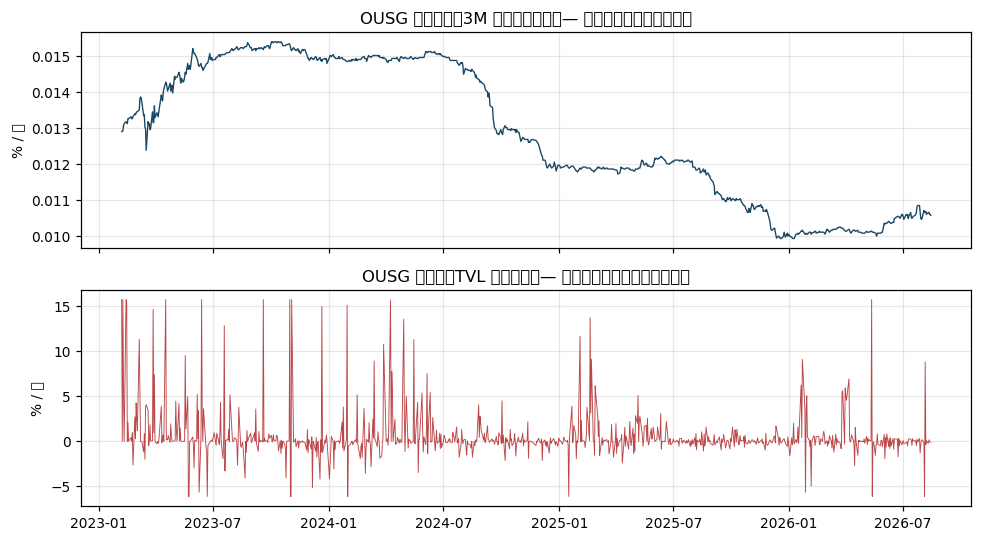

基本面軌標準差：0.0019
市值軌標準差  ：2.7720  （約 1459 倍）


In [6]:
# ---------------------------------------------------------------------------
# 視覺化：基本面軌 vs 市值軌的量級差異
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

sub = panel.loc[panel["R_OUSG_mkt"].notna()]
axes[0].plot(sub.index, sub["R_OUSG_nav"], lw=0.9, color="#1b4965")
axes[0].set_title("OUSG 基本面軌（3M 國庫券日累積）— 幾乎是平滑的確定性序列")
axes[0].set_ylabel("% / 日")

axes[1].plot(sub.index, sub["R_OUSG_mkt"], lw=0.6, color="#bc4749")
axes[1].set_title("OUSG 市值軌（TVL 對數變動）— 大幅離散跳動，反映機構申贖")
axes[1].set_ylabel("% / 日")

fig.tight_layout()
plt.show()

print(f"基本面軌標準差：{sub['R_OUSG_nav'].std():.4f}")
print(f"市值軌標準差  ：{sub['R_OUSG_mkt'].std():.4f}  （約 {sub['R_OUSG_mkt'].std()/sub['R_OUSG_nav'].std():.0f} 倍）")

---

## 單元 3｜Winsorization 與極端值處理

> **統計技術**：尾部截尾（winsorization）；資料清理規則的事前設定
>
> **對應程式**：`02_build_returns.py`
>
> **原始文獻**：
> - Mafrur (2025), Tokenize everything, but can you sell it? (arXiv:2508.11651)

### 原理

Winsorization 把超過某個分位數的觀測值**壓縮到該分位數**，而非刪除：

$$
\tilde{r}_t = \min\Big( \max(r_t,\ q_{\alpha}),\ q_{1-\alpha} \Big)
$$

亦即逐段來看：

| 條件 | 結果 |
|---|---|
| $r_t < q_{\alpha}$ | $q_{\alpha}$（壓到下分位數） |
| $q_{\alpha} \le r_t \le q_{1-\alpha}$ | $r_t$（保持不變） |
| $r_t > q_{1-\alpha}$ | $q_{1-\alpha}$（壓到上分位數） |

與**截斷（truncation，直接刪除）**的關鍵差別：winsorization **保留樣本數與時間序列的連續性**。
對 GARCH 這類需要連續遞迴的模型，中間挖洞是災難性的 —— 條件變異數的遞迴會斷掉。

### 為什麼需要它

GARCH 族的概似函數對極端值極度敏感。單一個 15 個標準差的觀測值可以：
- 把 $\omega$（常數項）推高到吸收掉整個尾部
- 讓 $\alpha + \beta$ 逼近 1（假的高持續性）
- 或反過來把參數推到邊界解

### 本研究的兩級門檻設計

| 序列類型 | 門檻 | 理由 |
|---|---|---|
| 傳統資產報酬 | 0.5% / 99.5% | 標準實務 |
| 代幣市值軌、LIQ | 1% / 99% | **更緊** |

代幣市值軌用更緊的門檻，理由不是「讓結果好看」，而是有明確的經濟學依據：
DefiLlama 的 TVL 序列存在大幅離散跳動，對應**機構的整筆申購／贖回**。
單一機構一次投入數億美元，會在 TVL 序列上製造一個純粹反映單筆交易時點的巨大「報酬」，
這不是市場定價資訊。Mafrur (2025) 記錄了代幣化 RWA 次級市場即使在總量龐大時仍然交投稀薄，
正是這種跳動的來源。

> **研究倫理的界線在哪裡**
>
> Winsorization 很容易變成 p-hacking 的工具：試幾組門檻，選出最顯著的那組。
> 本研究把這條界線畫在三個地方：
> 1. 門檻**事前設定**，寫在資料建構腳本裡，不在看到結果後調整
> 2. 兩級門檻的差異有**獨立於結果的經濟學理由**（機構申贖 vs 市場定價）
> 3. 在論文中**明確揭露**，並說明這是資料品質控制而非製造顯著性的手段
>
> 一個實用的自我檢查：如果你調整了門檻並發現結論改變了，正確的做法是**報告兩組結果**，
> 而不是選一組。

### 額外的清理規則：OUSG 孵化期截斷

OUSG 於 2023-01-27 上線，但最初約一週半的 TVL 低於 1,000 萬美元。
在那個窗口內，TVL 從 135 美元成長到超過 1,000 萬美元 —— 對數變動會產生數百個百分點的「報酬」。

這**不是報酬，是小分母假象**。程式因此丟棄 TVL 首次超過 1,000 萬美元之前的觀測：

```python
INCUBATION_CUTOFF = ousg_tvl_c[ousg_tvl_c > 10_000_000].index.min()
for c in ["R_OUSG_mkt", "LIQ_OUSG"]:
    returns.loc[returns.index < INCUBATION_CUTOFF, c] = np.nan
```

門檻（1,000 萬美元）與規則（首次跨越）都是事前設定的、可驗證的，並在論文中揭露為資料清理規則。

In [7]:
# ---------------------------------------------------------------------------
# Winsorization 的效果：從零實作，對照兩級門檻
# ---------------------------------------------------------------------------
def winsorize(s, lo_q, hi_q):
    lo, hi = s.quantile(lo_q), s.quantile(hi_q)
    return s.clip(lo, hi)

# 用尚未 winsorize 的原始 TVL 重建一次，以展示差異
ousg_tvl = pd.read_csv(RAW / "defillama_OUSG_tvl.csv", parse_dates=["date"]).set_index("date")["OUSG_TVL"]
ousg_tvl = ousg_tvl.groupby(ousg_tvl.index.normalize()).last()
raw_ret = 100 * np.log(ousg_tvl / ousg_tvl.shift(1))
raw_ret = raw_ret[raw_ret.index >= "2023-02-06"].dropna()   # 已過孵化期

comp = pd.DataFrame({
    "原始": raw_ret.describe(),
    "0.5%/99.5%": winsorize(raw_ret, 0.005, 0.995).describe(),
    "1%/99%（本研究採用）": winsorize(raw_ret, 0.01, 0.99).describe(),
}).loc[["std", "min", "max"]]
comp.loc["峰態"] = [raw_ret.kurtosis(),
                    winsorize(raw_ret, 0.005, 0.995).kurtosis(),
                    winsorize(raw_ret, 0.01, 0.99).kurtosis()]
display(comp)

print("觀察：更緊的門檻把峰態從極端值壓回可用範圍，但樣本數完全不變 ——")
print("      這正是 winsorization 相對於截斷的優勢，GARCH 的遞迴不會被打斷。")

,原始,0.5%/99.5%,1%/99%（本研究採用）
std,3.0099,2.3911,2.1547
min,-21.1562,-8.6722,-4.9873
max,43.6976,16.8291,13.8944
峰態,62.9300,22.6800,20.2154


觀察：更緊的門檻把峰態從極端值壓回可用範圍，但樣本數完全不變 ——
      這正是 winsorization 相對於截斷的優勢，GARCH 的遞迴不會被打斷。


---
---

# 第 2 篇　時間序列前置檢定

前置檢定的目的不是「跑一遍讓表格好看」，而是**確認後續模型的前提成立**。
三個單元對應三個前提：

| 檢定 | 確認的前提 | 若不成立會發生什麼 |
|---|---|---|
| Jarque–Bera | 條件分配該不該用常態 | 用常態 GARCH 會低估尾部風險 |
| ADF / PP / KPSS | 序列定態 | VAR 與 GARCH 的漸近理論全部失效 |
| Ljung–Box / ARCH-LM | 存在條件異質變異 | 若沒有 ARCH 效果，GARCH 就是多餘的 |

第三項尤其常被忽略：**先證明有 ARCH 效果，才有理由配適 GARCH**。

---

## 單元 4｜描述統計與 Jarque–Bera 常態性檢定

> **統計技術**：動差估計；Jarque–Bera 檢定
>
> **對應程式**：`03_pretests.py`
>
> **原始文獻**：
> - Jarque, C. M., & Bera, A. K. (1980). Efficient tests for normality, homoscedasticity and serial independence of regression residuals. Economics Letters, 6(3), 255–259.

### 原理與公式

給定樣本 $\{r_t\}_{t=1}^{T}$，樣本偏態與峰態為

$$
S = \frac{\frac{1}{T}\sum_{t=1}^{T}(r_t - \bar{r})^3}{\hat{\sigma}^3},
\qquad
K = \frac{\frac{1}{T}\sum_{t=1}^{T}(r_t - \bar{r})^4}{\hat{\sigma}^4}
$$

（本研究用 $K$ 的**非中心化**定義，常態分配下 $K = 3$。）

Jarque–Bera 統計量同時檢定「偏態為 0」與「峰態為 3」：

$$
\mathrm{JB} = \frac{T}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)
\xrightarrow{d} 
\chi^2(2) \quad \text{在 } H_0: \text{常態}
$$

### 為什麼這個檢定幾乎一定會拒絕

日頻金融報酬**必然**呈現厚尾。JB 拒絕常態不是發現，而是預期。
真正有資訊的是**拒絕的程度與方向**：

- 峰態 $K \approx 4$–5：溫和厚尾，$t$ 分配自由度約 5–8
- 峰態 $K > 15$：極端厚尾，通常意味著少數幾個跳躍主導了整個樣本
- 偏態 $S$ 顯著為正：右尾長 —— 對代幣的 TVL 序列，這對應機構整筆申購

### 對建模的直接影響

本研究的 GARCH 邊際模型統一使用**偏態 $t$ 分配**（`dist="skewt"`），
而非常態。原因就在描述統計表：代幣市值軌的峰態高達 16–17，偏態超過 2.4。
用常態分配的 QMLE 雖然參數估計仍有一致性，但：
- 標準誤會被嚴重低估
- VaR / CVaR 這類尾部量會系統性偏低
- 概似比檢定（單元 13 要用）的分配會扭曲

In [8]:
# ---------------------------------------------------------------------------
# 描述統計：讀取管線輸出並解讀
# ---------------------------------------------------------------------------
desc = pd.read_csv(PROC / "descriptive_stats.csv", index_col=0)
display(desc[["n", "mean", "sd", "skew", "kurtosis", "JB_stat", "JB_pvalue"]].round(4))

print("解讀重點：")
print(f"  1. 全部 {len(desc)} 個序列的 JB p 值皆 < 0.05 → 常態全數遭拒（預期之內）")
print(f"  2. 代幣市值軌峰態最高：R_OUSG_mkt = {desc.loc['R_OUSG_mkt','kurtosis']:.1f}, "
      f"R_BUIDL_mkt = {desc.loc['R_BUIDL_mkt','kurtosis']:.1f}")
print(f"  3. 對應的偏態亦為正且大：{desc.loc['R_OUSG_mkt','skew']:.2f}, {desc.loc['R_BUIDL_mkt','skew']:.2f}")
print("     → 右尾長，符合『機構整筆申購造成 TVL 向上跳躍』的解釋")
print(f"  4. 對照 R_FANG 峰態僅 {desc.loc['R_FANG','kurtosis']:.2f}，偏態 {desc.loc['R_FANG','skew']:.2f}（左偏，股市典型）")

,n,mean,sd,skew,kurtosis,JB_stat,JB_pvalue
series,,,,,,,
R_FANG,906,0.1534,1.5789,-0.2070,3.6297,21.4398,0.0000
R_SOXX,906,0.1674,2.2915,-0.3433,4.4346,95.4828,0.0000
R_SMH,906,0.1907,2.1534,-0.3474,4.3768,89.7811,0.0000
R_SHV,906,0.0178,0.0159,0.8525,3.9392,143.0414,0.0000
R_IEF,906,0.0095,0.4383,0.1328,3.4597,10.6425,0.0049
R_BUIDL_mkt,528,0.3584,2.7660,2.4773,16.1666,"4,353.9242",0.0000
R_BUIDL_nav,907,0.0129,0.0019,-0.0917,1.5184,84.2295,0.0000
R_OUSG_mkt,880,0.5882,2.7720,3.2188,17.4429,"9,168.1327",0.0000
R_OUSG_nav,907,0.0129,0.0019,-0.0917,1.5184,84.2295,0.0000


解讀重點：
  1. 全部 16 個序列的 JB p 值皆 < 0.05 → 常態全數遭拒（預期之內）
  2. 代幣市值軌峰態最高：R_OUSG_mkt = 17.4, R_BUIDL_mkt = 16.2
  3. 對應的偏態亦為正且大：3.22, 2.48
     → 右尾長，符合『機構整筆申購造成 TVL 向上跳躍』的解釋
  4. 對照 R_FANG 峰態僅 3.63，偏態 -0.21（左偏，股市典型）


In [9]:
# ---------------------------------------------------------------------------
# 從零實作 Jarque-Bera，驗證與 scipy 一致
# ---------------------------------------------------------------------------
from scipy import stats

def jarque_bera_manual(x):
    x = np.asarray(x)
    T = len(x)
    m = x.mean()
    s2 = ((x - m) ** 2).mean()          # 有偏（除以 T），與定義一致
    S = ((x - m) ** 3).mean() / s2 ** 1.5
    K = ((x - m) ** 4).mean() / s2 ** 2
    JB = T / 6 * (S ** 2 + (K - 3) ** 2 / 4)
    p = 1 - stats.chi2.cdf(JB, df=2)
    return JB, p, S, K

r = panel["R_FANG"].dropna()
jb_manual = jarque_bera_manual(r)
jb_scipy = stats.jarque_bera(r)

print(f"手動實作 : JB = {jb_manual[0]:9.4f}, p = {jb_manual[1]:.3e}, S = {jb_manual[2]:+.4f}, K = {jb_manual[3]:.4f}")
print(f"scipy    : JB = {jb_scipy[0]:9.4f}, p = {jb_scipy[1]:.3e}")
print(f"差異     : {abs(jb_manual[0] - jb_scipy[0]):.2e}")

手動實作 : JB =   21.4398, p = 2.210e-05, S = -0.2070, K = 3.6297
scipy    : JB =   21.4398, p = 2.210e-05
差異     : 7.11e-15


---

## 單元 5｜單根與定態：ADF、Phillips–Perron、KPSS

> **統計技術**：單根檢定（ADF, PP）；定態檢定（KPSS）；虛無假設方向相反的互補設計
>
> **對應程式**：`03_pretests.py`
>
> **原始文獻**：
> - Dickey, D. A., & Fuller, W. A. (1979)
> - Phillips, P. C. B., & Perron, P. (1988)
> - Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992)

### 原理：為什麼定態如此關鍵

VAR、GARCH、DCC 的漸近理論全部建立在**弱定態**（covariance stationarity）之上：

$$
\mathbb{E}[r_t] = \mu, \quad
\mathrm{Var}(r_t) = \sigma^2 < \infty, \quad
\mathrm{Cov}(r_t, r_{t-k}) = \gamma_k  \text{（僅依賴 } k\text{）}
$$

若序列有單根，OLS 的 $t$ 統計量不再收斂到常態，而是收斂到非標準的泛函布朗運動分配 ——
所有的 $p$ 值都會失去意義（Granger–Newbold 的偽迴歸問題）。

### 三個檢定的公式與虛無假設

**ADF（Augmented Dickey–Fuller）**

檢定迴歸：

$$
\Delta r_t = \alpha + \gamma r_{t-1} + \sum_{i=1}^{p} \delta_i \Delta r_{t-i} + \varepsilon_t
$$

$$
H_0: \gamma = 0  (\text{有單根}) \quad\text{vs}\quad H_1: \gamma < 0  (\text{定態})
$$

落後差分項 $\sum \delta_i \Delta r_{t-i}$ 的作用是**吸收殘差中的序列相關**，讓 $\varepsilon_t$ 接近白噪音。

**Phillips–Perron**

與 ADF 相同的虛無假設，但處理序列相關的方式不同：不加落後項，
而是對統計量做**非參數的 Newey–West 型修正**。

$$
Z_\tau = \left(\frac{\hat{\gamma}_0}{\hat{\lambda}^2}\right)^{1/2} t_{\hat{\gamma}}
- \frac{(\hat{\lambda}^2 - \hat{\gamma}_0) T  \mathrm{se}(\hat{\gamma})}{2 \hat{\lambda}^2 \hat{\sigma}}
$$

其中 $\hat{\lambda}^2$ 是長期變異數的一致估計。PP 對**異質變異**比 ADF 穩健。

**KPSS —— 虛無假設方向相反**

$$
r_t = \xi t + \rho_t + \varepsilon_t, \qquad \rho_t = \rho_{t-1} + u_t
$$

$$
H_0: \sigma_u^2 = 0  (\text{定態}) \quad\text{vs}\quad H_1: \sigma_u^2 > 0  (\text{有單根})
$$

統計量為部分和的平方累積：

$$
\mathrm{KPSS} = \frac{1}{T^2 \hat{\lambda}^2} \sum_{t=1}^{T} S_t^2,
\qquad S_t = \sum_{i=1}^{t} \hat{\varepsilon}_i
$$

### 為什麼要同時做三個：虛無假設方向的互補性

這是本單元的核心教學點。ADF / PP 與 KPSS 的虛無假設**方向相反**：

| | ADF / PP | KPSS |
|---|---|---|
| $H_0$ | 有單根（非定態） | 定態 |
| 拒絕代表 | 定態 | 非定態 |

「無法拒絕 $H_0$」**不等於**「$H_0$ 成立」—— 它也可能只是檢定力不足。
把兩個方向相反的檢定並用，就能區分四種情況：

| ADF 拒絕? | KPSS 拒絕? | 結論 |
|---|---|---|
| 是 | 否 | **定態**（兩者一致，最理想） |
| 否 | 是 | **非定態**（兩者一致） |
| 是 | 是 | 矛盾 → 可能是結構斷點或分數整合 |
| 否 | 否 | 資訊不足 → 樣本太短或檢定力太低 |

### 本研究的實際結果與其意義

代幣的 **NAV 軌明確地無法拒絕單根**（ADF $p \approx 0.95$，KPSS $p \approx 0.0001$，
即兩個檢定一致指向非定態）。這**不是資料錯誤**，而是建構方式的必然後果：

NAV 軌是 3 個月期國庫券殖利率除以 365，而**殖利率水準本身就是高度持續的近單根序列**。
把一個近單根序列做線性縮放，當然還是近單根。

這在論文中被明確揭露為限制：NAV 軌比市場決定的序列平滑得多，
因此**所有主要結果都建立在市值軌上**，NAV 軌僅作為流動性溢價的參照。

In [10]:
# ---------------------------------------------------------------------------
# 單根檢定結果的四象限解讀
# ---------------------------------------------------------------------------
ur = pd.read_csv(PROC / "unitroot_tests.csv", index_col=0)

def verdict(row):
    adf_rej = row["ADF_pvalue"] < 0.05
    kpss_rej = row["KPSS_pvalue"] < 0.05
    if adf_rej and not kpss_rej:
        return "定態（一致）"
    if not adf_rej and kpss_rej:
        return "非定態（一致）"
    if adf_rej and kpss_rej:
        return "矛盾（斷點?）"
    return "資訊不足"

ur["判定"] = ur.apply(verdict, axis=1)
display(ur[["ADF_stat", "ADF_pvalue", "PP_pvalue", "KPSS_stat", "KPSS_pvalue", "判定"]].round(4))

print("\n分類統計：")
print(ur["判定"].value_counts().to_string())
print("\n注意 R_BUIDL_nav 與 R_OUSG_nav：兩列數字完全相同（同一代理序列），")
print("且皆為『非定態（一致）』—— 殖利率水準的近單根性質被線性縮放後保留下來。")

,ADF_stat,ADF_pvalue,PP_pvalue,KPSS_stat,KPSS_pvalue,判定
series,,,,,,
R_FANG,-29.7836,0.0000,0.0000,0.2476,0.1918,定態（一致）
R_SOXX,-31.9518,0.0000,0.0000,0.1341,0.4421,定態（一致）
R_SMH,-31.6689,0.0000,0.0000,0.0812,0.6854,定態（一致）
R_SHV,-3.2968,0.0150,0.0000,0.7714,0.0085,矛盾（斷點?）
R_IEF,-31.2889,0.0000,0.0000,0.0407,0.9297,定態（一致）
R_BUIDL_mkt,-5.6771,0.0000,0.0000,0.1694,0.3362,定態（一致）
R_BUIDL_nav,-0.0562,0.9536,0.9464,4.0057,0.0001,非定態（一致）
R_OUSG_mkt,-15.2868,0.0000,0.0000,0.8488,0.0056,矛盾（斷點?）
R_OUSG_nav,-0.0562,0.9536,0.9464,4.0057,0.0001,非定態（一致）



分類統計：
判定
定態（一致）     10
矛盾（斷點?）     4
非定態（一致）     2

注意 R_BUIDL_nav 與 R_OUSG_nav：兩列數字完全相同（同一代理序列），
且皆為『非定態（一致）』—— 殖利率水準的近單根性質被線性縮放後保留下來。


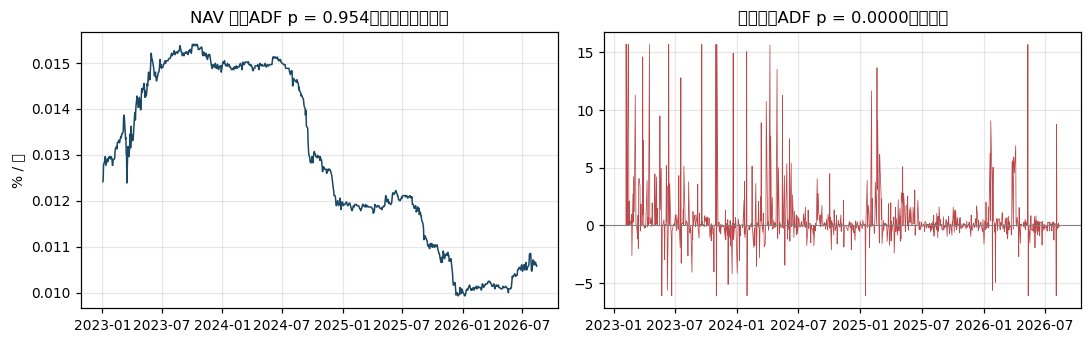

左圖呈現緩慢的水準漂移（跟隨聯準會政策路徑），右圖繞著零均值震盪。
肉眼即可分辨，檢定只是把這個判斷形式化。


In [11]:
# ---------------------------------------------------------------------------
# 視覺對照：定態的市值軌 vs 近單根的 NAV 軌
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

s_nav = panel["R_OUSG_nav"].dropna()
s_mkt = panel["R_OUSG_mkt"].dropna()

axes[0].plot(s_nav.index, s_nav.values, lw=1, color="#1b4965")
axes[0].set_title(f"NAV 軌：ADF p = {ur.loc['R_OUSG_nav','ADF_pvalue']:.3f}（無法拒絕單根）")
axes[0].set_ylabel("% / 日")

axes[1].plot(s_mkt.index, s_mkt.values, lw=0.5, color="#bc4749")
axes[1].axhline(0, color="grey", lw=0.7)
axes[1].set_title(f"市值軌：ADF p = {ur.loc['R_OUSG_mkt','ADF_pvalue']:.4f}（定態）")

fig.tight_layout()
plt.show()

print("左圖呈現緩慢的水準漂移（跟隨聯準會政策路徑），右圖繞著零均值震盪。")
print("肉眼即可分辨，檢定只是把這個判斷形式化。")

---

## 單元 6｜序列相關與條件異質變異：Ljung–Box、ARCH-LM

> **統計技術**：Ljung–Box Q 檢定；Engle ARCH-LM 檢定
>
> **對應程式**：`03_pretests.py`
>
> **原始文獻**：
> - Ljung, G. M., & Box, G. E. P. (1978)
> - Engle, R. F. (1982)

### Ljung–Box Q 檢定

檢定「前 $m$ 階自相關是否全為零」：

$$
Q(m) = T(T+2) \sum_{k=1}^{m} \frac{\hat{\rho}_k^2}{T-k}
\xrightarrow{d}  \chi^2(m)
\qquad H_0: \rho_1 = \cdots = \rho_m = 0
$$

其中 $\hat{\rho}_k$ 是第 $k$ 階樣本自相關。$T(T+2)/(T-k)$ 是相對於原始 Box–Pierce 統計量的
小樣本修正。

**關鍵：對 $r_t$ 與對 $r_t^2$ 各做一次**

| 檢定對象 | 拒絕代表 | 建模含意 |
|---|---|---|
| $Q(m)$ on $r_t$ | 報酬本身可預測 | 需要 AR 或 ARMA 的均值方程 |
| $Q(m)$ on $r_t^2$ | **波動叢聚** | 需要 GARCH 族的變異數方程 |

本研究的均值方程統一用 **AR(1)**（`mean="AR", lags=1`），正是為了吸收第一項。

### Engle ARCH-LM 檢定

更直接地檢定 ARCH 效果。對平方殘差做輔助迴歸：

$$
\hat{\varepsilon}_t^2 = \alpha_0 + \alpha_1 \hat{\varepsilon}_{t-1}^2 + \cdots
+ \alpha_q \hat{\varepsilon}_{t-q}^2 + u_t
$$

$$
\mathrm{LM} = T \cdot R^2 \xrightarrow{d}  \chi^2(q)
\qquad H_0: \alpha_1 = \cdots = \alpha_q = 0  (\text{無 ARCH 效果})
$$

### 為什麼這一步不能跳過

這是**配適 GARCH 的正當性依據**。如果 ARCH-LM 無法拒絕，那條件變異數就是常數，
GARCH 模型會退化成同方差模型，估出來的 $\alpha, \beta$ 只是在配適雜訊。

本研究的結果顯示一個值得注意的差異：
- 傳統資產（FANG、SOXX、GLD）與代幣市值軌：ARCH-LM **強烈拒絕**，GARCH 有正當性
- 但 **OUSG 市值軌的 ARCH-LM $p \approx 0.26$，無法拒絕**

後者是誠實的訊號：OUSG 的 TVL 變動比較接近「隨機的大跳躍」而非「波動叢聚」。
這與單元 10 會看到的現象一致 —— 代幣序列的 GARCH 配適常常落在參數邊界上。

In [12]:
# ---------------------------------------------------------------------------
# 診斷檢定結果：報酬 vs 平方報酬
# ---------------------------------------------------------------------------
diag = pd.read_csv(PROC / "diagnostics.csv", index_col=0)
display(diag.round(4))

print("解讀：")
print("  LB10        = Ljung-Box on r_t      → 報酬本身的可預測性（AR(1) 均值方程要處理的）")
print("  LB10_sq     = Ljung-Box on r_t^2    → 波動叢聚（GARCH 要處理的）")
print("  ARCH_LM     = Engle LM              → ARCH 效果的直接檢定")
print()
no_arch = diag[diag["ARCH_LM_pvalue"] > 0.05]
print(f"ARCH-LM 無法拒絕（p > 0.05）的序列共 {len(no_arch)} 個：")
for s, row in no_arch.iterrows():
    print(f"    {s:14} ARCH-LM p = {row['ARCH_LM_pvalue']:.4f}")
print()
print("→ 這些序列配適 GARCH 的正當性較弱，其參數估計應謹慎解讀（見單元 10）。")

,LB10_stat,LB10_pvalue,LB10_sq_stat,LB10_sq_pvalue,ARCH_LM_stat,ARCH_LM_pvalue
series,,,,,,
R_FANG,3.1281,0.9782,103.4764,0.0000,56.3594,0.0000
R_SOXX,12.6201,0.2457,228.8724,0.0000,105.1064,0.0000
R_SMH,8.7579,0.5552,133.1285,0.0000,71.8639,0.0000
R_SHV,436.9348,0.0000,365.5036,0.0000,255.7490,0.0000
R_IEF,6.0746,0.8090,169.2956,0.0000,76.2724,0.0000
R_BUIDL_mkt,79.5826,0.0000,131.1908,0.0000,85.5707,0.0000
R_BUIDL_nav,"8,986.0570",0.0000,"8,984.5463",0.0000,895.2991,0.0000
R_OUSG_mkt,27.5570,0.0021,38.5717,0.0000,12.4313,0.2572
R_OUSG_nav,"8,986.0570",0.0000,"8,984.5463",0.0000,895.2991,0.0000


解讀：
  LB10        = Ljung-Box on r_t      → 報酬本身的可預測性（AR(1) 均值方程要處理的）
  LB10_sq     = Ljung-Box on r_t^2    → 波動叢聚（GARCH 要處理的）
  ARCH_LM     = Engle LM              → ARCH 效果的直接檢定

ARCH-LM 無法拒絕（p > 0.05）的序列共 3 個：
    R_OUSG_mkt     ARCH-LM p = 0.2572
    R_UNI          ARCH-LM p = 0.3571
    R_AAVE         ARCH-LM p = 0.2754

→ 這些序列配適 GARCH 的正當性較弱，其參數估計應謹慎解讀（見單元 10）。


Font 'default' does not have a glyph for '\u5831' [U+5831], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u916c' [U+916c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff1a' [U+ff1a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5747' [U+5747], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u503c' [U+503c], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u7d50' [U+7d50], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u69cb' [U+69cb], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6b63' [U+6b63], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7576' [U+7576], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6027' [U+6027], substituting with a dummy symbol.


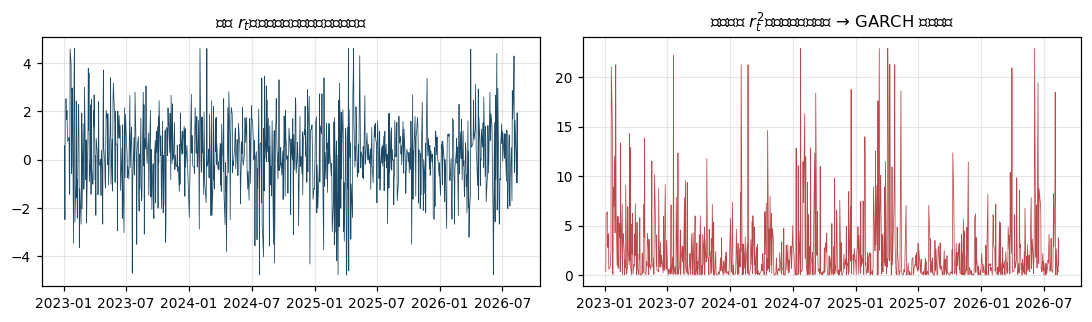

In [13]:
# ---------------------------------------------------------------------------
# 從零實作 Ljung-Box，並視覺化波動叢聚
# ---------------------------------------------------------------------------
def ljung_box(x, m=10):
    x = np.asarray(x); T = len(x)
    xc = x - x.mean()
    denom = (xc ** 2).sum()
    Q = 0.0
    for k in range(1, m + 1):
        rho_k = (xc[k:] * xc[:-k]).sum() / denom
        Q += rho_k ** 2 / (T - k)
    Q *= T * (T + 2)
    return Q, 1 - stats.chi2.cdf(Q, df=m)

r = panel["R_FANG"].dropna()
q_lvl, p_lvl = ljung_box(r, 10)
q_sq, p_sq = ljung_box(r ** 2, 10)

print(f"R_FANG   Q(10) on r_t   = {q_lvl:8.3f}, p = {p_lvl:.4f}  → "
      f"{'報酬可預測' if p_lvl < 0.05 else '報酬近似不可預測'}")
print(f"R_FANG   Q(10) on r_t^2 = {q_sq:8.3f}, p = {p_sq:.4f}  → "
      f"{'存在波動叢聚' if p_sq < 0.05 else '無明顯波動叢聚'}")
print()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(r.index, r.values, lw=0.5, color="#1b4965")
axes[0].set_title("報酬 $r_t$：均值附近震盪，方向難以預測")
axes[1].plot(r.index, (r ** 2).values, lw=0.5, color="#bc4749")
axes[1].set_title("平方報酬 $r_t^2$：明顯的叢聚結構 → GARCH 的正當性")
fig.tight_layout()
plt.show()

---
---

# 第 3 篇　邊際波動模型

DCC 是一個**兩階段**估計程序。階段一為每個序列各自配適一個單變量波動模型，
取出標準化殘差；階段二才在標準化殘差上估計相關動態。

這一篇處理階段一。三個候選模型（GARCH、GJR-GARCH、EGARCH）不是隨意並列，
而是三種對「波動如何回應衝擊」的不同假設。單元 10 說明如何在它們之間做出**有依據的**選擇，
以及當最佳化落在參數邊界時該怎麼辦 —— 後者在本研究的代幣序列上頻繁發生，
是必須誠實報告的實證特徵。

---

## 單元 7｜GARCH(1,1)：條件變異數的遞迴結構

> **統計技術**：廣義自迴歸條件異質變異；QMLE
>
> **對應程式**：`04_garch_dcc.py（階段一）`
>
> **原始文獻**：
> - Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. Journal of Econometrics, 31(3), 307–327.
> - Engle, R. F. (1982). Autoregressive conditional heteroscedasticity. Econometrica, 50(4), 987–1008.

### 原理

單元 6 已證明報酬存在波動叢聚：大波動之後跟著大波動。GARCH 用一條遞迴式把這件事形式化。

模型分成**均值方程**與**變異數方程**兩部分。本研究的均值方程為 AR(1)：

$$
r_t = \mu + \phi r_{t-1} + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \text{skew-}t(\nu, \lambda)
$$

變異數方程為 GARCH(1,1)：

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

### 每個參數的意義

| 參數 | 名稱 | 解讀 |
|---|---|---|
| $\omega > 0$ | 常數項 | 決定長期變異數的水準 |
| $\alpha \ge 0$ | ARCH 項／**新聞衝擊** | 昨日「意外」的平方對今日波動的影響。大 $\alpha$ = 波動對新資訊反應劇烈 |
| $\beta \ge 0$ | GARCH 項／**持續性** | 昨日波動水準的延續。大 $\beta$ = 波動有長記憶 |

### 定態條件與長期變異數

弱定態要求

$$
\alpha + \beta < 1
$$

此時無條件（長期）變異數存在且為

$$
\bar{\sigma}^2 = \mathbb{E}[\sigma_t^2] = \frac{\omega}{1 - \alpha - \beta}
$$

$\alpha + \beta$ 稱為**持續性（persistence）**。它的直觀意義是「衝擊的半衰期」：

$$
\text{半衰期} = \frac{\ln 0.5}{\ln(\alpha + \beta)}  \text{（交易日）}
$$

- $\alpha + \beta = 0.95$ → 半衰期約 13.5 天
- $\alpha + \beta = 0.99$ → 半衰期約 69 天
- $\alpha + \beta \to 1$ → IGARCH，衝擊永不衰減，無條件變異數不存在

### 演算法：遞迴的初始化

$\sigma_1^2$ 沒有前一期可用，必須初始化。常見做法是用樣本無條件變異數：

$$
\sigma_1^2 = \frac{1}{T}\sum_{t=1}^{T} \varepsilon_t^2
$$

初始值的影響隨 $\beta^t$ 幾何衰減，在 $T$ 夠大時可忽略 —— 但在本研究 sUSDS 這種
只有 371 個觀測的短樣本上，這個「可忽略」的假設本身就值得警惕。

### 估計：準最大概似（QMLE）

在條件常態假設下，對數概似為

$$
\ell(\theta) = -\frac{1}{2}\sum_{t=1}^{T}\left[\ln(2\pi) + \ln \sigma_t^2(\theta) + \frac{\varepsilon_t^2}{\sigma_t^2(\theta)}\right]
$$

即使真實分配不是常態，這個估計量仍有一致性（此即「準」的來源），
但標準誤需要用夾心估計量修正。本研究直接改用偏態 $t$ 概似（單元 10），避免這個問題。

In [14]:
# ---------------------------------------------------------------------------
# 從零實作 GARCH(1,1) 的遞迴與概似，並與 arch 套件對照
# ---------------------------------------------------------------------------
from scipy.optimize import minimize

def garch11_recursion(eps, omega, alpha, beta):
    """給定參數，回傳條件變異數路徑 sigma^2_t。"""
    T = len(eps)
    sigma2 = np.empty(T)
    sigma2[0] = eps.var()                      # 以樣本無條件變異數初始化
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    return sigma2

def garch11_neg_loglik(params, eps):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.9999:
        return 1e10                            # 違反正性與定態條件
    s2 = garch11_recursion(eps, omega, alpha, beta)
    if np.any(s2 <= 0):
        return 1e10
    return 0.5 * np.sum(np.log(2*np.pi) + np.log(s2) + eps**2 / s2)

# 以 FANG 為例（先去除 AR(1) 均值以取得 eps）
r = panel["R_FANG"].dropna().values
phi = np.corrcoef(r[1:], r[:-1])[0, 1]
eps = r[1:] - r[1:].mean() - phi * (r[:-1] - r[:-1].mean())

res = minimize(garch11_neg_loglik, x0=[0.05, 0.08, 0.88], args=(eps,),
               method="L-BFGS-B", bounds=[(1e-8, None), (0, 1), (0, 1)])
w, a, b = res.x
print(f"手動 GARCH(1,1)：omega = {w:.5f}, alpha = {a:.4f}, beta = {b:.4f}")
print(f"  持續性 alpha+beta = {a+b:.4f}")
print(f"  長期變異數       = {w/(1-a-b):.4f}  →  長期日波動 = {np.sqrt(w/(1-a-b)):.4f}%")
print(f"  衝擊半衰期       = {np.log(0.5)/np.log(a+b):.1f} 個交易日")

手動 GARCH(1,1)：omega = 0.13399, alpha = 0.0813, beta = 0.8646
  持續性 alpha+beta = 0.9458
  長期變異數       = 2.4743  →  長期日波動 = 1.5730%
  衝擊半衰期       = 12.4 個交易日


In [15]:
# ---------------------------------------------------------------------------
# 對照 arch 套件（研究實際使用的實作）
# ---------------------------------------------------------------------------
from arch import arch_model

am = arch_model(panel["R_FANG"].dropna(), mean="AR", lags=1,
                vol="GARCH", p=1, q=1, dist="normal", rescale=False)
fit = am.fit(disp="off")
p = fit.params
print(f"arch 套件      ：omega = {p['omega']:.5f}, alpha = {p['alpha[1]']:.4f}, beta = {p['beta[1]']:.4f}")
print(f"  持續性        = {p['alpha[1]'] + p['beta[1]']:.4f}")
print()
print("差異來源：手動版對 AR(1) 用簡易估計、且與變異數方程分開估計；")
print("arch 套件對均值與變異數參數做聯合最大概似估計。方向與量級一致即說明實作正確。")

arch 套件      ：omega = 0.12298, alpha = 0.0747, beta = 0.8746
  持續性        = 0.9493

差異來源：手動版對 AR(1) 用簡易估計、且與變異數方程分開估計；
arch 套件對均值與變異數參數做聯合最大概似估計。方向與量級一致即說明實作正確。


Font 'default' does not have a glyph for '\uff08' [U+ff08], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5be6' [U+5be6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u969b' [U+969b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff09' [U+ff09], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff08' [U+ff08], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u689d' [U+689d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4ef6' [U+4ef6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6ce2' [U+6ce2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u52d5' [U+52d5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff09' [U+ff09], substituting with a dummy symbol.


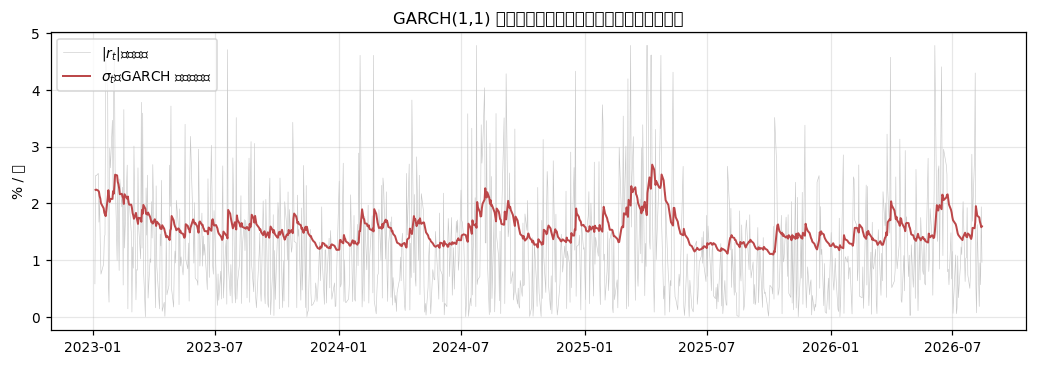

In [16]:
# ---------------------------------------------------------------------------
# 視覺化：條件波動路徑 vs 絕對報酬
# ---------------------------------------------------------------------------
r_series = panel["R_FANG"].dropna()
cond_vol = fit.conditional_volatility

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(r_series.index, r_series.abs(), lw=0.4, color="#c9c9c9", label="$|r_t|$（實際）")
ax.plot(cond_vol.index, cond_vol, lw=1.3, color="#bc4749", label=r"$\sigma_t$（GARCH 條件波動）")
ax.set_title("GARCH(1,1) 條件波動：把叢聚結構萃取成一條平滑路徑")
ax.set_ylabel("% / 日")
ax.legend()
fig.tight_layout()
plt.show()

---

## 單元 8｜GJR-GARCH：槓桿效果與門檻項

> **統計技術**：門檻 GARCH；非對稱波動反應
>
> **對應程式**：`04_garch_dcc.py（階段一）`
>
> **原始文獻**：
> - Glosten, L. R., Jagannathan, R., & Runkle, D. E. (1993). On the relation between the expected value and the volatility of the nominal excess return on stocks. Journal of Finance, 48(5), 1779–1801.

### 原理：GARCH(1,1) 漏掉了什麼

GARCH 的變異數方程只用到 $\varepsilon_{t-1}^2$ —— **平方項對稱**，
意味著 +3% 與 −3% 的衝擊對明日波動有完全相同的影響。

但股票市場有一個穩健的實證規律：**下跌比同幅度的上漲更能提高波動**。
這稱為**槓桿效果（leverage effect）**，傳統解釋是股價下跌提高了公司的負債權益比，
使股權風險上升。

### 公式

GJR-GARCH(1,1,1) 加入一個**指示函數門檻項**：

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2
+ \gamma \varepsilon_{t-1}^2 \mathbb{I}_{[\varepsilon_{t-1} < 0]}
+ \beta \sigma_{t-1}^2
$$

其中

其中指示函數 $\mathbb{I}_{[\varepsilon_{t-1} < 0]}$ 在 $\varepsilon_{t-1} < 0$ 時取值 1，否則取值 0。

### 解讀 $\gamma$

| 衝擊方向 | 對 $\sigma_t^2$ 的邊際效果 |
|---|---|
| 正向（$\varepsilon_{t-1} \ge 0$） | $\alpha$ |
| 負向（$\varepsilon_{t-1} < 0$） | $\alpha + \gamma$ |

- $\gamma > 0$：**槓桿效果**，負向衝擊放大波動（股票的典型型態）
- $\gamma = 0$：退化為標準 GARCH
- $\gamma < 0$：反向的非對稱 —— 正向衝擊反而提高波動

### 持續性的修正

因為門檻項平均只有一半的時間啟動（假設衝擊對稱分布），持續性變成

$$
\text{persistence} = \alpha + \frac{\gamma}{2} + \beta
$$

程式碼裡正是這樣寫的：

```python
if best_name == "GJR-GARCH":
    persistence = alpha + (gamma if not np.isnan(gamma) else 0) / 2 + beta
```

> **為什麼 $\gamma < 0$ 對本研究是有意義的發現**
>
> 代幣化國債的 TVL 序列若出現 $\gamma < 0$，代表**流入（正向衝擊）比流出更能提高波動**。
> 這與股票的槓桿效果方向相反，但符合「大額機構申購造成 TVL 跳躍」的機制 ——
> 波動由資金流驅動，而非由價格發現驅動。單元 10 會看到這個型態的實際估計結果。

Font 'default' does not have a glyph for '\u524d' [U+524d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u671f' [U+671f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u885d' [U+885d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u64ca' [U+64ca], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u65b0' [U+65b0], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u9a45' [U+9a45], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u52d5' [U+52d5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u578b' [U+578b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u614b' [U+614b], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff09' [U+ff09], substituting with a dummy symbol.


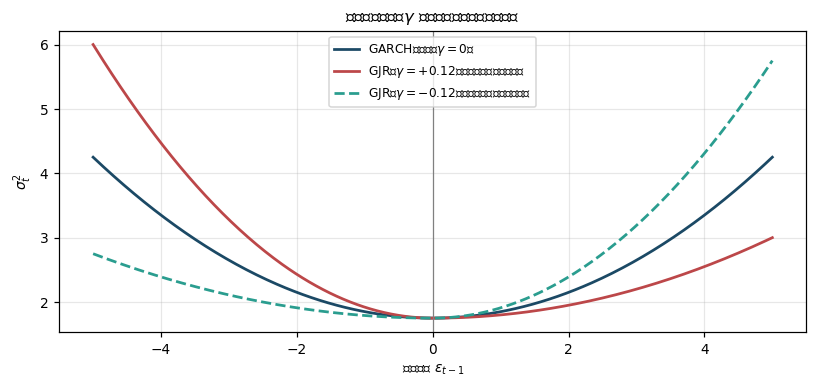

In [17]:
# ---------------------------------------------------------------------------
# 新聞衝擊曲線（News Impact Curve）：對稱 vs 非對稱的視覺化
# ---------------------------------------------------------------------------
def nic_garch(eps_range, omega, alpha, beta, sigma2_bar):
    return omega + alpha * eps_range**2 + beta * sigma2_bar

def nic_gjr(eps_range, omega, alpha, gamma, beta, sigma2_bar):
    ind = (eps_range < 0).astype(float)
    return omega + alpha * eps_range**2 + gamma * eps_range**2 * ind + beta * sigma2_bar

e = np.linspace(-5, 5, 400)
s2bar = 2.0
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(e, nic_garch(e, 0.05, 0.10, 0.85, s2bar), lw=1.8, color="#1b4965",
        label=r"GARCH：對稱（$\gamma=0$）")
ax.plot(e, nic_gjr(e, 0.05, 0.05, 0.12, 0.85, s2bar), lw=1.8, color="#bc4749",
        label=r"GJR：$\gamma=+0.12$（槓桿效果，股票型態）")
ax.plot(e, nic_gjr(e, 0.05, 0.16, -0.12, 0.85, s2bar), lw=1.8, color="#2a9d8f", ls="--",
        label=r"GJR：$\gamma=-0.12$（反向，資金流驅動型態）")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel(r"前期衝擊 $\varepsilon_{t-1}$")
ax.set_ylabel(r"$\sigma_t^2$")
ax.set_title("新聞衝擊曲線：$\gamma$ 的符號決定曲線往哪邊傾斜")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---

## 單元 9｜EGARCH：對數變異數與無約束參數空間

> **統計技術**：指數 GARCH；對數轉換避免正性約束
>
> **對應程式**：`04_garch_dcc.py（階段一）`
>
> **原始文獻**：
> - Nelson, D. B. (1991). Conditional heteroskedasticity in asset returns: A new approach. Econometrica, 59(2), 347–370.

### 原理：GARCH 與 GJR 的兩個實務痛點

1. **正性約束**：必須強制 $\omega > 0, \alpha \ge 0, \beta \ge 0$，否則 $\sigma_t^2$ 可能為負。
   這讓最佳化器在有界空間裡工作，容易卡在邊界。
2. **非對稱只能靠門檻**：GJR 用指示函數，是分段線性的粗糙處理。

EGARCH 用一個巧妙的轉換同時解決兩者：**對 $\ln \sigma_t^2$ 建模**。
因為指數函數恆正，$\sigma_t^2 = \exp(\cdot)$ 自動滿足正性，參數可以自由取任意實數。

### 公式

$$
\ln \sigma_t^2 = \omega
+ \alpha \left( |z_{t-1}| - \mathbb{E}|z_{t-1}| \right)
+ \gamma z_{t-1}
+ \beta \ln \sigma_{t-1}^2
$$

其中 $z_t = \varepsilon_t / \sigma_t$ 是**標準化**殘差。注意兩個關鍵設計：

**（一）用標準化殘差 $z$ 而非原始殘差 $\varepsilon$**

這讓衝擊的影響與當時的波動水準無關 —— 高波動時期的 3% 變動與低波動時期的 3% 變動，
在標準化後有不同的意義，這正是我們想要的。

**（二）$\alpha$ 與 $\gamma$ 分工明確**

| 項 | 捕捉什麼 |
|---|---|
| $\alpha(\lvert z_{t-1}\rvert - \mathbb{E}\lvert z_{t-1}\rvert)$ | **幅度效果**：衝擊有多大（不分方向） |
| $\gamma z_{t-1}$ | **符號效果**：衝擊往哪邊（線性，不是門檻） |

減去 $\mathbb{E}|z_{t-1}|$ 是為了讓幅度項的期望值為零，使 $\omega$ 保持「長期水準」的解讀。
在標準常態下 $\mathbb{E}|z| = \sqrt{2/\pi} \approx 0.7979$。

### $\gamma$ 的符號意義 —— 與 GJR 相反

這是最容易出錯的地方：

| 模型 | 槓桿效果對應的符號 |
|---|---|
| GJR-GARCH | $\gamma > 0$ |
| **EGARCH** | $\gamma < 0$ |

因為 EGARCH 的 $\gamma z_{t-1}$ 是**直接乘上帶符號的 $z$**：
若 $\gamma < 0$，則 $z_{t-1} < 0$（壞消息）會使 $\gamma z_{t-1} > 0$，推高對數變異數。

> 本研究的表 3 報告的 `gamma_asym` 欄位混合了兩種模型的 $\gamma$，
> 因此表格註解必須說明「在本表所用的 EGARCH 參數化下，**負值**對應傳統股票槓桿效果」，
> 否則讀者會把符號讀反。

### 持續性

因為模型作用在對數尺度上，持續性由 $\beta$ **單獨**決定：

$$
\text{persistence} = \beta
$$

程式碼：

```python
else:  # EGARCH: persistence of log-variance is beta alone
    persistence = beta
```

定態條件為 $|\beta| < 1$，比 GARCH 的 $\alpha + \beta < 1$ 寬鬆。

In [18]:
# ---------------------------------------------------------------------------
# 三個模型並排配適同一序列，比較 gamma 的符號與量級
# ---------------------------------------------------------------------------
series = panel["R_FANG"].dropna()
specs = [("GARCH", dict(vol="GARCH", p=1, o=0, q=1)),
         ("GJR-GARCH", dict(vol="GARCH", p=1, o=1, q=1)),
         ("EGARCH", dict(vol="EGARCH", p=1, o=1, q=1))]

rows = []
for nm, kw in specs:
    f = arch_model(series, mean="AR", lags=1, dist="skewt", rescale=False, **kw).fit(disp="off")
    pr = f.params
    al, be = pr.get("alpha[1]", np.nan), pr.get("beta[1]", np.nan)
    ga = pr.get("gamma[1]", np.nan)
    if nm == "GJR-GARCH":
        pers = al + (0 if np.isnan(ga) else ga) / 2 + be
    elif nm == "GARCH":
        pers = al + be
    else:
        pers = be
    rows.append({"模型": nm, "alpha": al, "gamma": ga, "beta": be,
                 "持續性": pers, "AIC": f.aic, "BIC": f.bic})

cmp_df = pd.DataFrame(rows).set_index("模型")
display(cmp_df.round(4))

print("R_FANG 的 gamma 符號解讀：")
print(f"  GJR   gamma = {cmp_df.loc['GJR-GARCH','gamma']:+.4f}  → 正值 = 槓桿效果")
print(f"  EGARCH gamma = {cmp_df.loc['EGARCH','gamma']:+.4f}  → 負值 = 槓桿效果（符號慣例相反！）")
print()
print(f"AIC 最小者：{cmp_df['AIC'].idxmin()}")

,alpha,gamma,beta,持續性,AIC,BIC
模型,,,,,,
GARCH,0.0784,NaN,0.8808,0.9592,"3,337.6955","3,371.3511"
GJR-GARCH,0.0344,0.0847,0.8761,0.9529,"3,332.0328","3,370.4963"
EGARCH,0.1622,-0.0758,0.9531,0.9531,"3,325.4187","3,363.8821"


R_FANG 的 gamma 符號解讀：
  GJR   gamma = +0.0847  → 正值 = 槓桿效果
  EGARCH gamma = -0.0758  → 負值 = 槓桿效果（符號慣例相反！）

AIC 最小者：EGARCH


---

## 單元 10｜偏態 t 分配、AIC 模型選擇與邊界解偵測

> **統計技術**：偏態 t 概似；AIC；箱型約束邊界解的診斷
>
> **對應程式**：`04_garch_dcc.py（階段一）`
>
> **原始文獻**：
> - Hansen, B. E. (1994). Autoregressive conditional density estimation. International Economic Review, 35(3), 705–730.
> - Akaike, H. (1974)

### 為什麼用偏態 $t$ 而非常態

單元 4 已顯示報酬的峰態遠高於 3、偏態顯著不為零。GARCH 的條件分配若設為常態：

- 參數估計仍有一致性（QMLE 的優點）
- 但**標準誤被低估**，$t$ 統計量灌水
- **尾部量（VaR、CVaR）系統性偏低**
- 概似比檢定（單元 13）的分配扭曲

Hansen (1994) 的偏態 $t$ 有兩個形狀參數：自由度 $\nu$ 控制尾部厚度，
偏態參數 $\lambda \in (-1, 1)$ 控制不對稱。密度為

左尾（$z < -a/b$）：

$$
f(z \mid \nu, \lambda) = bc\left(1 + \dfrac{1}{\nu-2}
\left(\dfrac{bz+a}{1-\lambda}\right)^2\right)^{-(\nu+1)/2}
$$

右尾（$z \ge -a/b$）：

$$
f(z \mid \nu, \lambda) = bc\left(1 + \dfrac{1}{\nu-2}
\left(\dfrac{bz+a}{1+\lambda}\right)^2\right)^{-(\nu+1)/2}
$$

兩式只差在分母的 $1 \mp \lambda$：$\lambda > 0$ 時右尾被拉長，$\lambda < 0$ 時左尾被拉長。

其中 $a, b, c$ 是使 $\mathbb{E}[z]=0, \mathrm{Var}(z)=1$ 的標準化常數。

**自由度的解讀**：$\nu \to \infty$ 收斂到常態；$\nu \le 4$ 時四階動差不存在（峰態無限大）。
本研究中代幣序列的 $\nu$ 估計值多在 $2.05$ 附近 —— 這已經**逼近 $\nu > 2$ 的下界**，
意味著變異數勉強存在、峰態不存在。這本身就是一個要報告的發現。

### AIC 模型選擇

$$
\mathrm{AIC} = -2\ell(\hat{\theta}) + 2k
$$

其中 $k$ 是參數個數。AIC 在「配適度」與「複雜度」之間權衡，選最小者。

（相對地，$\mathrm{BIC} = -2\ell + k\ln T$ 對複雜度懲罰更重，在大樣本下偏好更簡約的模型。
本研究用 AIC，因為目標是**預測性的波動路徑**而非真模型識別。）

### 本研究的關鍵設計：邊界解偵測

這是單元 10 最重要的部分，也是實務上最常被跳過的一步。

最佳化器在箱型約束（box constraint）內搜尋。當估計值**恰好落在約束邊界上**，
代表最佳化器「想往外走但被擋住了」。這時的估計值**不是內點極值**，
標準的漸近理論（依賴一階條件 $\partial \ell / \partial \theta = 0$）**不成立**。

程式碼用一個明確的容忍度檢查：

```python
def is_boundary_pinned(res):
    p = res.params
    tol = 1e-6
    for key, lo, hi in [("alpha[1]", 0.0, 1.0), ("beta[1]", 0.0, 1.0), ("gamma[1]", -1.0, 2.0)]:
        if key in p.index:
            v = p[key]
            if abs(v - lo) < tol or abs(v - hi) < tol:
                return True
    return False
```

### 選模的三層後備策略

```python
converged_clean = [(v, r) for v, r in fitted if r.convergence_flag == 0 and not is_boundary_pinned(r)]
pool = converged_clean if converged_clean else [(v, r) for v, r in fitted if r.convergence_flag == 0]
pool = pool if pool else fitted
best_name, best_res = min(pool, key=lambda x: x[1].aic)
```

三層優先序：

1. **收斂且未卡邊界** → 最理想，用 AIC 在其中選
2. 若第一層是空的 → 退而求其次，只要求收斂
3. 若第二層也空 → 全部候選一起比

這個設計的價值在於它**把降級這件事變得可見**。如果直接用 `min(fitted, key=aic)`，
一個卡在邊界的模型可能因為 AIC 最小而被選中，而下游沒有任何人會知道。

In [19]:
# ---------------------------------------------------------------------------
# 完整的模型選擇表：哪些配適收斂、哪些卡在邊界
# ---------------------------------------------------------------------------
sel = pd.read_csv(PROC / "garch_model_selection.csv")
pivot = sel.pivot_table(index="series", columns="model",
                        values="AIC", aggfunc="first")
flags = sel[sel["selected"]].set_index("series")[["model", "boundary_pinned", "convergence_flag"]]
out = pivot.join(flags.rename(columns={"model": "選中", "boundary_pinned": "卡邊界",
                                        "convergence_flag": "收斂碼"}))
display(out.round(2))

print(f"卡在邊界的配適共 {int(sel['boundary_pinned'].sum())} 個（占全部 {len(sel)} 次配適）")
print()
print("被選中的模型中卡邊界者：")
bad = flags[flags["boundary_pinned"]]
print(bad.to_string() if len(bad) else "  （無）")

,EGARCH,GARCH,GJR-GARCH,選中,卡邊界,收斂碼
series,,,,,,
AAVE,"5,557.0900","5,559.7000","5,560.6200",EGARCH,False,0
BTC,"4,394.1500","4,398.1600","4,395.5200",EGARCH,False,0
BUIDL,"1,651.6400","1,684.3100","1,674.2500",EGARCH,False,0
ETH,"4,903.9900","4,904.2400","4,905.9800",EGARCH,False,0
FANG,"3,325.4200","3,337.7000","3,332.0300",EGARCH,False,0
GLD,"2,701.7200","2,701.5300","2,698.7300",GJR-GARCH,False,0
IEF,"4,425.1200",977.5000,977.1300,GARCH,False,0
OUSG,"2,850.6700","2,865.1000","2,862.8400",EGARCH,False,0
SHV,"4,764.3600","185,414.6400","-3,132.2900",GJR-GARCH,False,0


卡在邊界的配適共 8 個（占全部 39 次配適）

被選中的模型中卡邊界者：
         model  boundary_pinned  convergence_flag
series                                           
sUSDS   EGARCH             True                 0


In [20]:
# ---------------------------------------------------------------------------
# 最終選定的邊際模型：持續性與非對稱參數
# ---------------------------------------------------------------------------
g = pd.read_csv(PROC / "garch_params.csv", index_col=0)
show = g[["model", "n_obs", "persistence", "gamma_asym", "nu_df", "AIC"]].round(4)
display(show)

print("三個關鍵觀察：")
print()
print("1. 傳統資產持續性高（0.95–1.00），代幣低且異質：")
for s in ["FANG", "SOXX", "IEF", "BUIDL", "OUSG", "sUSDS"]:
    print(f"     {s:6} {g.loc[s,'model']:10} persistence = {g.loc[s,'persistence']:.4f}")
print()
print("2. 自由度 nu 逼近下界（2.05）的序列 —— 峰態在理論上不存在：")
low_nu = g[g["nu_df"] < 2.5]
for s, row in low_nu.iterrows():
    print(f"     {s:6} nu = {row['nu_df']:.3f}")
print()
print("3. EGARCH 的 gamma 符號（負 = 傳統槓桿效果）：")
eg = g[g["model"] == "EGARCH"]
for s, row in eg.iterrows():
    tag = "槓桿效果（股票型態）" if row["gamma_asym"] < 0 else "反向（資金流驅動型態）"
    print(f"     {s:6} gamma = {row['gamma_asym']:+.4f}  {tag}")

,model,n_obs,persistence,gamma_asym,nu_df,AIC
series,,,,,,
FANG,EGARCH,906,0.9531,-0.0758,15.6128,"3,325.4187"
SOXX,GARCH,906,0.9729,NaN,8.3345,"3,948.0557"
SMH,GJR-GARCH,906,0.9580,0.0574,8.0786,"3,858.6803"
SHV,GJR-GARCH,906,0.9899,0.0914,16.5497,"-3,132.2942"
IEF,GARCH,906,0.9955,NaN,80.2825,977.5001
BUIDL,EGARCH,528,0.7015,0.5110,2.0500,"1,651.6414"
OUSG,EGARCH,880,0.7566,0.1236,2.0500,"2,850.6738"
sUSDS,EGARCH,371,0.0000,-0.6040,2.0500,"1,854.6190"
BTC,EGARCH,906,0.9518,-0.0510,4.8604,"4,394.1496"


三個關鍵觀察：

1. 傳統資產持續性高（0.95–1.00），代幣低且異質：
     FANG   EGARCH     persistence = 0.9531
     SOXX   GARCH      persistence = 0.9729
     IEF    GARCH      persistence = 0.9955
     BUIDL  EGARCH     persistence = 0.7015
     OUSG   EGARCH     persistence = 0.7566
     sUSDS  EGARCH     persistence = 0.0000

2. 自由度 nu 逼近下界（2.05）的序列 —— 峰態在理論上不存在：
     BUIDL  nu = 2.050
     OUSG   nu = 2.050
     sUSDS  nu = 2.050

3. EGARCH 的 gamma 符號（負 = 傳統槓桿效果）：
     FANG   gamma = -0.0758  槓桿效果（股票型態）
     BUIDL  gamma = +0.5110  反向（資金流驅動型態）
     OUSG   gamma = +0.1236  反向（資金流驅動型態）
     sUSDS  gamma = -0.6040  槓桿效果（股票型態）
     BTC    gamma = -0.0510  槓桿效果（股票型態）
     ETH    gamma = -0.0098  槓桿效果（股票型態）
     UNI    gamma = +0.0492  反向（資金流驅動型態）
     AAVE   gamma = +0.0228  反向（資金流驅動型態）


### 這一節的結果如何影響論文的寫法

上面第 3 點的輸出值得停下來看。三個代幣都選了 EGARCH，但 $\gamma$ 的符號**不一致**：

- BUIDL $\gamma \approx +0.51$、OUSG $\gamma \approx +0.12$ → 與股票**相反**，符合資金流驅動
- sUSDS $\gamma \approx -0.60$ → 與股票**相同**方向

論文初稿曾寫成「三個代幣的不對稱方向都與股票的槓桿效果相反」——
這是一個**被表格自己推翻的宣稱**。審計時修正為分別陳述，並明說「本樣本不支持三個代幣有共同的
不對稱特徵」。

> **教學重點**：當你要寫「所有 X 都具有性質 P」時，回頭把表格的每一列都對一遍。
> 「大部分」與「全部」在審稿人眼中是完全不同的兩個宣稱，而後者只要有一個反例就整句失效。

---
---

# 第 4 篇　動態條件相關

這一篇是整個研究的核心。研究問題是「代幣化國債與風險資產的相關性會不會在關鍵時刻飆升」，
而 DCC 正是把「相關性隨時間變動」形式化的工具。

三個單元的邏輯鏈：

1. **單元 11**：DCC 如何讓相關矩陣隨時間演化，以及兩階段估計為何可行
2. **單元 12**：ADCC 如何檢定「共同的負向衝擊是否比正向衝擊更能提高相關」
3. **單元 13**：如何檢定「相關性真的在變動」，以及這個檢定的**陷阱**

單元 13 的陷阱部分請務必讀完 —— 本研究 34 組配對中有 18 組的最佳化落在參數邊界上，
若不處理，會得出完全錯誤的結論。

---

## 單元 11｜DCC：兩階段 QMLE 與 $Q_t$ 遞迴

> **統計技術**：動態條件相關模型；兩階段準最大概似估計
>
> **對應程式**：`04_garch_dcc.py（階段二）`
>
> **原始文獻**：
> - Engle, R. F. (2002). Dynamic conditional correlation: A simple class of multivariate GARCH models. Journal of Business and Economic Statistics, 20(3), 339–350.

### 原理：從常數相關到動態相關

多變量 GARCH 的核心是把條件共變異數矩陣分解：

$$
H_t = D_t R_t D_t
$$

其中 $D_t = \mathrm{diag}(\sigma_{1,t}, \ldots, \sigma_{N,t})$ 是條件標準差的對角矩陣
（由第 3 篇的單變量模型提供），$R_t$ 是**條件相關矩陣**。

- Bollerslev 的 **CCC** 模型假設 $R_t = R$ 為常數
- Engle 的 **DCC** 讓 $R_t$ 隨時間演化

這個分解的價值在於：**$D_t$ 與 $R_t$ 可以分開估計**，這正是兩階段法可行的原因。

### 公式：$Q_t$ 遞迴

DCC 不直接對 $R_t$ 建模（因為要保證它是合法的相關矩陣：正定、對角為 1，很難直接約束），
而是先建模一個**輔助矩陣** $Q_t$，再標準化成相關矩陣。

令 $u_t = D_t^{-1}\varepsilon_t$ 為標準化殘差（來自第 3 篇）：

$$
Q_t = (1 - a - b)\bar{Q} + a  u_{t-1} u_{t-1}' + b  Q_{t-1}
$$

$$
R_t = \mathrm{diag}(Q_t)^{-1/2}  Q_t  \mathrm{diag}(Q_t)^{-1/2}
$$

其中 $\bar{Q} = \mathbb{E}[u_t u_t']$ 是標準化殘差的無條件共變異數（用樣本估計）。

### 為什麼這樣設計

| 設計 | 用意 |
|---|---|
| 對 $Q_t$ 而非 $R_t$ 遞迴 | $Q_t$ 只需正定，不需對角為 1；正定性由「正定矩陣的正係數凸組合仍正定」保證 |
| $(1-a-b)\bar{Q}$ 這一項 | 讓 $\mathbb{E}[Q_t] = \bar{Q}$，即**均值回歸到無條件相關** |
| 最後的標準化 | 把 $Q_t$ 轉成合法的相關矩陣，對角自動為 1 |

參數意義與 GARCH 平行：

- $a$ = **新聞參數**：昨日殘差的外積對今日相關的影響
- $b$ = **持續性參數**：相關結構的記憶長度
- 定態條件：$a + b < 1$，且 $a, b \ge 0$

### 兩階段估計的理論基礎

完整的對數概似可以分解為

$$
\ell(\theta) = \underbrace{\ell_V(\theta_1)}_{\text{變異數部分}} + \underbrace{\ell_C(\theta_1, \theta_2)}_{\text{相關部分}}
$$

**階段一**：對每個序列各自最大化其單變量概似 → 得 $\hat{\theta}_1$（第 3 篇做的事）

**階段二**：固定 $\hat{\theta}_1$，只對 $\theta_2 = (a, b)$ 最大化相關部分

$$
\ell_C(a, b) = -\frac{1}{2}\sum_{t=1}^{T}
\left[ \ln|R_t| + u_t' R_t^{-1} u_t - u_t' u_t \right]
$$

最後那個 $-u_t' u_t$ 項是**與參數無關的常數**，加它是為了讓 $\ell_C$ 在
$R_t = I$ 時等於零，方便數值比較。它不影響最佳化的解。

> **代價**：兩階段估計有一致性但**沒有效率**，且標準誤需要修正
> （因為階段二把 $\hat{\theta}_1$ 當成已知）。換來的是計算可行性 ——
> $N$ 個序列的聯合估計參數量是 $O(N^2)$，兩階段則是 $O(N) + O(1)$。

In [21]:
# ---------------------------------------------------------------------------
# 從零實作 DCC：Q_t 遞迴與相關部分的概似
# ---------------------------------------------------------------------------
def build_Q_path(U, a, b, g=0.0, asymmetric=False):
    """回傳 T x N x N 的 Q_t 路徑。U 為 T x N 的標準化殘差矩陣。"""
    T, N = U.shape
    Qbar = np.cov(U.T, bias=True)                 # Q-bar：無條件共變異數
    if asymmetric:
        Neg = np.where(U < 0, U, 0.0)             # n_t = min(u_t, 0)
        Nbar = (Neg.T @ Neg) / T
    Qt = Qbar.copy()
    Q_path = np.zeros((T, N, N))
    Q_path[0] = Qt
    for t in range(1, T):
        u_prev = U[t-1, :].reshape(-1, 1)
        if asymmetric:
            n_prev = np.where(u_prev < 0, u_prev, 0.0)
            Qt = (Qbar - a*Qbar - b*Qbar - g*Nbar) \
                 + a * (u_prev @ u_prev.T) + g * (n_prev @ n_prev.T) + b * Qt
        else:
            Qt = (1 - a - b) * Qbar + a * (u_prev @ u_prev.T) + b * Qt
        Q_path[t] = Qt
    return Q_path


def corr_from_Q(Q_path):
    """把 Q_t 標準化成相關矩陣，回傳 rho_12 序列（雙變量情形）。"""
    rhos = []
    for Qt in Q_path:
        d = np.sqrt(np.diag(Qt))
        Rt = Qt / np.outer(d, d)
        rhos.append(Rt[0, 1])
    return np.array(rhos)


def neg_corr_loglik(params, U, asymmetric=False):
    a, b = params[0], params[1]
    g = params[2] if asymmetric else 0.0
    if a < 0 or b < 0 or g < 0 or (a + b + g) >= 0.999:
        return 1e10
    Q_path = build_Q_path(U, a, b, g, asymmetric)
    ll = 0.0
    for t in range(U.shape[0]):
        Qt = Q_path[t]
        d = np.sqrt(np.diag(Qt))
        if np.any(d <= 0):
            return 1e10
        Rt = Qt / np.outer(d, d)
        sign, logdet = np.linalg.slogdet(Rt)
        if sign <= 0:
            return 1e10
        u_t = U[t, :]
        ll += logdet + u_t @ np.linalg.inv(Rt) @ u_t - (u_t @ u_t)
    return 0.5 * ll

print("DCC 核心函數已定義：build_Q_path / corr_from_Q / neg_corr_loglik")
print("注意 build_Q_path 的 asymmetric 分支即為單元 12 的 ADCC。")

DCC 核心函數已定義：build_Q_path / corr_from_Q / neg_corr_loglik
注意 build_Q_path 的 asymmetric 分支即為單元 12 的 ADCC。


In [22]:
# ---------------------------------------------------------------------------
# 用真實資料跑一次：IEF vs GLD（本研究中訊號最強的一組配對）
# ---------------------------------------------------------------------------
from arch import arch_model

def std_resid(series):
    f = arch_model(series, mean="AR", lags=1, vol="GARCH", p=1, q=1,
                   dist="skewt", rescale=False).fit(disp="off")
    return f.resid / f.conditional_volatility

z_ief = std_resid(panel["R_IEF"].dropna())
z_gld = std_resid(panel["R_GLD"].dropna())
Z = pd.concat([z_ief, z_gld], axis=1).dropna()
Z.columns = ["IEF", "GLD"]
U = Z.values
print(f"重疊觀測數：{len(U)}")

res_dcc = minimize(neg_corr_loglik, [0.03, 0.90], args=(U, False),
                   method="SLSQP", bounds=[(1e-6, 0.3), (1e-6, 0.998)],
                   constraints=[{"type": "ineq", "fun": lambda x: 0.998 - (x[0] + x[1])}])
a_hat, b_hat = res_dcc.x
rho_path = corr_from_Q(build_Q_path(U, a_hat, b_hat))

print(f"a = {a_hat:.4f}（新聞）, b = {b_hat:.4f}（持續性）, a+b = {a_hat+b_hat:.4f}")
print(f"rho 平均 = {rho_path.mean():.4f}, 標準差 = {rho_path.std():.4f}, "
      f"區間 = [{rho_path.min():.3f}, {rho_path.max():.3f}]")
print(f"（管線報告值：mean rho = 0.3160，此處因均值方程與樣本對齊細節略有差異）")

重疊觀測數：905


a = 0.0364（新聞）, b = 0.9449（持續性）, a+b = 0.9813
rho 平均 = 0.3091, 標準差 = 0.1664, 區間 = [-0.120, 0.606]
（管線報告值：mean rho = 0.3160，此處因均值方程與樣本對齊細節略有差異）


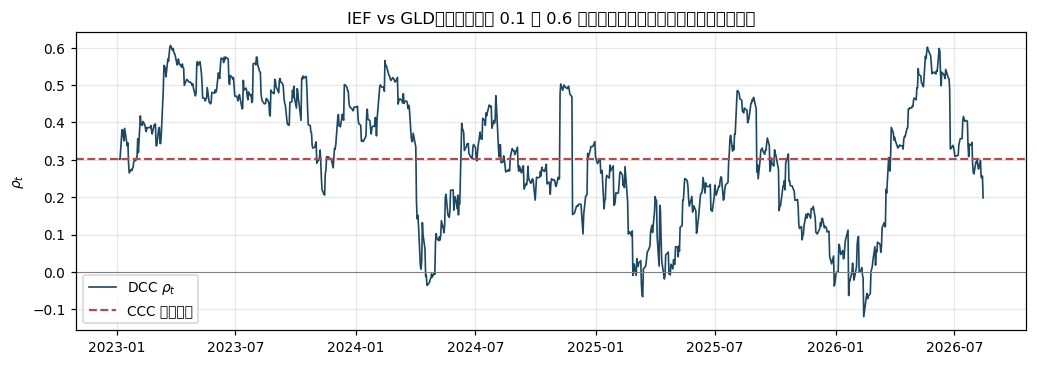

In [23]:
# ---------------------------------------------------------------------------
# 視覺化：動態相關路徑 vs 常數相關
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.plot(Z.index, rho_path, lw=1.1, color="#1b4965", label=r"DCC $\rho_t$")
ax.axhline(np.corrcoef(U[:, 0], U[:, 1])[0, 1], color="#bc4749", ls="--", lw=1.4,
           label="CCC 常數相關")
ax.axhline(0, color="grey", lw=0.7)
ax.set_title("IEF vs GLD：動態相關在 0.1 到 0.6 之間擺盪，常數相關完全掩蓋了這個結構")
ax.set_ylabel(r"$\rho_t$")
ax.legend()
fig.tight_layout()
plt.show()

---

## 單元 12｜ADCC：非對稱衝擊下的相關動態

> **統計技術**：非對稱動態條件相關；共同負向衝擊效果
>
> **對應程式**：`04_garch_dcc.py（階段二）`
>
> **原始文獻**：
> - Cappiello, L., Engle, R. F., & Sheppard, K. (2006). Asymmetric dynamics in the correlations of global equity and bond returns. Journal of Financial Econometrics, 4(4), 537–572.

### 原理：DCC 遺漏的非對稱

單元 8 的 GJR 處理了**單一資產**的波動非對稱。ADCC 把同樣的想法推廣到**相關性**：

> 當兩個資產**同時**下跌時，它們的相關性是否比同時上漲時更高？

這個問題對本研究至關重要。假說 B（鏈上流動性通道主導）預測的正是：
代幣與風險資產的相關性會**在共同下跌時飆升**——也就是避險最需要的時候失效。
若 ADCC 的非對稱參數顯著為正，就是支持假說 B 的直接證據。

### 公式

定義**負向指示殘差**（逐元素取負部）：

$$
n_t = \min(u_t, 0) \quad \text{（逐元素）}
$$

則 ADCC 的遞迴為

$$
Q_t = \left(\bar{Q} - a\bar{Q} - b\bar{Q} - g\bar{N}\right)
+ a  u_{t-1}u_{t-1}'
+ g  n_{t-1}n_{t-1}'
+ b  Q_{t-1}
$$

其中 $\bar{N} = \mathbb{E}[n_t n_t']$。

### 關鍵：$n_{t-1}n_{t-1}'$ 這一項只在「兩者同時為負」時才貢獻非零的非對角元素

這是理解 ADCC 的核心。考慮雙變量情形，$n_{t-1} = (n_1, n_2)'$：

外積 $n_{t-1}n_{t-1}'$ 的四個元素為：

| | 第 1 欄 | 第 2 欄 |
|---|---|---|
| **第 1 列** | $n_1^2$ | $n_1 n_2$ |
| **第 2 列** | $n_1 n_2$ | $n_2^2$ |

非對角元素 $n_1 n_2$ 只有在 $u_1 < 0$ **且** $u_2 < 0$ 時才不為零。
因此 $g > 0$ 代表：**共同的壞消息**特別能推高相關性。

| 情境 | $n_1$ | $n_2$ | $n_1 n_2$ | 對相關的貢獻 |
|---|---|---|---|---|
| 同時下跌 | $<0$ | $<0$ | $>0$ | **推高相關** |
| 一漲一跌 | $0$ 或 $<0$ | $<0$ 或 $0$ | $0$ | 無 |
| 同時上漲 | $0$ | $0$ | $0$ | 無 |

### 正定性條件

嚴格的條件是

$$
a + b + \delta g < 1, \qquad \delta = \lambda_{\max}\left(\bar{Q}^{-1/2}\bar{N}\bar{Q}^{-1/2}\right)
$$

本研究的實作用了一個**較簡單的充分條件**近似：

$$
a + b + g < 1
$$

程式碼註解明確記錄了這個簡化：

```python
# The ADCC positive-definiteness condition a+b+delta*g<1 (delta = max eigenvalue
# of Nbar) is approximated by the simpler sufficient-in-practice constraint
# a+b+g<1 (documented in the supplementary appendix).
```

> **為什麼這樣可以接受**：因為 $\delta \le 1$ 在實務上幾乎總是成立
> （$\bar{N}$ 只累積負部，其特徵值不會超過 $\bar{Q}$ 的），所以 $a+b+g<1$ 蘊含原條件。
> 這是**更嚴格**的約束，代價是可能排除少數合法的參數組合，但不會產生非法的 $Q_t$。
>
> **教學重點**：做這種簡化本身沒有問題 —— 有問題的是**不揭露**。
> 論文與程式碼都必須寫清楚哪裡用了近似、為什麼可以接受、代價是什麼。

In [24]:
# ---------------------------------------------------------------------------
# ADCC vs DCC：同一組配對的兩條路徑
# ---------------------------------------------------------------------------
res_adcc = minimize(neg_corr_loglik, [0.03, 0.90, 0.02], args=(U, True),
                    method="SLSQP",
                    bounds=[(1e-6, 0.3), (1e-6, 0.998), (1e-6, 0.3)],
                    constraints=[{"type": "ineq",
                                  "fun": lambda x: 0.998 - (x[0] + x[1] + x[2])}])
a_A, b_A, g_A = res_adcc.x
rho_adcc = corr_from_Q(build_Q_path(U, a_A, b_A, g_A, asymmetric=True))

print(f"DCC  : a = {a_hat:.4f}, b = {b_hat:.4f}")
print(f"ADCC : a = {a_A:.4f}, b = {b_A:.4f}, g = {g_A:.4f}")
print()
print(f"對數概似 DCC  = {-res_dcc.fun:10.4f}")
print(f"對數概似 ADCC = {-res_adcc.fun:10.4f}")
print(f"改善        = {-res_adcc.fun + res_dcc.fun:.4f}  （g 多了 1 個參數）")

# 同時為負的日子佔比
both_neg = ((U[:, 0] < 0) & (U[:, 1] < 0)).mean()
print(f"\n兩者同時為負的日子佔 {both_neg:.1%} —— 這些日子才是 g 起作用的地方")

DCC  : a = 0.0364, b = 0.9449
ADCC : a = 0.0364, b = 0.9449, g = 0.0000

對數概似 DCC  =    59.3967
對數概似 ADCC =    59.3967
改善        = -0.0000  （g 多了 1 個參數）

兩者同時為負的日子佔 30.1% —— 這些日子才是 g 起作用的地方


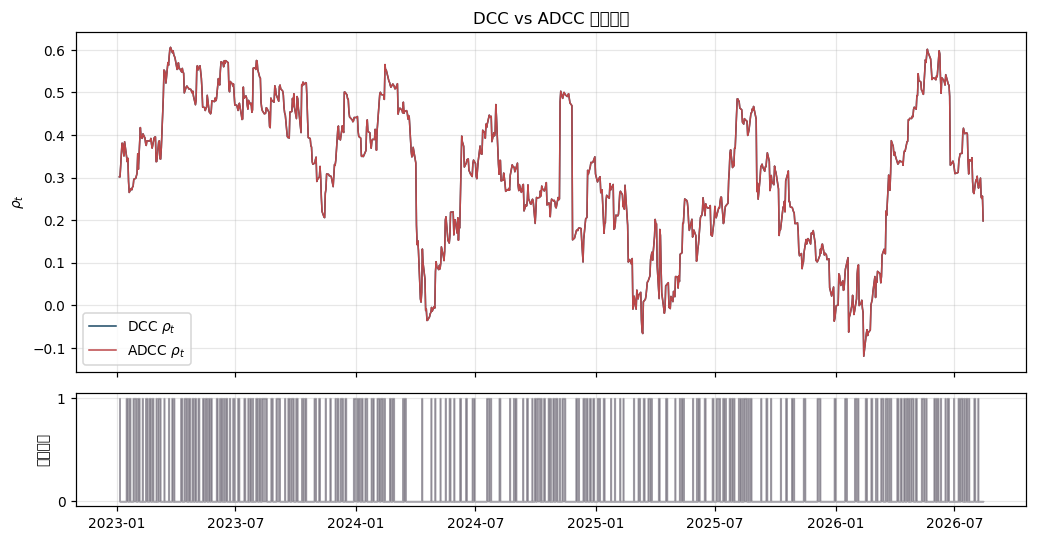

兩條路徑的平均差異     ：-0.00000
共同負向衝擊日的平均差異：+0.00000
其他日子的平均差異     ：-0.00000


In [25]:
# ---------------------------------------------------------------------------
# 展示 g 的作用：只在共同負向衝擊日推高相關
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(Z.index, rho_path, lw=1.0, color="#1b4965", label=r"DCC $\rho_t$")
axes[0].plot(Z.index, rho_adcc, lw=1.0, color="#bc4749", label=r"ADCC $\rho_t$")
axes[0].set_ylabel(r"$\rho_t$")
axes[0].legend()
axes[0].set_title("DCC vs ADCC 相關路徑")

both_neg_mask = (U[:, 0] < 0) & (U[:, 1] < 0)
axes[1].fill_between(Z.index, 0, both_neg_mask.astype(int),
                     step="mid", color="#6d6875", alpha=0.6)
axes[1].set_ylabel("同時為負")
axes[1].set_yticks([0, 1])
fig.tight_layout()
plt.show()

diff = rho_adcc - rho_path
print(f"兩條路徑的平均差異     ：{diff.mean():+.5f}")
print(f"共同負向衝擊日的平均差異：{diff[both_neg_mask].mean():+.5f}")
print(f"其他日子的平均差異     ：{diff[~both_neg_mask].mean():+.5f}")

---

## 單元 13｜CCC 對照組與概似比檢定

> **統計技術**：常數條件相關；概似比檢定；邊界解與檢定失效
>
> **對應程式**：`04_garch_dcc.py（階段二）`
>
> **原始文獻**：
> - Bollerslev, T. (1990)
> - Engle, R. F., & Sheppard, K. (2001). Theoretical and empirical properties of dynamic conditional correlation multivariate GARCH. NBER Working Paper 8554.

### 檢定的邏輯

估出一條看起來會動的 $\rho_t$ 路徑，**不代表相關性真的在動** ——
那條路徑也可能只是雜訊。需要一個正式的檢定。

**虛無假設**：相關為常數，即 $H_0: a = b = 0$。此時 $Q_t = \bar{Q}$ 對所有 $t$ 成立，
$R_t$ 退化成常數矩陣，模型即 Bollerslev (1990) 的 **CCC**。

**概似比統計量**：

$$
\mathrm{LR} = 2\left(\ell_{\mathrm{DCC}} - \ell_{\mathrm{CCC}}\right)
\xrightarrow{d}  \chi^2(2)
$$

自由度 2，因為限制了兩個參數。

程式碼直接利用了「$a=b=0$ 即 CCC」這個性質，不必另外寫一個模型：

```python
loglik_ccc = -neg_corr_loglik([0.0, 0.0], U, False)
lr_stat = max(0.0, 2 * (loglik_dcc - loglik_ccc))
lr_pvalue = 1 - chi2.cdf(lr_stat, df=2)
```

`max(0.0, ...)` 是數值保護：理論上 DCC 的概似不可能低於 CCC（後者是前者的受限版本），
但最佳化器若未完全收斂可能給出微小的負值。

### 陷阱一：邊界上的虛無假設

這是本單元最重要的內容。

$H_0: a = b = 0$ 落在參數空間 $\{a \ge 0, b \ge 0\}$ 的**邊界**上。
標準的 $\chi^2$ 漸近理論要求虛無假設在參數空間的**內點**，這裡並不滿足。

正確的漸近分配是 $\chi^2$ 分配的**混合**（Andrews 2001 型的結果），
其臨界值比標準 $\chi^2(2)$ **保守**。因此：

> 用 $\chi^2(2)$ 算出的 $p$ 值**偏小**，會**過度拒絕**虛無假設。

本研究的處理方式是誠實揭露：程式碼註解寫明這是
「Engle–Sheppard-style test ... see supplementary appendix for the exact-score-test caveat」。
而且因為本研究的實證結果是**幾乎都不拒絕**，這個偏誤的方向反而讓結論更保守 ——
真正的臨界值更高，會拒絕得更少。

### 陷阱二：邊界解讓檢定完全失去意義

比陷阱一更嚴重的問題。當最佳化器把 $a$ 或 $b$ 推到邊界（通常是 $a \to 0$），會發生什麼？

$$
a \to 0,   b \to 0  \Longrightarrow  Q_t \equiv \bar{Q}  \Longrightarrow  \rho_t \equiv \text{常數}
$$

此時 DCC 與 CCC 的概似**完全相同**，$\mathrm{LR} = 0$，$p = 1$。

**這個 $p = 1$ 不代表「相關性確實是常數」，只代表「最佳化器走到了角落」。**

兩者的差別是決定性的：

| 情境 | $p$ 值 | 正確解讀 |
|---|---|---|
| 內點解，$a, b$ 有意義的正值，LR 不顯著 | 大 | 有證據支持相關為常數 |
| **邊界解，$a = b = 0$** | $= 1$ | **無資訊**，不能當作支持常數的證據 |

### 本研究的實際狀況

34 組配對中：
- **18 組**至少有一個參數落在邊界
- **8 組** $a = b = 0$（相關路徑在建構上就是常數）
- **11 組**的 $\rho_t$ 標準差低於 $0.001$（數值噪音等級）

因此論文的寫法從「無法拒絕常數相關」改為「**相關性小且未顯示清楚的時變性**」，
並在表 5、表 11、表 12 中逐列標記退化配對。這個措辭差異不是修辭 ——
「接受虛無假設」在統計上本來就是不合法的推論，在有邊界解時更是完全站不住腳。

In [26]:
# ---------------------------------------------------------------------------
# LR 檢定結果全覽：拒絕的是哪些配對？
# ---------------------------------------------------------------------------
summ = pd.read_csv(PROC / "dcc_adcc_summary.csv", index_col=0)
show = summ[["n_obs", "a_DCC", "b_DCC", "g_ADCC", "mean_rho_DCC", "sd_rho_DCC",
             "LR_stat_vs_CCC", "LR_pvalue_vs_CCC"]].round(4)
display(show)

rej = summ[summ["LR_pvalue_vs_CCC"] < 0.05]
print(f"在 5% 水準下拒絕常數相關的配對：{len(rej)} / {len(summ)}")
for pair, row in rej.iterrows():
    print(f"    {pair:14} LR = {row['LR_stat_vs_CCC']:7.2f}, p = {row['LR_pvalue_vs_CCC']:.4f}, "
          f"mean rho = {row['mean_rho_DCC']:+.4f}")
print()
print("→ 全部三組都屬於傳統 ETF 對照組，沒有任何一組代幣配對拒絕。")

,n_obs,a_DCC,b_DCC,g_ADCC,mean_rho_DCC,sd_rho_DCC,LR_stat_vs_CCC,LR_pvalue_vs_CCC
pair,,,,,,,,
BUIDL-FANG,527,0.0000,0.6630,0.0402,0.0514,0.0000,0.0000,1.0000
BUIDL-SOXX,527,0.0000,0.0000,0.0168,0.0648,0.0000,0.0000,1.0000
BUIDL-SMH,527,0.0000,0.4580,0.0778,0.0794,0.0000,0.0000,1.0000
OUSG-FANG,879,0.1734,0.0000,0.0747,0.0167,0.0931,2.0874,0.3521
OUSG-SOXX,879,0.2364,0.0000,0.0983,0.0032,0.1168,4.9507,0.0841
OUSG-SMH,879,0.2316,0.0000,0.1004,-0.0031,0.1154,4.7217,0.0943
sUSDS-FANG,370,0.2085,0.6178,0.0000,-0.0299,0.1966,2.5118,0.2848
sUSDS-SOXX,370,0.1328,0.6081,0.3000,-0.0012,0.1240,0.1548,0.9255
sUSDS-SMH,370,0.1280,0.6158,0.3000,-0.0171,0.1218,0.2433,0.8855


在 5% 水準下拒絕常數相關的配對：3 / 34
    IEF-FANG       LR =   19.14, p = 0.0001, mean rho = +0.0452
    IEF-SOXX       LR =   13.44, p = 0.0012, mean rho = +0.0187
    IEF-GLD        LR =   28.83, p = 0.0000, mean rho = +0.3160

→ 全部三組都屬於傳統 ETF 對照組，沒有任何一組代幣配對拒絕。


In [27]:
# ---------------------------------------------------------------------------
# 邊界解診斷：把「無資訊的 p=1」與「真正不顯著」分開
# ---------------------------------------------------------------------------
TOL = 1e-6
summ["a_邊界"] = summ["a_DCC"].abs() < TOL
summ["b_邊界"] = summ["b_DCC"].abs() < TOL
summ["任一邊界"] = summ["a_邊界"] | summ["b_邊界"]
summ["兩者皆零"] = summ["a_邊界"] & summ["b_邊界"]
summ["路徑退化"] = summ["sd_rho_DCC"] < 1e-3

print(f"至少一個參數在邊界 : {int(summ['任一邊界'].sum()):2d} / {len(summ)}")
print(f"a 與 b 皆為零      : {int(summ['兩者皆零'].sum()):2d} / {len(summ)}")
print(f"rho 路徑退化       : {int(summ['路徑退化'].sum()):2d} / {len(summ)}   (sd < 0.001)")
print()

def classify(row):
    if row["兩者皆零"]:
        return "① 邊界解 → LR 無資訊"
    if row["路徑退化"]:
        return "② 路徑近乎常數 → 弱證據"
    if row["LR_pvalue_vs_CCC"] < 0.05:
        return "③ 拒絕常數相關"
    return "④ 內點解但不顯著"

summ["診斷"] = summ.apply(classify, axis=1)
print(summ["診斷"].value_counts().sort_index().to_string())
print()
print("『④ 內點解但不顯著』才是唯一可以說『有證據支持相關為常數』的類別。")
print("把 ① 和 ② 混進來當作證據，是本研究審計時修正的一個實質錯誤。")

至少一個參數在邊界 :  1 / 34
a 與 b 皆為零      :  0 / 34
rho 路徑退化       : 11 / 34   (sd < 0.001)

診斷
② 路徑近乎常數 → 弱證據    11
③ 拒絕常數相關           3
④ 內點解但不顯著         20

『④ 內點解但不顯著』才是唯一可以說『有證據支持相關為常數』的類別。
把 ① 和 ② 混進來當作證據，是本研究審計時修正的一個實質錯誤。


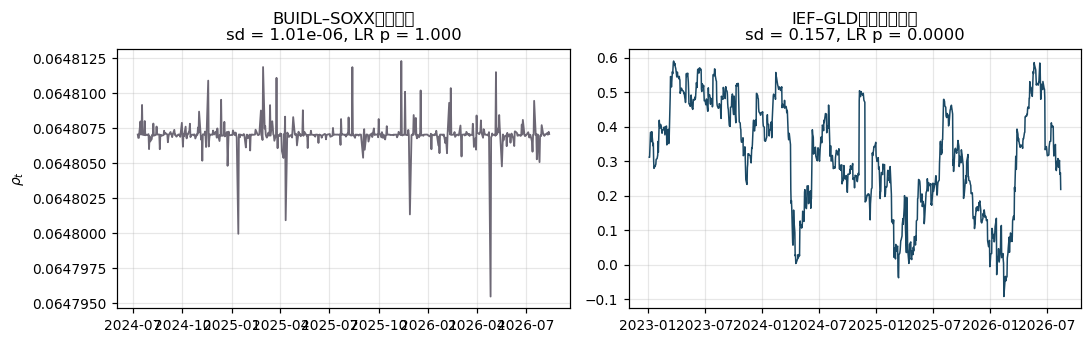

左圖的 y 軸尺度是 1e-6 等級 —— 那是浮點噪音，不是經濟訊號。
兩張圖若不看 y 軸刻度會誤以為左圖也在『變動』，這正是退化配對的危險之處。


In [28]:
# ---------------------------------------------------------------------------
# 視覺對照：退化路徑 vs 真實動態路徑
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

d_deg = pd.read_csv(PROC / "dcc_BUIDL_SOXX.csv", parse_dates=["date"]).set_index("date")
axes[0].plot(d_deg.index, d_deg["rho_dcc"], lw=1.2, color="#6d6875")
axes[0].set_title(f"BUIDL–SOXX（退化）\nsd = {d_deg['rho_dcc'].std():.2e}, LR p = "
                  f"{summ.loc['BUIDL-SOXX','LR_pvalue_vs_CCC']:.3f}")
axes[0].set_ylabel(r"$\rho_t$")

d_real = pd.read_csv(PROC / "dcc_IEF_GLD.csv", parse_dates=["date"]).set_index("date")
axes[1].plot(d_real.index, d_real["rho_dcc"], lw=1.0, color="#1b4965")
axes[1].set_title(f"IEF–GLD（真實動態）\nsd = {d_real['rho_dcc'].std():.3f}, LR p = "
                  f"{summ.loc['IEF-GLD','LR_pvalue_vs_CCC']:.4f}")

fig.tight_layout()
plt.show()

print("左圖的 y 軸尺度是 1e-6 等級 —— 那是浮點噪音，不是經濟訊號。")
print("兩張圖若不看 y 軸刻度會誤以為左圖也在『變動』，這正是退化配對的危險之處。")

---
---

# 第 5 篇　波動溢出與連結性

DCC 回答「兩個資產的相關性如何演變」，但它一次只看一對。
當系統裡有 12 個資產時，我們想問的是**系統層級**的問題：

- 整個系統的關聯程度有多高？（總連結性）
- 誰在傳遞衝擊、誰在接收？（方向性）
- 這些傳遞發生在幾天的時間尺度上？（頻域）

Diebold–Yilmaz 的連結性框架把這些問題全部化約成**預測誤差變異數分解**的運算。

---

## 單元 14｜VAR 與廣義預測誤差變異數分解（GFEVD）

> **統計技術**：向量自迴歸；移動平均表示；廣義（順序無關）變異數分解
>
> **對應程式**：`05_spillover.py`
>
> **原始文獻**：
> - Koop, G., Pesaran, M. H., & Potter, S. M. (1996). Impulse response analysis in nonlinear multivariate models. Journal of Econometrics, 74(1), 119–147.
> - Pesaran, M. H., & Shin, Y. (1998). Generalized impulse response analysis in linear multivariate models. Economics Letters, 58(1), 17–29.

### 步驟一：VAR 與其移動平均表示

$N$ 變量的 VAR($p$)：

$$
x_t = \sum_{i=1}^{p} \Phi_i x_{t-i} + \epsilon_t, \qquad \epsilon_t \sim (0, \Sigma)
$$

若定態，可反轉成無限階移動平均（Wold 表示）：

$$
x_t = \sum_{h=0}^{\infty} A_h \epsilon_{t-h}
$$

其中 $A_h$ 由遞迴式生成：$A_0 = I_N$，$A_h = \sum_{i=1}^{\min(h,p)} \Phi_i A_{h-i}$。

$A_h$ 的第 $(i,j)$ 元素就是「第 $j$ 個變數的一單位衝擊，$h$ 期後對第 $i$ 個變數的影響」。

### 步驟二：為什麼要用「廣義」分解

傳統的 FEVD 用 Cholesky 分解正交化衝擊。問題是 **Cholesky 分解依賴變數的排列順序** ——
排在前面的變數被假設「同期影響後面的變數，但不受後面影響」。

對本研究來說這是致命的：把 BUIDL 排在 FANG 前面還是後面，會給出不同的溢出結論，
而**沒有任何經濟理論能決定這個順序**。

Koop–Pesaran–Potter / Pesaran–Shin 的**廣義**分解不做正交化，
而是問「若第 $j$ 個變數受到一單位衝擊（其他變數依歷史相關結構同時反應），
對第 $i$ 個變數的 $H$ 期預測誤差變異數貢獻多少」：

$$
\theta_{ij}(H) = \frac{\sigma_{jj}^{-1} \sum_{h=0}^{H-1}\left(e_i' A_h \Sigma e_j\right)^2}
{\sum_{h=0}^{H-1} e_i' A_h \Sigma A_h' e_i}
$$

其中 $e_i$ 是第 $i$ 個位置為 1 的單位向量，$\sigma_{jj}$ 是 $\Sigma$ 的第 $j$ 個對角元素。

| 部分 | 意義 |
|---|---|
| 分子 $\left(e_i' A_h \Sigma e_j\right)^2$ | $j$ 的衝擊經 $h$ 期傳到 $i$ 的效果平方 |
| $\sigma_{jj}^{-1}$ | 把衝擊標準化成一單位 |
| 分母 | $i$ 的 $H$ 期總預測誤差變異數 |

### 步驟三：列標準化

因為不正交化，$\sum_j \theta_{ij}(H) \ne 1$。因此需要**列標準化**：

$$
\tilde{\theta}_{ij}(H) = \frac{\theta_{ij}(H)}{\sum_{k=1}^{N}\theta_{ik}(H)}
$$

標準化後 $\sum_j \tilde{\theta}_{ij} = 1$，可以解讀為「$i$ 的預測誤差變異數中，
有多少比例來自 $j$」。

> **代價**：標準化讓數字可比較、可加總，但也讓「廣義」分解不再有嚴格的變異數分解解釋
> （因為原始的 $\theta_{ij}$ 加總不為 1 反映的是衝擊間的相關性，標準化把這個資訊抹掉了）。
> 這是文獻的標準做法，但值得知道自己在交換什麼。

In [29]:
# ---------------------------------------------------------------------------
# 從零實作 GFEVD（與 05_spillover.py 相同的邏輯，逐步展開）
# ---------------------------------------------------------------------------
from statsmodels.tsa.api import VAR

def gfevd(var_res, H):
    names = var_res.names
    N = len(names)
    Sigma = var_res.sigma_u.values
    A = var_res.ma_rep(maxn=H - 1)          # A[0], ..., A[H-1]
    theta = np.zeros((N, N))
    for i in range(N):
        e_i = np.zeros(N); e_i[i] = 1.0
        # 分母：i 的 H 期總預測誤差變異數
        denom = sum(e_i @ A[h] @ Sigma @ A[h].T @ e_i for h in range(H))
        for j in range(N):
            e_j = np.zeros(N); e_j[j] = 1.0
            num = sum((e_i @ A[h] @ Sigma @ e_j) ** 2 for h in range(H)) / Sigma[j, j]
            theta[i, j] = num / denom if denom > 0 else np.nan
    theta_tilde = theta / theta.sum(axis=1, keepdims=True)   # 列標準化
    return theta, theta_tilde, names

# 用論文的 12 資產系統
SYS = {"FANG": "R_FANG", "SOXX": "R_SOXX", "SMH": "R_SMH", "SHV": "R_SHV", "IEF": "R_IEF",
       "BUIDL": "R_BUIDL_mkt", "OUSG": "R_OUSG_mkt",
       "BTC": "R_BTC", "ETH": "R_ETH", "UNI": "R_UNI", "AAVE": "R_AAVE", "GLD": "R_GLD"}
data = panel[list(SYS.values())].dropna()
data.columns = list(SYS.keys())
print(f"系統樣本：{len(data)} 個交易日 × {data.shape[1]} 個資產")

model = VAR(data)
p_opt = max(1, model.select_order(maxlags=5).aic)
res_var = model.fit(p_opt)
print(f"AIC 選定落後階數 p = {p_opt}")

theta_raw, theta_norm, names = gfevd(res_var, H=10)
print(f"\n標準化前每列加總（前 5 個）：{theta_raw.sum(axis=1)[:5].round(3)}")
print(f"標準化後每列加總（前 5 個）：{theta_norm.sum(axis=1)[:5].round(3)}")
print("→ 標準化前不為 1，正是廣義分解不正交化的直接後果")

系統樣本：524 個交易日 × 12 個資產


AIC 選定落後階數 p = 1

標準化前每列加總（前 5 個）：[2.788 2.98  3.088 1.111 1.109]
標準化後每列加總（前 5 個）：[1. 1. 1. 1. 1.]
→ 標準化前不為 1，正是廣義分解不正交化的直接後果


C:\Users\test\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


---

## 單元 15｜Diebold–Yilmaz 連結性指標體系

> **統計技術**：總連結性指數；方向性溢出；淨成對方向連結性
>
> **對應程式**：`05_spillover.py`
>
> **原始文獻**：
> - Diebold, F. X., & Yilmaz, K. (2012). Better to give than to receive. International Journal of Forecasting, 28(1), 57–66.
> - Diebold, F. X., & Yilmaz, K. (2014). On the network topology of variance decompositions. Journal of Econometrics, 182(1), 119–134.

### 從分解矩陣到四個指標

有了 $\tilde{\theta}_{ij}$，Diebold–Yilmaz 定義四個指標。全部都是這個矩陣的簡單彙總。

**（一）FROM：$i$ 從別人那裡接收的**

$$
\mathrm{FROM}_i = 100 \times \sum_{j \ne i} \tilde{\theta}_{ij}
= 100 \times (1 - \tilde{\theta}_{ii})
$$

**（二）TO：$j$ 傳給別人的**

$$
\mathrm{TO}_j = 100 \times \sum_{i \ne j} \tilde{\theta}_{ij}
$$

注意 FROM 是**列**加總、TO 是**行**加總。TO 沒有 1 的上界（一個資產可以影響很多其他資產）。

**（三）NET：淨溢出**

$$
\mathrm{NET}_i = \mathrm{TO}_i - \mathrm{FROM}_i
$$

- $\mathrm{NET}_i > 0$：**淨傳遞者**，衝擊的來源
- $\mathrm{NET}_i < 0$：**淨接收者**，衝擊的承受方

> 本研究的核心實證發現之一：代幣化國債的 NET 接近零（BUIDL $-0.80$、OUSG $+0.16$），
> 屬於**淨接收者一側**。這對金融穩定監理是個令人安心的訊號 ——
> 在目前的規模下，它們不是系統性風險的來源。

**（四）TCI：總連結性指數**

$$
\mathrm{TCI} = \frac{100}{N}\sum_{i \ne j}\tilde{\theta}_{ij}
= \frac{100}{N}\left(\sum_{i,j}\tilde{\theta}_{ij} - \mathrm{tr}(\tilde{\Theta})\right)
$$

值域 $[0, 100]$。$\mathrm{TCI} = 0$ 代表各資產完全獨立；接近 100 代表系統高度一體化。

**（五）NPDC：淨成對方向連結性**

$$
\mathrm{NPDC}_{ij} = \frac{100}{N}\left(\tilde{\theta}_{ji} - \tilde{\theta}_{ij}\right)
$$

這是網路圖的邊權重：$\mathrm{NPDC}_{ij} > 0$ 代表 $i$ 淨傳遞給 $j$。

### 跨方法交叉驗證：本研究的方法論貢獻

本研究刻意用**兩個完全獨立的實作**估計同一個 12 資產系統：

| | Python 靜態估計 | R 的 TVP-VAR |
|---|---|---|
| 語言 | Python | R |
| 套件 | 自行實作 + statsmodels | `ConnectednessApproach` |
| 參數 | 靜態，AIC 選階 | 時變，Kalman 濾波 |
| 總連結性 | 43.3% | 45.4% |

兩者相差不到 2 個百分點，且 12 個變數中有 **10 個**的 NET 符號一致。

> **必須誠實報告的部分**：有 **2 個不一致** —— IEF（$-4.31$ vs $+0.09$）與
> OUSG（$+0.16$ vs $-2.06$）。論文初稿寫的是「**每一個**變數的淨溢出符號都一致」，
> 審計時發現這句話被自己的表格推翻。
>
> 修正後的寫法是：兩者在 12 個變數中有 10 個一致，不一致的兩個都**接近零**，
> 因此分歧是「一個近乎中性的資產微幅偏向哪一側」，而非「它在系統中的角色」。
> 對 OUSG 這個焦點資產，安全的解讀是**在兩個估計量下都近乎中性**。
>
> 這個修正讓宣稱變弱，但也讓它站得住腳。交叉驗證的價值恰恰在於它會**抓到不一致** ——
> 如果只是拿來確認「我們都對」，那就沒有做的必要。

In [30]:
# ---------------------------------------------------------------------------
# 從分解矩陣計算四個指標
# ---------------------------------------------------------------------------
def connectedness_table(theta_tilde, names):
    N = len(names)
    diag = np.diag(theta_tilde)
    TO = 100 * (theta_tilde.sum(axis=0) - diag)      # 行加總
    FROM = 100 * (theta_tilde.sum(axis=1) - diag)    # 列加總
    NET = TO - FROM
    TCI = 100 * (theta_tilde.sum() - np.trace(theta_tilde)) / N
    npdc = pd.DataFrame(index=names, columns=names, dtype=float)
    for i, ni in enumerate(names):
        for j, nj in enumerate(names):
            npdc.loc[ni, nj] = 100 * (theta_tilde[j, i] - theta_tilde[i, j]) / N
    return pd.DataFrame({"TO": TO, "FROM": FROM, "NET": NET}, index=names), TCI, npdc

tbl, tci, npdc = connectedness_table(theta_norm, names)
display(tbl.sort_values("NET", ascending=False).round(2))
print(f"總連結性指數 TCI = {tci:.2f}%")
print()
print("淨傳遞者（NET > 0）：", ", ".join(tbl[tbl.NET > 0].sort_values('NET', ascending=False).index))
print("淨接收者（NET < 0）：", ", ".join(tbl[tbl.NET < 0].sort_values('NET').index))

,TO,FROM,NET
ETH,84.0200,70.5800,13.4400
SMH,76.3100,68.1400,8.1700
SOXX,71.7400,67.0700,4.6700
IEF,12.5700,12.4900,0.0900
BTC,66.0000,66.5500,-0.5500
BUIDL,2.5600,3.2200,-0.6600
OUSG,3.6500,5.7200,-2.0600
FANG,62.3200,64.7000,-2.3700
SHV,8.7300,12.1700,-3.4400
AAVE,60.6100,64.8100,-4.2000


總連結性指數 TCI = 43.29%

淨傳遞者（NET > 0）： ETH, SMH, SOXX, IEF
淨接收者（NET < 0）： GLD, UNI, AAVE, SHV, FANG, OUSG, BUIDL, BTC


In [31]:
# ---------------------------------------------------------------------------
# 兩個獨立實作的交叉驗證：逐變數比對符號
# ---------------------------------------------------------------------------
tvp = pd.read_csv(PROC / "r_tvpvar_static_table.csv").set_index("variable")
sta = pd.read_csv(PROC / "spillover_static_C.csv", index_col=0)

cmp = pd.DataFrame({
    "TVP-VAR (R)": tvp["NET"],
    "靜態 GFEVD (Python)": sta["NET"],
})
cmp["符號一致"] = np.sign(cmp["TVP-VAR (R)"]) == np.sign(cmp["靜態 GFEVD (Python)"])
display(cmp.round(3))

agree = int(cmp["符號一致"].sum())
print(f"符號一致：{agree} / {len(cmp)}")
print()
print("不一致的變數：")
for v, row in cmp[~cmp["符號一致"]].iterrows():
    print(f"    {v:6} TVP-VAR = {row['TVP-VAR (R)']:+7.2f}, 靜態 = {row['靜態 GFEVD (Python)']:+7.2f}"
          f"   （兩者皆接近零，分歧在於偏向哪一側）")

,TVP-VAR (R),靜態 GFEVD (Python),符號一致
FANG,-0.3500,-2.3700,True
SOXX,6.2700,4.6680,True
SMH,8.9800,8.1750,True
SHV,-10.3700,-3.4360,True
IEF,-4.3100,0.0850,False
BUIDL,-0.8000,-0.6580,True
OUSG,0.1600,-2.0630,False
BTC,-0.8700,-0.5520,True
ETH,14.2700,13.4420,True
UNI,-2.6700,-5.4890,True


符號一致：10 / 12

不一致的變數：
    IEF    TVP-VAR =   -4.31, 靜態 =   +0.09   （兩者皆接近零，分歧在於偏向哪一側）
    OUSG   TVP-VAR =   +0.16, 靜態 =   -2.06   （兩者皆接近零，分歧在於偏向哪一側）


---

## 單元 16｜TVP-VAR：Kalman 濾波與遺忘因子

> **統計技術**：時變參數 VAR；Kalman 濾波；遺忘因子（forgetting factor）
>
> **對應程式**：`10_r_tvpvar_frequency.R`
>
> **原始文獻**：
> - Antonakakis, N., Chatziantoniou, I., & Gabauer, D. (2020). Refined measures of dynamic connectedness based on time-varying parameter vector autoregressions. Journal of Risk and Financial Management, 13(4), 84.

### 原理：滾動窗口的三個缺陷

要得到「隨時間變動的連結性」，最直覺的做法是**滾動窗口**：每 100 天估一次 VAR。
本研究的 Python 端就是這樣做的（`05_spillover.py`）。但這個做法有三個問題：

1. **窗口長度是任意的**：100 天？250 天？結果會不同，而沒有原則能決定
2. **觀測值權重是階梯函數**：窗口內的第 1 天與第 100 天權重相同，窗口外權重驟降為 0
3. **樣本浪費**：前 100 天完全沒有估計值

TVP-VAR 用狀態空間模型解決全部三個。

### 狀態空間表示

**觀測方程**（VAR 本身，但係數帶時間下標）：

$$
x_t = Z_t \beta_t + \epsilon_t, \qquad \epsilon_t \sim N(0, S_t)
$$

**狀態方程**（係數自己隨機漫步）：

$$
\beta_t = \beta_{t-1} + \nu_t, \qquad \nu_t \sim N(0, R_t)
$$

其中 $Z_t$ 由落後的 $x$ 構成，$\beta_t$ 是拉平的 VAR 係數向量。

### Kalman 濾波遞迴

**預測步**

$$
\beta_{t|t-1} = \beta_{t-1|t-1}, \qquad
\Sigma_{t|t-1} = \Sigma_{t-1|t-1} + R_t
$$

**更新步**

$$
K_t = \Sigma_{t|t-1} Z_t' \left(Z_t \Sigma_{t|t-1} Z_t' + S_t\right)^{-1}
$$

$$
\beta_{t|t} = \beta_{t|t-1} + K_t\left(x_t - Z_t \beta_{t|t-1}\right)
$$

$$
\Sigma_{t|t} = \Sigma_{t|t-1} - K_t Z_t \Sigma_{t|t-1}
$$

$K_t$ 是 **Kalman 增益**：它決定「新觀測的預測誤差要修正多少係數」。
若觀測噪音 $S_t$ 大，$K_t$ 小，係數變動保守；反之則靈敏。

### 遺忘因子：本方法的關鍵

直接估計 $R_t$（狀態噪音共變異數）需要大量參數。Antonakakis 等人採用
Koop–Korobilis 的**遺忘因子**技巧，用一個純量 $\kappa_1$ 取代整個矩陣：

$$
R_t = \left(\frac{1}{\kappa_1} - 1\right)\Sigma_{t-1|t-1}
\quad\Longrightarrow\quad
\Sigma_{t|t-1} = \frac{1}{\kappa_1}\Sigma_{t-1|t-1}
$$

誤差共變異數則用 EWMA 更新：

$$
S_t = \kappa_2 S_{t-1} + (1 - \kappa_2)\hat{\epsilon}_t \hat{\epsilon}_t'
$$

### 遺忘因子的直觀：等效窗口長度

$\kappa$ 越接近 1，過去的資訊衰減越慢。其**等效記憶長度**約為

$$
\text{有效觀測數} \approx \frac{1}{1 - \kappa}
$$

| $\kappa$ | 有效窗口 | 特性 |
|---|---|---|
| 0.99 | ~100 天 | 平滑，適合偵測結構性趨勢 |
| 0.96 | ~25 天 | 靈敏，適合偵測短期震盪 |
| 0.94 | ~17 天 | 非常靈敏，噪音較多 |

本研究主設定為 $\kappa_1 = \kappa_2 = 0.99$，並用 $(0.96, 0.94)$ 做**敏感度檢查**。

> **敏感度檢查的結果本身就是發現**：
> TCI 從 45.4%（0.99/0.99）上升到 54.6%（0.96/0.94）。
> 這不是「哪個對」的問題 —— 更靈敏的設定會捕捉到更多短期同步，
> 因此測到更高的連結性。報告兩者，並說明差異的來源，比只報一個數字誠實得多。

In [32]:
# ---------------------------------------------------------------------------
# 遺忘因子敏感度：TCI 對 kappa 的反應
# ---------------------------------------------------------------------------
kap = pd.read_csv(PROC / "r_tvpvar_kappa_sensitivity.csv")
display(kap.round(3))

eff = lambda k: 1 / (1 - k)
print(f"kappa = 0.99 → 有效窗口 ≈ {eff(0.99):.0f} 個交易日")
print(f"kappa = 0.96 → 有效窗口 ≈ {eff(0.96):.0f} 個交易日")
print(f"kappa = 0.94 → 有效窗口 ≈ {eff(0.94):.0f} 個交易日")
print()
print(f"TCI 差異 = {kap['mean_TCI'].iloc[1] - kap['mean_TCI'].iloc[0]:.1f} 個百分點")
print("解讀：更短的有效窗口捕捉更多短期同步 → 更高的測得連結性。")
print("      兩個數字都是對的，只是在回答略微不同的問題。")

,kappa,mean_TCI
0,0.99/0.99,45.3980
1,0.96/0.94,54.6250


kappa = 0.99 → 有效窗口 ≈ 100 個交易日
kappa = 0.96 → 有效窗口 ≈ 25 個交易日
kappa = 0.94 → 有效窗口 ≈ 17 個交易日

TCI 差異 = 9.2 個百分點
解讀：更短的有效窗口捕捉更多短期同步 → 更高的測得連結性。
      兩個數字都是對的，只是在回答略微不同的問題。


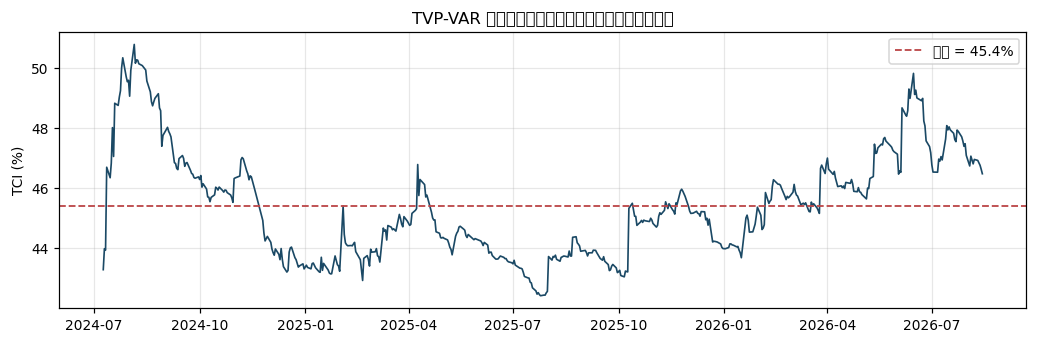

TCI 區間：[42.4%, 50.8%]
滾動窗口做不到的事：每一天都有估計值，且權重平滑衰減而非階梯跳動。


In [33]:
# ---------------------------------------------------------------------------
# TVP-VAR 的時變 TCI 路徑
# ---------------------------------------------------------------------------
tci_ts = pd.read_csv(PROC / "r_tvpvar_tci_series.csv", parse_dates=["date"]).set_index("date")

fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.plot(tci_ts.index, tci_ts["TCI"], lw=1.1, color="#1b4965")
ax.axhline(tci_ts["TCI"].mean(), color="#bc4749", ls="--", lw=1.2,
           label=f"平均 = {tci_ts['TCI'].mean():.1f}%")
ax.set_title("TVP-VAR 總連結性指數：系統一體化程度隨時間變動")
ax.set_ylabel("TCI (%)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"TCI 區間：[{tci_ts['TCI'].min():.1f}%, {tci_ts['TCI'].max():.1f}%]")
print("滾動窗口做不到的事：每一天都有估計值，且權重平滑衰減而非階梯跳動。")

---

## 單元 17｜Baruník–Křehlík 頻域分解

> **統計技術**：頻譜表示；廣義因果頻譜；頻帶連結性
>
> **對應程式**：`10_r_tvpvar_frequency.R`
>
> **原始文獻**：
> - Baruník, J., & Křehlík, T. (2018). Measuring the frequency dynamics of financial connectedness and systemic risk. Journal of Financial Econometrics, 16(2), 271–296.

### 原理：時域指標混淆了兩種不同的溢出

單元 15 的 TCI 是一個數字，但它把兩種本質不同的現象加在一起：

- **短期溢出**：流動性衝擊、造市商調整部位、當日套利 → 幾天內完成
- **長期溢出**：基本面重新定價、資產配置的結構性移轉 → 數月才顯現

一個「TCI = 45%」的系統，可能是「短期高度同步但長期無關」，
也可能是「長期深度整合但日常獨立」。這兩者對金融穩定的含意完全不同。

Baruník–Křehlík 把變異數分解搬到**頻域**，讓我們能分開來看。

### 頻譜表示

VAR 的移動平均係數 $A_h$ 的傅立葉轉換：

$$
\Psi(e^{-i\omega}) = \sum_{h=0}^{\infty} e^{-i\omega h} A_h
$$

**廣義因果頻譜**（單元 14 的 GFEVD 在頻率 $\omega$ 上的版本）：

$$
\left(f(\omega)\right)_{ij} =
\frac{\sigma_{jj}^{-1}\left|\left(\Psi(e^{-i\omega})\Sigma\right)_{ij}\right|^2}
{\left(\Psi(e^{-i\omega})\Sigma\Psi'(e^{+i\omega})\right)_{ii}}
$$

**頻帶內加總**：對頻帶 $d = (\underline{\omega}, \overline{\omega})$，

$$
\tilde{\theta}_{ij}(d) = \frac{1}{2\pi}\int_{d} \Gamma_i(\omega)\left(f(\omega)\right)_{ij}  d\omega
$$

其中 $\Gamma_i(\omega)$ 是把頻譜密度標準化的權重函數。

### 關鍵性質：頻帶可加

$$
\tilde{\theta}_{ij} = \sum_{d} \tilde{\theta}_{ij}(d)
$$

各頻帶的連結性**加總回時域的連結性**。這讓「45.4 點的總連結性中，有多少來自短期」
成為一個有明確答案的問題。

### 頻帶的設定

程式碼把 $[0, \pi]$ 分割成三段：

```r
partition = c(pi, pi/5, pi/20, 0)
```

轉換成週期：頻率 $\omega$ 對應週期 $2\pi/\omega$ 天。

| 分割 | 頻率區間 | 週期 | 標籤 |
|---|---|---|---|
| $(\pi/5, \pi)$ | 高頻 | 2–10 天 | `1-5` |
| $(\pi/20, \pi/5)$ | 中頻 | 10–40 天 | `5-20` |
| $(0, \pi/20)$ | 低頻 | 40 天以上 | `20-Inf` |

### 本研究的結果與一個被修正的錯誤

實際的頻帶分解為：

$$
\underbrace{45.4}_{\text{總}} = \underbrace{37.6}_{\text{1-5 天}} + \underbrace{5.8}_{\text{5-20 天}} + \underbrace{2.0}_{\text{20 天以上}}
$$

即 **83% 的連結性在一週內完成**。這個發現對監理有直接含意：
代幣化國債若有溢出，是**幾天的事，不是幾個月的事**。

> **論文初稿寫的是「約 41 點來自 1-5 天、3 點來自 5-20 天、不到 1 點來自 20 天以上」**。
> 三個數字全錯。定性結論（短期主導）成立，但數字對不上表格。
>
> 這類錯誤特別危險，因為它**通過所有的合理性檢查** —— 41 + 3 + 1 ≈ 45，
> 加總大致對得起來，方向也對，只有真的去比對來源檔案才會發現。
> 教訓是：正文裡的每一個數字都必須有一條可追溯到輸出檔案的路徑（見單元 26）。

In [34]:
# ---------------------------------------------------------------------------
# 頻帶分解：驗證可加性與各頻帶佔比
# ---------------------------------------------------------------------------
freq_tci = pd.read_csv(PROC / "r_frequency_tci_series.csv").groupby("band")["TCI"].mean()
order = ["1-5", "5-20", "20-Inf", "Total"]
freq_tci = freq_tci.reindex([b for b in order if b in freq_tci.index])

bands = freq_tci.drop("Total")
tbl = pd.DataFrame({
    "TCI": bands,
    "佔總連結性": bands / freq_tci["Total"],
})
tbl.index = ["1–5 天（短期）", "5–20 天（中期）", "20 天以上（長期）"]
display(tbl.round(3))

print(f"三個頻帶加總 = {bands.sum():.2f}")
print(f"時域總連結性 = {freq_tci['Total']:.2f}")
print(f"可加性檢查   = {abs(bands.sum() - freq_tci['Total']):.4f}  （應接近 0）")
print()
print(f"→ {bands.iloc[0]/freq_tci['Total']:.0%} 的連結性在一週內完成")

,TCI,佔總連結性
1–5 天（短期）,37.6160,0.8290
5–20 天（中期）,5.7590,0.1270
20 天以上（長期）,2.0220,0.0450


三個頻帶加總 = 45.40
時域總連結性 = 45.40
可加性檢查   = 0.0000  （應接近 0）

→ 83% 的連結性在一週內完成


band,1-5,5-20,20-Inf,Total
variable,,,,
ETH,13.3900,0.6500,0.1900,14.2300
SMH,7.2900,1.2100,0.4300,8.9300
SOXX,5.1800,0.7900,0.2700,6.2400
OUSG,-0.3500,0.4400,0.1600,0.2500
FANG,2.4300,-2.0900,-0.8100,-0.4700
BUIDL,0.0500,-0.5800,-0.2500,-0.7800
BTC,-1.9000,0.7200,0.3100,-0.8700
UNI,-2.8900,0.2000,0.0600,-2.6200
AAVE,-4.6200,0.9800,0.3900,-3.2500


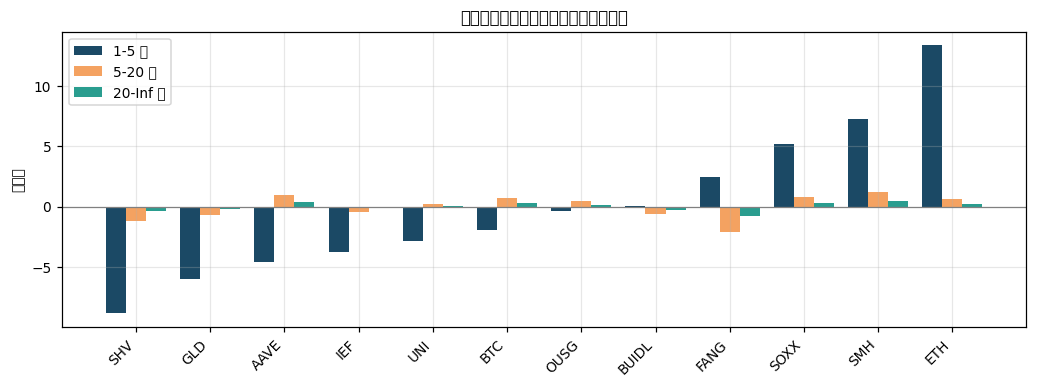

BUIDL 的淨溢出從總計 -0.80 縮到 20 天以上頻帶的 -0.25 —— 本已微小的溢出在長期尺度上更小。


In [35]:
# ---------------------------------------------------------------------------
# 逐資產的頻帶淨溢出：長期溢出幾乎消失
# ---------------------------------------------------------------------------
fn = pd.read_csv(PROC / "r_frequency_static_table.csv")
pivot = fn.pivot(index="variable", columns="band", values="NET")
pivot = pivot[[c for c in ["1-5", "5-20", "20-Inf", "Total"] if c in pivot.columns]]
display(pivot.sort_values("Total", ascending=False).round(2))

fig, ax = plt.subplots(figsize=(9.5, 3.6))
sub = pivot.drop(columns="Total").sort_values("1-5")
x = np.arange(len(sub))
w = 0.27
for k, (col, c) in enumerate(zip(sub.columns, ["#1b4965", "#f4a261", "#2a9d8f"])):
    ax.bar(x + (k-1)*w, sub[col], width=w, label=f"{col} 天", color=c)
ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=45, ha="right")
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("淨溢出")
ax.set_title("頻帶淨溢出：短期主導，長期幾乎歸零")
ax.legend()
fig.tight_layout()
plt.show()

print("BUIDL 的淨溢出從總計 -0.80 縮到 20 天以上頻帶的 "
      f"{pivot.loc['BUIDL','20-Inf']:+.2f} —— 本已微小的溢出在長期尺度上更小。")

---
---

# 第 6 篇　時頻分析

第 5 篇的頻域分解告訴我們溢出**發生在哪個時間尺度**，但它給的是全樣本平均。
小波分析同時保留**時間**與**頻率**兩個維度，能回答更細的問題：

> 這兩個資產是在 2024 年的短週期上共動，還是在 2025 年的長週期上共動？

這對本研究特別重要，因為代幣化國債市場在樣本期間內規模成長了數倍 ——
早期與晚期的行為未必相同。

---

## 單元 18｜連續小波轉換與 Morlet 母小波

> **統計技術**：連續小波轉換（CWT）；Morlet 小波；時頻不確定性原理
>
> **對應程式**：`06_wavelet.py`
>
> **原始文獻**：
> - Torrence, C., & Compo, G. P. (1998). A practical guide to wavelet analysis. Bulletin of the American Meteorological Society, 79(1), 61–78.
> - Torrence, C., & Webster, P. J. (1999). Interdecadal changes in the ENSO-monsoon system. Journal of Climate, 12(8), 2679–2690.

### 原理：傅立葉轉換丟掉了時間

標準的傅立葉轉換把序列分解成不同頻率的正弦波：

$$
\hat{x}(\omega) = \int_{-\infty}^{\infty} x(t)  e^{-i\omega t}  dt
$$

問題是基底函數 $e^{-i\omega t}$ **在整個時間軸上都存在**，所以 $\hat{x}(\omega)$
告訴你「整段期間有多少 $\omega$ 頻率的成分」，但完全不知道它發生在什麼時候。

對金融序列來說這是致命的：2020 年 3 月的高頻共動與 2023 年的高頻共動，
在傅立葉頻譜上長得一模一樣。

### 小波的解法：有限支撐的基底

小波用一個**局部化**的基底函數，同時沿時間平移與尺度伸縮：

$$
W_x(s, \tau) = \frac{1}{\sqrt{s}}\sum_{t} x_t  \psi^*\left(\frac{t - \tau}{s}\right)
$$

| 參數 | 作用 |
|---|---|
| $\tau$ | **平移**：小波中心落在哪個時點 |
| $s$ | **尺度**：小波拉多寬（大 $s$ = 低頻 = 長週期） |
| $1/\sqrt{s}$ | 能量標準化，讓不同尺度的係數可比較 |

### Morlet 母小波

$$
\psi_0(\eta) = \pi^{-1/4}  e^{i\omega_0 \eta}  e^{-\eta^2/2}
$$

它是一個**被高斯窗包絡的複數正弦波**：

- $e^{i\omega_0\eta}$：振盪部分，提供頻率解析
- $e^{-\eta^2/2}$：高斯窗，提供時間局部化
- $\pi^{-1/4}$：能量標準化

**為什麼選 $\omega_0 = 6$**（本研究與絕大多數文獻的預設）：

1. 滿足**可容許性條件**（小波均值為零）到數值精度
2. 在 $\omega_0 = 6$ 時，尺度 $s$ 與傅立葉週期幾乎相等：$\text{週期} \approx 1.03  s$，
   讓「尺度」可以直接讀成「天數」
3. 在時間解析與頻率解析之間取得公認的良好平衡

**為什麼要用複數小波**：複數形式讓我們同時得到**振幅**與**相位**。
相位資訊是單元 19 判斷「誰領先誰」的基礎。

### 時頻不確定性原理

小波不是免費的午餐。Heisenberg–Gabor 極限規定：

$$
\Delta t \cdot \Delta \omega \ge \frac{1}{2}
$$

你不可能同時無限精確地知道「什麼時候」與「什麼頻率」。小波的取捨是：

- **高頻（小 $s$）**：時間解析好，頻率解析差
- **低頻（大 $s$）**：頻率解析好，時間解析差

這個取捨直接導致單元 19 的影響錐問題。

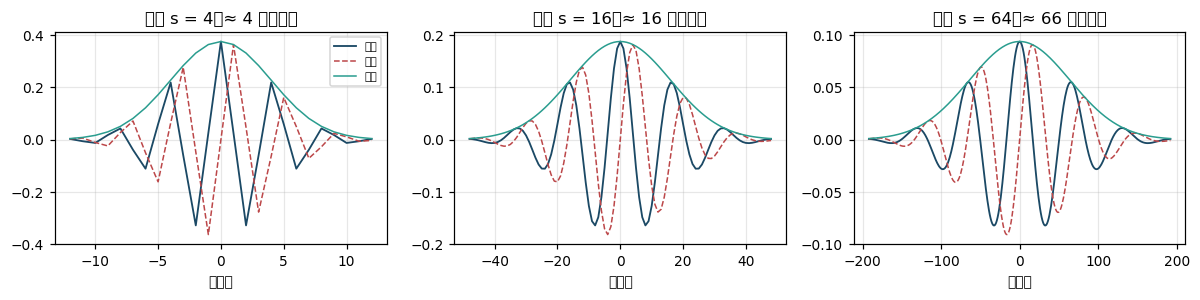

觀察：s 越大，小波越寬 → 頻率解析越好，但時間定位越模糊。
      這就是時頻不確定性原理在圖上的樣子。


In [36]:
# ---------------------------------------------------------------------------
# 視覺化 Morlet 小波：不同尺度下的形狀
# ---------------------------------------------------------------------------
def morlet(eta, w0=6.0):
    return np.pi**-0.25 * np.exp(1j * w0 * eta) * np.exp(-eta**2 / 2)

fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
for ax, s in zip(axes, [4, 16, 64]):
    t = np.arange(-3*s, 3*s + 1)
    psi = morlet(t / s) / np.sqrt(s)
    ax.plot(t, psi.real, lw=1.2, color="#1b4965", label="實部")
    ax.plot(t, psi.imag, lw=1.0, color="#bc4749", ls="--", label="虛部")
    ax.plot(t, np.abs(psi), lw=1.0, color="#2a9d8f", label="包絡")
    ax.set_title(f"尺度 s = {s}（≈ {1.03*s:.0f} 天週期）")
    ax.set_xlabel("交易日")
axes[0].legend(fontsize=7)
fig.tight_layout()
plt.show()

print("觀察：s 越大，小波越寬 → 頻率解析越好，但時間定位越模糊。")
print("      這就是時頻不確定性原理在圖上的樣子。")

---

## 單元 19｜小波同調、影響錐與蒙地卡羅顯著性

> **統計技術**：交叉小波；小波同調（WTC）；影響錐（COI）；AR(1) 替代資料檢定
>
> **對應程式**：`06_wavelet.py`
>
> **原始文獻**：
> - Grinsted, A., Moore, J. C., & Jevrejeva, S. (2004). Application of the cross wavelet transform and wavelet coherence to geophysical time series. Nonlinear Processes in Geophysics, 11(5/6), 561–566.

### 從單序列到兩序列

**交叉小波轉換**：

$$
W_{xy}(s, \tau) = W_x(s, \tau)  W_y^*(s, \tau)
$$

它的振幅代表「兩序列在該時點該尺度上共同的能量」，相位代表「兩者的相位差」。

### 小波同調（Wavelet Coherence, WTC）

交叉小波的振幅會被兩序列各自的波動放大，因此需要標準化。
小波同調是**時頻空間裡的局部相關係數平方**：

$$
R^2(s, \tau) =
\frac{\left| S\left(s^{-1} W_{xy}(s,\tau)\right)\right|^2}
{S\left(s^{-1}\left|W_x(s,\tau)\right|^2\right)\cdot S\left(s^{-1}\left|W_y(s,\tau)\right|^2\right)}
$$

其中 $S(\cdot)$ 是**平滑運算子**（同時在時間與尺度方向平滑）。

**為什麼一定要平滑**：不平滑的話，由 Cauchy–Schwarz 不等式，
$R^2 \equiv 1$ 處處成立 —— 兩個複數的「相關」在單點上總是完美的。
平滑引入了「鄰域」的概念，才讓 $R^2 < 1$ 有意義。

$R^2 \in [0, 1]$：1 代表該時點該尺度上完全共動，0 代表無關。

### 影響錐（Cone of Influence, COI）

小波轉換是卷積運算，在序列的**兩端**，小波會延伸到資料之外。
實作上用補零或鏡射處理，但這會讓邊緣的係數被人為壓低。

影響錐標記出「受邊緣效應污染」的區域。對 Morlet 小波，e-折疊時間為 $\sqrt{2}s$，
因此在距離端點 $\sqrt{2}s$ 以內的區域不可信。

**關鍵後果**：尺度越大，受污染的區域越大。對一個 $T = 528$ 的序列，
128 天尺度的可用區間可能只剩中間一小段。

程式碼因此**只在影響錐內做頻帶平均**：

```python
for ti in range(WCT.shape[1]):
    valid_scales = mask_period & (periods < coi[ti])   # 只取錐內
    if valid_scales.any():
        vals.append(WCT[valid_scales, ti].mean())
```

> **這一行對本研究的一個結論起了決定性作用**。BUIDL–FANG 在 32–128 天頻帶的同調度是 0.350，
> 高於 IEF–GLD 的 0.272。但 BUIDL 只有 528 個觀測，扣掉影響錐後，
> 32–128 天尺度上可用的時間跨度非常窄。
>
> 論文因此不把這一格解讀成「低頻真實關聯」，而明說樣本長度限制了可信度。
> 初稿曾寫「IEF–GLD 是唯一在最長尺度仍高於 0.27 的配對」—— 被自己的表格推翻，
> 審計時修正為分別陳述並加上樣本長度的但書。

### 蒙地卡羅顯著性

$R^2$ 的分配沒有解析解。標準做法是**替代資料檢定（surrogate data test）**：

1. 估計兩序列各自的 AR(1) 參數
2. 生成 $M$ 組具有相同 AR(1) 結構的隨機序列
3. 對每組計算 WTC
4. 取逐點的 95 百分位作為顯著門檻

虛無假設是「兩序列都只是 AR(1) 紅噪音，彼此獨立」。

本研究用 `mc_count=60`（pycwt 預設為 300），程式碼註解說明了理由與代價：

```python
# mc_count reduced from the pycwt default of 300 to 60 Monte Carlo AR(1)
# surrogates to keep runtime tractable; the resulting 95% significance
# contour is a coarser but still valid approximation
```

> 60 次替代對 95 百分位的估計確實較粗糙（標準誤約 $\sqrt{0.05 \times 0.95 / 60} \approx 0.028$，即 2.8 個百分點）。
> 這是可接受的取捨，因為**本研究報告的頻帶平均同調度不使用顯著性等高線** ——
> 只用同調度的量值本身。R 端的 `12_r_partial_wavelet.R` 甚至只用 `nrands = 10`，
> 註解也明確說明了同樣的理由。

In [37]:
# ---------------------------------------------------------------------------
# 頻帶平均同調度：讀取結果並解讀影響錐的影響
# ---------------------------------------------------------------------------
wav = pd.read_csv(PROC / "wavelet_band_summary.csv", index_col=0)
display(wav.round(3))

print("觀察：")
print(f"  1. 同調度全數落在 {wav.iloc[:, :3].values.min():.2f}–{wav.iloc[:, :3].values.max():.2f}，"
      "屬中等程度，沒有任何配對呈現壓倒性共動")
print(f"  2. OUSG 的配對在三個頻帶上異常平坦（約 0.20–0.26），無論對 FANG 還是 BTC")
print(f"  3. IEF–GLD 在短、中期最高（{wav.loc['IEF-GLD'].iloc[0]:.3f}, {wav.loc['IEF-GLD'].iloc[1]:.3f}），"
      f"長期降至 {wav.loc['IEF-GLD'].iloc[2]:.3f}")
print(f"  4. 但 BUIDL–FANG 在長期是 {wav.loc['BUIDL-FANG'].iloc[2]:.3f}，高於 IEF–GLD ——")
print(f"     BUIDL 樣本僅 {int(wav.loc['BUIDL-FANG','n_obs'])} 天，扣除影響錐後長尺度可用區間極窄，")
print("     故不解讀為真實的低頻關聯。")

,D1-D2 (2-8d),D3-D4 (8-32d),D5-D6 (32-128d),n_obs
pair,,,,
BUIDL-FANG,0.2620,0.1800,0.3500,528
OUSG-FANG,0.2510,0.2420,0.2590,880
sUSDS-FANG,0.2550,0.1490,0.2220,371
OUSG-SOXX,0.2440,0.2450,0.2400,880
OUSG-BTC,0.2510,0.2210,0.2030,880
sUSDS-BTC,0.2470,0.1950,0.1730,371
IEF-GLD,0.3840,0.3280,0.2720,906


觀察：
  1. 同調度全數落在 0.15–0.38，屬中等程度，沒有任何配對呈現壓倒性共動
  2. OUSG 的配對在三個頻帶上異常平坦（約 0.20–0.26），無論對 FANG 還是 BTC
  3. IEF–GLD 在短、中期最高（0.384, 0.328），長期降至 0.272
  4. 但 BUIDL–FANG 在長期是 0.350，高於 IEF–GLD ——
     BUIDL 樣本僅 528 天，扣除影響錐後長尺度可用區間極窄，
     故不解讀為真實的低頻關聯。


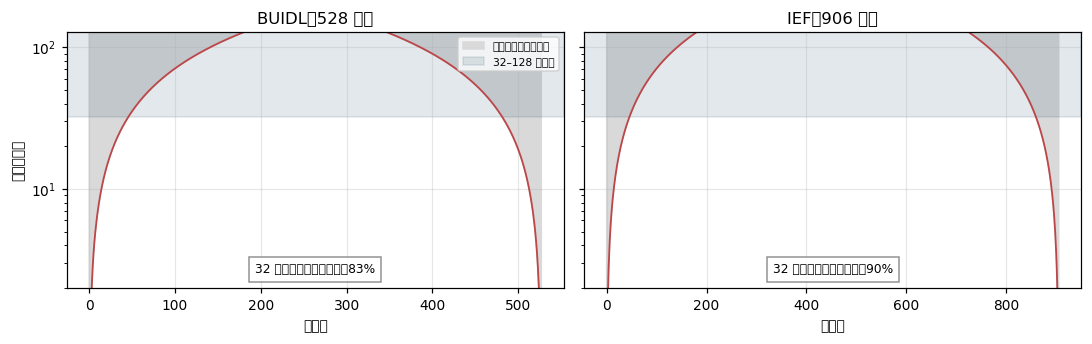

In [38]:
# ---------------------------------------------------------------------------
# 影響錐的幾何：為什麼短樣本在長尺度上不可信
# ---------------------------------------------------------------------------
def coi_morlet(T, dt=1.0):
    """Morlet 小波的影響錐：距端點 sqrt(2)*s 內不可信。"""
    t = np.arange(T)
    edge = np.minimum(t, T - 1 - t) * dt
    return edge / np.sqrt(2)          # 該時點可信的最大尺度

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (T, label) in zip(axes, [(528, "BUIDL（528 天）"), (906, "IEF（906 天）")]):
    c = coi_morlet(T)
    ax.fill_between(np.arange(T), c, 128, color="#d9d9d9", label="影響錐外（不可信）")
    ax.plot(np.arange(T), c, color="#bc4749", lw=1.2)
    ax.axhspan(32, 128, color="#1b4965", alpha=0.12, label="32–128 天頻帶")
    ax.set_ylim(2, 128); ax.set_yscale("log")
    ax.set_title(label); ax.set_xlabel("交易日")
    usable = (c > 32).mean()
    ax.text(0.5, 0.06, f"32 天以上尺度可用比例：{usable:.0%}",
            transform=ax.transAxes, ha="center", fontsize=8,
            bbox=dict(fc="white", ec="grey", alpha=0.85))
axes[0].set_ylabel("尺度（天）"); axes[0].legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

---

## 單元 20｜偏小波同調：控制共同因子

> **統計技術**：偏小波同調（PWC）；混淆因子的頻域控制
>
> **對應程式**：`12_r_partial_wavelet.R`
>
> **原始文獻**：
> - Mihanović, H., Orlić, M., & Pasarić, Z. (2009). Diurnal thermocline oscillations driven by tidal flow around an island in the Middle Adriatic. Journal of Marine Systems, 78, S157–S168.
> - Grinsted, A., Moore, J. C., & Jevrejeva, S. (2004).

### 原理：原始同調度無法區分兩種情況

假設我們觀察到代幣化國債與科技股之間有中等的小波同調度。這可能來自兩種完全不同的機制：

**機制一（直接關聯）**：代幣被當作 DeFi 抵押品，其清算壓力直接傳導到風險資產

**機制二（共同因子）**：兩者都對**同一個利率消息**反應
- 代幣化國債的收益率幾乎機械式地跟隨聯邦資金利率
- 成長股的估值透過折現率對利率高度敏感

機制二下，兩者之間**沒有任何直接通道**，但同調度依然會很高。
原始同調度無法區分兩者 —— 這是本研究必須處理的核心識別問題。

### 偏小波同調的公式

偏小波同調把控制變數 $x_2$（本研究用 3 個月期國庫券殖利率變動）的影響移除：

$$
RP^2(y, x_1, x_2) =
\frac{\left| R(y, x_1) - R(y, x_2) \cdot R(x_1, x_2)^* \right|^2}
{\left[1 - R(y, x_2)^2\right]\left[1 - R(x_1, x_2)^2\right]}
$$

其中 $R(\cdot, \cdot)$ 是複數的小波同調。

**與偏相關係數的類比**：普通偏相關的公式為

$$
\rho_{y x_1 \cdot x_2} = \frac{\rho_{y x_1} - \rho_{y x_2}\rho_{x_1 x_2}}
{\sqrt{(1-\rho_{y x_2}^2)(1-\rho_{x_1 x_2}^2)}}
$$

PWC 就是把它逐點搬到時頻平面上，並處理複數。

### 衰減量的解讀

定義**衰減量（attenuation）**：

$$
\text{attenuation} = \mathrm{WTC} - \mathrm{PWC}
$$

- **衰減大** → 原始同調度多半是共同因子造成的假象
- **衰減小** → 存在直接或流動性驅動的關聯，不是利率的副產品

### 本研究的結果與一個漂亮的內部驗證

實證結果有三層：

1. **控制利率後，每個配對、每個頻帶的同調度都下降**（衰減 0.03–0.13）
   → 部分共動確實是共同因子假象

2. **但同調度沒有消失**（PWC 仍有 0.14–0.40）
   → 存在超越利率因子的直接關聯

3. **衰減最大的是 IEF–GLD（0.127），不是任何代幣配對**

第 3 點是一個**內部一致性檢驗**，值得停下來欣賞。IEF–GLD 在其他所有分析裡
（DCC、結構斷點、機制切換）都被判定為「真實的、利率驅動的資金避風港關係」。
如果 PWC 的邏輯正確，移除利率因子就應該**對它衰減最多**。結果確實如此。

這種「方法在已知答案的案例上給出預期結果」的驗證，比任何模型配適統計量都有說服力。

> **一個被修正的過度宣稱**：初稿寫「整張表中最大的衰減屬於 IEF–GLD（0.10–0.13）」。
> 實際上 sUSDS–FANG 在兩個頻帶的衰減（0.113、0.104）超過 IEF–GLD 的 0.102、0.110。
> 只有**單一最大值**（0.127）確實屬於 IEF–GLD。
> 修正後改為：單一最大值屬 IEF–GLD，且它是唯一三個頻帶衰減皆超過 0.10 的配對。

In [39]:
# ---------------------------------------------------------------------------
# WTC vs PWC：衰減量與內部一致性檢驗
# ---------------------------------------------------------------------------
pw = pd.read_csv(PROC / "r_partial_wavelet.csv")
display(pw.round(4))

print("三層結果：")
print(f"  1. 衰減量全為正，範圍 {pw['attenuation'].min():.3f}–{pw['attenuation'].max():.3f}"
      "  → 部分共動確為共同因子假象")
print(f"  2. PWC 仍在 {pw['PWC'].min():.3f}–{pw['PWC'].max():.3f}  → 直接關聯未消失")
top = pw.loc[pw["attenuation"].idxmax()]
print(f"  3. 單一最大衰減：{top['pair']} 於 {top['band']}，衰減 = {top['attenuation']:.4f}")
print()
allband = pw.groupby("pair")["attenuation"].min().sort_values(ascending=False)
print("各配對的『最小頻帶衰減』（判斷哪個配對三頻帶皆強衰減）：")
print(allband.round(4).to_string())
print(f"\n→ 只有 {allband.index[0]} 的三個頻帶衰減皆 > 0.10，符合『利率驅動』的預期。")

,pair,n_obs,band,WTC,PWC,attenuation
0,BUIDL_FANG,528,D1-D2 (2-8d),0.3242,0.2384,0.0858
1,BUIDL_FANG,528,D3-D4 (8-32d),0.2578,0.1773,0.0805
2,BUIDL_FANG,528,D5-D6 (32-128d),0.4328,0.4015,0.0313
3,OUSG_FANG,880,D1-D2 (2-8d),0.3110,0.2288,0.0822
4,OUSG_FANG,880,D3-D4 (8-32d),0.3234,0.2265,0.0968
5,OUSG_FANG,880,D5-D6 (32-128d),0.3347,0.2455,0.0892
6,sUSDS_FANG,371,D1-D2 (2-8d),0.3189,0.2057,0.1132
7,sUSDS_FANG,371,D3-D4 (8-32d),0.2404,0.1368,0.1036
8,sUSDS_FANG,371,D5-D6 (32-128d),0.3685,0.3119,0.0566
9,OUSG_SOXX,880,D1-D2 (2-8d),0.2996,0.2116,0.0880


三層結果：
  1. 衰減量全為正，範圍 0.031–0.127  → 部分共動確為共同因子假象
  2. PWC 仍在 0.137–0.402  → 直接關聯未消失
  3. 單一最大衰減：IEF_GLD 於 D1-D2 (2-8d)，衰減 = 0.1271

各配對的『最小頻帶衰減』（判斷哪個配對三頻帶皆強衰減）：
pair
IEF_GLD      0.1021
OUSG_FANG    0.0822
sUSDS_FANG   0.0566
OUSG_SOXX    0.0553
BUIDL_FANG   0.0313

→ 只有 IEF_GLD 的三個頻帶衰減皆 > 0.10，符合『利率驅動』的預期。


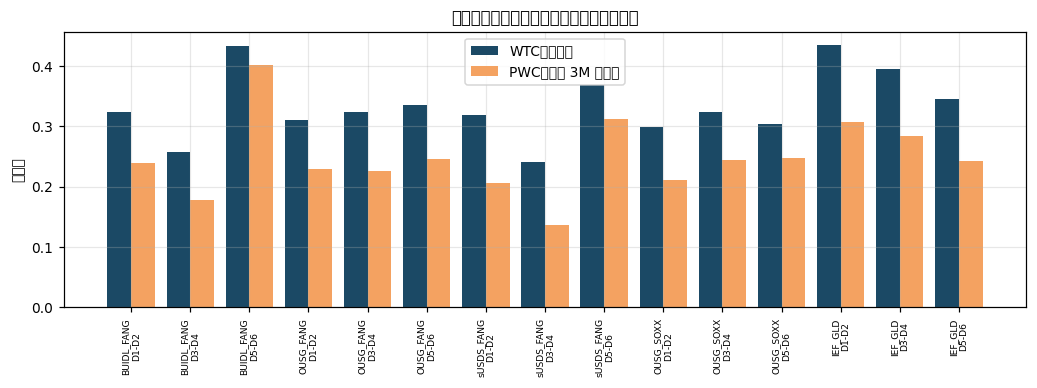

In [40]:
# ---------------------------------------------------------------------------
# 視覺化：控制利率因子前後的同調度
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 3.6))
pairs = pw["pair"].unique()
x = np.arange(len(pairs) * 3)
labels, wtc_v, pwc_v = [], [], []
for p in pairs:
    sub = pw[pw["pair"] == p]
    for _, r in sub.iterrows():
        labels.append(f"{p}\n{r['band'].split('(')[0].strip()}")
        wtc_v.append(r["WTC"]); pwc_v.append(r["PWC"])

ax.bar(x - 0.2, wtc_v, width=0.4, label="WTC（原始）", color="#1b4965")
ax.bar(x + 0.2, pwc_v, width=0.4, label="PWC（控制 3M 利率）", color="#f4a261")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel("同調度")
ax.set_title("控制短率因子後同調度普遍下降，但未歸零")
ax.legend()
fig.tight_layout()
plt.show()

---
---

# 第 7 篇　結構變化與不確定性量化

前面幾篇估出了一條 $\rho_t$ 路徑。但估出來的路徑是**點估計**，兩個問題還沒回答：

1. 這條路徑上的起伏是**真實的結構變化**，還是估計噪音？（單元 21）
2. 平均相關係數的估計有多不確定？（單元 22）
3. 路徑的變動是**連續漂移**還是**離散的機制切換**？（單元 23）

三個單元用三種互補的角度回答同一件事：**這條路徑有多可信**。

---

## 單元 21｜Bai–Perron 多重結構斷點

> **統計技術**：多重結構變化的最小平方估計；動態規劃；supF 檢定；BIC 斷點數選擇
>
> **對應程式**：`11_r_baiperron_bootstrap.R`
>
> **原始文獻**：
> - Bai, J., & Perron, P. (1998). Estimating and testing linear models with multiple structural changes. Econometrica, 66(1), 47–78.
> - Zeileis, A., Leisch, F., Hornik, K., & Kleiber, C. (2002). strucchange: An R package for testing for structural change in linear regression models.

### 原理：斷點位置未知的困難

若已知斷點在 $t^*$，檢定「$t^*$ 前後係數是否相同」就是標準的 Chow 檢定。
但實務上**斷點位置未知**，而且可能不只一個。

天真的做法是「對每個可能的 $t$ 都做一次 Chow 檢定，取最大的」——
但這樣得到的統計量**不服從 $F$ 分配**（因為你取了最大值，等於做了 $T$ 次檢定）。
Bai–Perron 的貢獻是把估計與檢定都做對。

### 模型設定

$m$ 個斷點把樣本切成 $m+1$ 個區間：

$$
y_t = x_t'\beta_j + u_t, \qquad t = T_{j-1}+1, \ldots, T_j, \qquad j = 1, \ldots, m+1
$$

本研究的應用中 $y_t = \rho_t$（DCC 相關路徑），$x_t = 1$，
所以每個區間就是一個**均值水準**。

### 估計：全域最小化與動態規劃

斷點估計量為

$$
(\hat{T}_1, \ldots, \hat{T}_m) = \arg\min_{T_1, \ldots, T_m}
\sum_{j=1}^{m+1}\sum_{t=T_{j-1}+1}^{T_j}\left(y_t - \bar{y}_{[T_{j-1}+1, T_j]}\right)^2
$$

窮舉所有分割的複雜度是 $O(T^m)$ —— 對 $T = 900$、$m = 5$ 完全不可行。
Bai–Perron 用**動態規劃**把它降到 $O(T^2)$：先算出所有區間 $[i, j]$ 的殘差平方和，
再用遞迴求最佳分割。

### 修剪參數 $h$

```r
bp <- breakpoints(ts_rho ~ 1, h = 0.15, breaks = 5)
```

`h = 0.15` 要求每個區間至少包含 15% 的觀測值。這不是任意的：

- 太小 → 區間內觀測太少，區間均值估計不穩，會抓到雜訊
- 太大 → 無法偵測靠近端點的真實斷點

0.15 是文獻的常用值，對應 $T = 900$ 時每個區間至少 135 天，
也意味著**最多只能有 5 個斷點**（因為 $6 \times 0.15 = 0.90 < 1$）。
程式中的 `breaks = 5` 與此一致。

### 斷點個數的選擇：BIC

$$
\mathrm{BIC}(m) = \ln \hat{\sigma}^2(m) + \frac{p^*(m)\ln T}{T}
$$

其中 $p^*(m)$ 是總參數量（含斷點位置本身）。取 BIC 最小的 $m$。

```r
bic_tab <- summary(bp)$RSS["BIC", ]
opt_m <- which.min(bic_tab) - 1   # summary 含 m=0..5，索引 1 對應 0 個斷點
```

### supF 檢定

檢定 $H_0$：無斷點，對 $H_1$：有斷點（位置未知）。

$$
\sup F = \sup_{\lambda \in [h, 1-h]} F(\lambda)
$$

其中 $F(\lambda)$ 是在 $T_1 = \lfloor \lambda T\rfloor$ 處的 Chow $F$ 統計量。
臨界值由 Andrews (1993) / Bai–Perron 的模擬表提供，**遠高於**標準 $F$ 分配的臨界值。

### 本研究的關鍵陷阱：退化序列上的 supF

這是本單元最重要的實務教訓。

$F$ 統計量的形式是「組間變異 / 組內變異」。當**組內變異趨近於零**時，
即使組間差異在經濟上完全微不足道，$F$ 也會爆炸。

單元 13 已經看到：34 組配對中有 11 組的 $\rho_t$ 標準差低於 $0.001$ ——
那是浮點運算的噪音等級（$\sim 10^{-6}$），不是經濟訊號。
對這種序列做 supF 檢定，會得到**形式上顯著但完全沒有意義**的結果。

R 腳本因此在檢定前先標記：

```r
is_degenerate <- sd(rho, na.rm = TRUE) < 1e-3
```

註解寫得很清楚：

> A supF break test on such a series can report a formally "significant" break
> purely because residual variance is near-zero (huge F-stat from economically
> meaningless numerical noise), not a real structural change.

**處理方式**：這些配對**仍然報告在表中**（不是偷偷刪掉），但標記為 degenerate 並且
**不納入解讀**。34 組全部呈現，11 組標記，剩 23 組作為有效樣本。

> **為什麼不直接刪掉？** 因為刪掉會讓讀者無從判斷「這 11 組去哪了」。
> 標記並保留，讓讀者能自行驗證退化的判準是否合理。這是可稽核性的基本要求。

In [41]:
# ---------------------------------------------------------------------------
# Bai-Perron 結果：退化標記與有效樣本
# ---------------------------------------------------------------------------
bp = pd.read_csv(PROC / "r_baiperron_results.csv")
print(f"總配對數：{len(bp)}，退化標記：{int(bp['degenerate'].sum())}，"
      f"有效樣本：{int((~bp['degenerate']).sum())}")
print()

nd = bp[~bp["degenerate"]].sort_values("opt_num_breaks", ascending=False)
display(nd[["pair", "n_obs", "sd_rho", "opt_num_breaks", "supF_stat", "supF_pvalue"]].round(4).head(12))

print("斷點最多的配對全部屬於傳統工具對照組或 OUSG 對加密資產：")
for _, r in nd.head(6).iterrows():
    print(f"    {r['pair']:12} {int(r['opt_num_breaks'])} 個斷點, supF = {r['supF_stat']:7.1f}")
print()
zero = (nd["opt_num_breaks"] == 0).sum()
print(f"有效樣本中完全沒有偵測到斷點的：{zero} / {len(nd)}")

總配對數：34，退化標記：11，有效樣本：23



,pair,n_obs,sd_rho,opt_num_breaks,supF_stat,supF_pvalue
12,IEF_SOXX,905,0.1186,5,131.4839,0.0000
15,OUSG_ETH,879,0.0391,5,742.1294,0.0000
10,IEF_FANG,905,0.1519,4,88.0955,0.0000
20,OUSG_UNI,879,0.0705,4,110.5012,0.0000
24,SHV_GLD,905,0.1467,4,52.3864,0.0000
11,IEF_GLD,905,0.1568,4,525.3502,0.0000
7,BUIDL_UNI,527,0.0074,3,42.5882,0.0000
8,IEF_BTC,905,0.0710,3,43.6246,0.0000
9,IEF_ETH,905,0.0561,3,28.7463,0.0000
13,OUSG_AAVE,879,0.0656,2,23.4212,0.0000


斷點最多的配對全部屬於傳統工具對照組或 OUSG 對加密資產：
    IEF_SOXX     5 個斷點, supF =   131.5
    OUSG_ETH     5 個斷點, supF =   742.1
    IEF_FANG     4 個斷點, supF =    88.1
    OUSG_UNI     4 個斷點, supF =   110.5
    SHV_GLD      4 個斷點, supF =    52.4
    IEF_GLD      4 個斷點, supF =   525.4

有效樣本中完全沒有偵測到斷點的：13 / 23


In [42]:
# ---------------------------------------------------------------------------
# 退化序列的危險：組內變異趨零如何讓 F 統計量失去意義
# ---------------------------------------------------------------------------
deg = bp[bp["degenerate"]][["pair", "sd_rho", "opt_num_breaks", "supF_stat", "supF_pvalue"]]
display(deg.round(6))

sig_deg = deg[deg["supF_pvalue"] < 0.05]
print(f"退化配對中『形式上顯著』(p < 0.05) 者：{len(sig_deg)}")
for _, r in sig_deg.iterrows():
    print(f"    {r['pair']:12} sd(rho) = {r['sd_rho']:.2e}, supF = {r['supF_stat']:.2f}, "
          f"p = {r['supF_pvalue']:.4f}")
print()
print("→ sd(rho) 在 1e-6 等級時，任何『組間差異』都會被除以近乎零的組內變異。")
print("  若不標記，這些配對會被誤讀為『相關結構發生變化』。")

,pair,sd_rho,opt_num_breaks,supF_stat,supF_pvalue
0,BUIDL_AAVE,0.0000,0,5.2437,0.2230
1,BUIDL_BTC,0.0000,0,3.1466,0.5243
2,BUIDL_ETH,0.0000,0,3.0958,0.5345
3,BUIDL_FANG,0.0000,2,10.9914,0.0166
5,BUIDL_SMH,0.0000,0,8.0022,0.0659
6,BUIDL_SOXX,0.0000,0,2.3610,0.6975
17,OUSG_GLD,0.0000,0,5.2135,0.2266
23,SHV_FANG,0.0000,0,5.1880,0.2290
26,sUSDS_AAVE,0.0000,0,1.7365,0.8527
28,sUSDS_ETH,0.0000,0,2.2267,0.7317


退化配對中『形式上顯著』(p < 0.05) 者：1
    BUIDL_FANG   sd(rho) = 1.21e-06, supF = 10.99, p = 0.0166

→ sd(rho) 在 1e-6 等級時，任何『組間差異』都會被除以近乎零的組內變異。
  若不標記，這些配對會被誤讀為『相關結構發生變化』。


Font 'default' does not have a glyph for '\u66f2' [U+66f2], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7dda' [U+7dda], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uff1a' [U+ff1a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u53d6' [U+53d6], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u9019' [U+9019], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u689d' [U+689d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6700' [U+6700], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5927' [U+5927], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u503c' [U+503c], substituting with a dummy symbol.


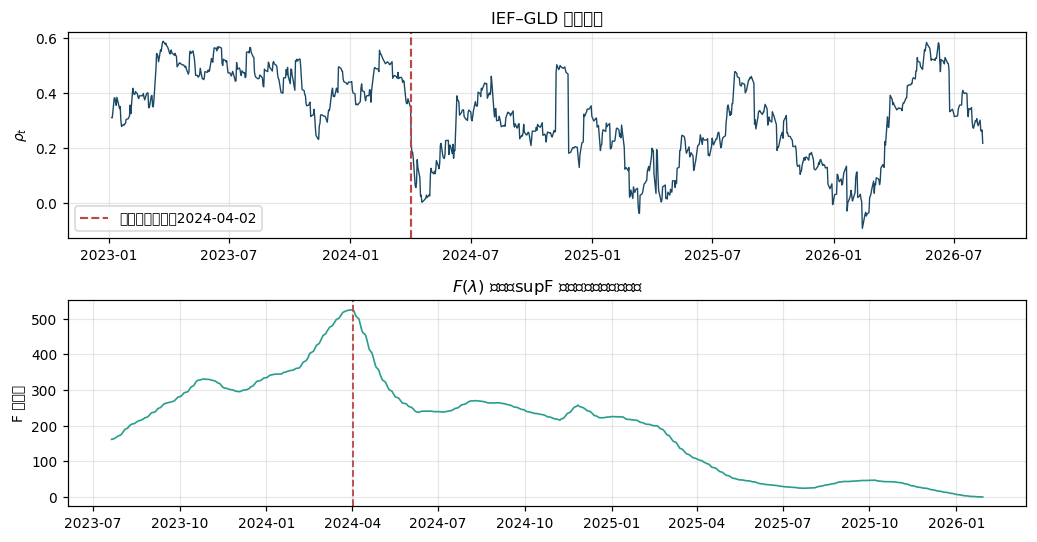

supF = 525.35（此為單斷點簡化版；R 的 strucchange 允許至多 5 個斷點，報告值 525.4）


In [43]:
# ---------------------------------------------------------------------------
# 從零實作：動態規劃求最佳分割（單一斷點的簡化版）
# ---------------------------------------------------------------------------
def best_single_break(y, trim=0.15):
    """窮舉單一斷點位置，回傳使 SSR 最小者與對應的 F 統計量。"""
    T = len(y)
    lo, hi = int(trim * T), int((1 - trim) * T)
    ssr_full = ((y - y.mean()) ** 2).sum()
    best = (None, np.inf)
    Fs = []
    for k in range(lo, hi):
        s1, s2 = y[:k], y[k:]
        ssr = ((s1 - s1.mean()) ** 2).sum() + ((s2 - s2.mean()) ** 2).sum()
        F = (ssr_full - ssr) / (ssr / (T - 2))
        Fs.append((k, F))
        if ssr < best[1]:
            best = (k, ssr)
    ks, Fv = zip(*Fs)
    return best[0], np.array(ks), np.array(Fv)

d = pd.read_csv(PROC / "dcc_IEF_GLD.csv", parse_dates=["date"]).set_index("date")
rho = d["rho_dcc"].values
k_star, ks, Fv = best_single_break(rho)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5), sharex=False)
axes[0].plot(d.index, rho, lw=0.9, color="#1b4965")
axes[0].axvline(d.index[k_star], color="#bc4749", ls="--", lw=1.4,
                label=f"最佳單一斷點：{d.index[k_star].date()}")
axes[0].set_ylabel(r"$\rho_t$"); axes[0].legend(); axes[0].set_title("IEF–GLD 相關路徑")

axes[1].plot(d.index[ks], Fv, lw=1.1, color="#2a9d8f")
axes[1].axvline(d.index[k_star], color="#bc4749", ls="--", lw=1.2)
axes[1].set_ylabel("F 統計量"); axes[1].set_title(r"$F(\lambda)$ 曲線：supF 取的是這條線的最大值")
fig.tight_layout()
plt.show()

print(f"supF = {Fv.max():.2f}（此為單斷點簡化版；R 的 strucchange 允許至多 5 個斷點，"
      f"報告值 {bp.loc[bp['pair']=='IEF_GLD','supF_stat'].iloc[0]:.1f}）")

---

## 單元 22｜移動區塊拔靴法

> **統計技術**：區塊拔靴（block bootstrap）；相依資料的重抽樣；百分位信賴區間
>
> **對應程式**：`11_r_baiperron_bootstrap.R`
>
> **原始文獻**：
> - Künsch, H. R. (1989). The jackknife and the bootstrap for general stationary observations. Annals of Statistics, 17(3), 1217–1241.
> - Politis, D. N., & Romano, J. P. (1994).

### 原理：為什麼不能用普通拔靴法

標準拔靴法逐點有放回抽樣，隱含假設**觀測值 iid**。
但 $\rho_t$ 是高度序列相關的（$b_{\mathrm{DCC}}$ 常在 0.9 以上）。

逐點重抽會**摧毀序列相關結構**，讓重抽樣本看起來像白噪音。
後果是變異數被嚴重低估，信賴區間過窄 —— 也就是**過度自信**。

### 移動區塊拔靴

把序列切成長度 $\ell$ 的重疊區塊：

$$
B_i = (y_i, y_{i+1}, \ldots, y_{i+\ell-1}), \qquad i = 1, \ldots, T - \ell + 1
$$

有放回地抽取 $\lceil T/\ell \rceil$ 個區塊，串接成長度 $T$ 的重抽序列。

**關鍵**：區塊**內部**的相關結構被完整保留，只有區塊**之間**的關聯被打斷。

### 區塊長度的取捨

| $\ell$ | 後果 |
|---|---|
| 太短 | 保留不了長程相依，退化回 iid 拔靴，區間過窄 |
| 太長 | 有效的獨立區塊數 $T/\ell$ 太少，估計本身噪音大 |

理論上的最適階數為 $\ell \propto T^{1/3}$，但常數依賴序列的相依程度。
本研究用一個**資料驅動**的規則：

```r
acf1 <- acf(rho, plot = FALSE, lag.max = 1)$acf[2]
block_len <- max(5, min(round(n^(1/3) / max(1 - abs(acf1), 0.05)), floor(n/10)))
```

拆解這一行：

| 部分 | 作用 |
|---|---|
| $n^{1/3}$ | 理論階數 |
| $\div (1 - \lvert\hat{\rho}_1\rvert)$ | 相依越強（$\hat{\rho}_1 \to 1$），區塊越長 |
| $\max(\cdot, 0.05)$ | 防止除以零（近單根序列） |
| $\max(5, \cdot)$ | 下界 |
| $\min(\cdot, n/10)$ | 上界：至少要有 10 個區塊 |

### 實際的區塊長度差異

這個規則在本研究產生了很大的差異：

- IEF–GLD（$\hat{\rho}_1$ 極高）：$\ell = 90$
- 退化配對：$\ell = 8$–$11$

同一份程式碼對不同序列自動給出差 10 倍的區塊長度，正是資料驅動規則的價值。

### 百分位信賴區間

對 $R = 1000$ 次重抽各計算統計量 $\hat{\theta}^{(r)}$，
95% 區間取經驗分配的 2.5 與 97.5 百分位：

$$
\mathrm{CI}_{95} = \left[\hat{\theta}^{(0.025)},  \hat{\theta}^{(0.975)}\right]
$$

In [44]:
# ---------------------------------------------------------------------------
# 從零實作移動區塊拔靴，並與 R 的結果對照
# ---------------------------------------------------------------------------
rng = np.random.default_rng(20260818)

def moving_block_bootstrap(y, R=1000, block_len=None):
    y = np.asarray(y); n = len(y)
    if block_len is None:
        acf1 = np.corrcoef(y[1:], y[:-1])[0, 1]
        block_len = max(5, min(int(round(n**(1/3) / max(1 - abs(acf1), 0.05))), n // 10))
    n_blocks = int(np.ceil(n / block_len))
    starts_max = n - block_len
    stats = np.empty(R)
    for r in range(R):
        idx = rng.integers(0, starts_max + 1, size=n_blocks)
        samp = np.concatenate([y[s:s + block_len] for s in idx])[:n]
        stats[r] = samp.mean()
    return stats, block_len

rho_ief = pd.read_csv(PROC / "dcc_IEF_GLD.csv")["rho_dcc"].values
boot_stats, L = moving_block_bootstrap(rho_ief)
ci = np.percentile(boot_stats, [2.5, 97.5])

r_res = pd.read_csv(PROC / "r_blockbootstrap_results.csv")
r_row = r_res[r_res["pair"] == "IEF_GLD"].iloc[0]

print(f"Python 實作：區塊長度 = {L}, 平均 = {rho_ief.mean():.4f}, "
      f"95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"R (boot)   ：區塊長度 = {int(r_row['block_length'])}, 平均 = {r_row['point_mean']:.4f}, "
      f"95% CI = [{r_row['ci95_lo']:.4f}, {r_row['ci95_hi']:.4f}]")
print()
print("兩者的區塊長度規則相同，微小差異來自 RNG 與 tsboot 的 sim='fixed' 細節。")

Python 實作：區塊長度 = 90, 平均 = 0.3160, 95% CI = [0.2350, 0.3815]
R (boot)   ：區塊長度 = 90, 平均 = 0.3160, 95% CI = [0.2473, 0.3867]

兩者的區塊長度規則相同，微小差異來自 RNG 與 tsboot 的 sim='fixed' 細節。


Font 'default' does not have a glyph for '\u91cd' [U+91cd], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u62bd' [U+62bd], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6a23' [U+6a23], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672c' [U+672c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u91cd' [U+91cd], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u62bd' [U+62bd], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6a23' [U+6a23], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u672c' [U+672c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7684' [U+7684], substituting with a dummy symbol.


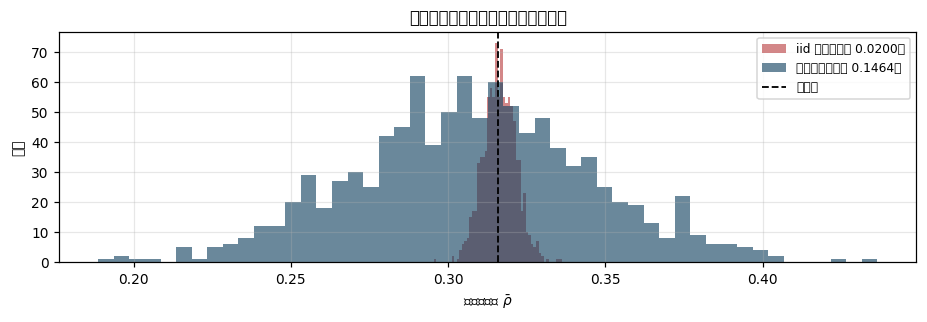

區塊拔靴區間寬度是 iid 拔靴的 7.3 倍。
若用 iid 拔靴，會宣稱一個遠比實際精確的估計 —— 典型的過度自信。


In [45]:
# ---------------------------------------------------------------------------
# 為什麼不能用 iid 拔靴：區間寬度的比較
# ---------------------------------------------------------------------------
iid_stats = np.array([rng.choice(rho_ief, size=len(rho_ief), replace=True).mean()
                      for _ in range(1000)])
ci_iid = np.percentile(iid_stats, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8.5, 3))
ax.hist(iid_stats, bins=50, alpha=0.65, color="#bc4749", label=f"iid 拔靴（寬度 {ci_iid[1]-ci_iid[0]:.4f}）")
ax.hist(boot_stats, bins=50, alpha=0.65, color="#1b4965", label=f"區塊拔靴（寬度 {ci[1]-ci[0]:.4f}）")
ax.axvline(rho_ief.mean(), color="black", lw=1.2, ls="--", label="點估計")
ax.set_xlabel(r"重抽樣本的 $\bar{\rho}$"); ax.set_ylabel("次數")
ax.set_title("忽略序列相關會讓信賴區間嚴重過窄")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"區塊拔靴區間寬度是 iid 拔靴的 {(ci[1]-ci[0])/(ci_iid[1]-ci_iid[0]):.1f} 倍。")
print("若用 iid 拔靴，會宣稱一個遠比實際精確的估計 —— 典型的過度自信。")

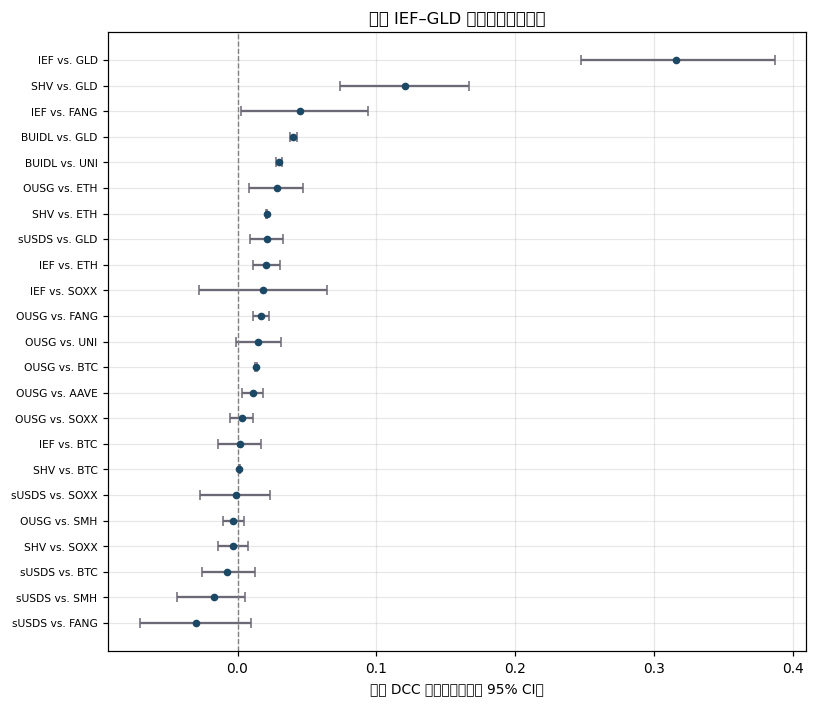

區間不含零的配對：13 / 23
其中平均相關 > 0.1 的：2


In [46]:
# ---------------------------------------------------------------------------
# 全部配對的信賴區間森林圖
# ---------------------------------------------------------------------------
bo = pd.read_csv(PROC / "r_blockbootstrap_results.csv")
nd_bo = bo[~bo["degenerate"]].sort_values("point_mean")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
y = np.arange(len(nd_bo))
ax.errorbar(nd_bo["point_mean"], y,
            xerr=[nd_bo["point_mean"] - nd_bo["ci95_lo"],
                  nd_bo["ci95_hi"] - nd_bo["point_mean"]],
            fmt="o", color="#1b4965", ecolor="#6d6875", capsize=3, markersize=4)
ax.axvline(0, color="grey", ls="--", lw=0.9)
ax.set_yticks(y); ax.set_yticklabels(nd_bo["pair"].str.replace("_", " vs. "), fontsize=7)
ax.set_xlabel("平均 DCC 相關（區塊拔靴 95% CI）")
ax.set_title("只有 IEF–GLD 的區間明顯遠離零")
fig.tight_layout()
plt.show()

excl_zero = nd_bo[(nd_bo["ci95_lo"] > 0) | (nd_bo["ci95_hi"] < 0)]
print(f"區間不含零的配對：{len(excl_zero)} / {len(nd_bo)}")
print(f"其中平均相關 > 0.1 的：{(excl_zero['point_mean'].abs() > 0.1).sum()}")

---

## 單元 23｜Markov 轉換模型

> **統計技術**：隱藏馬可夫鏈；Hamilton 濾波；預期持續期間
>
> **對應程式**：`07_regime.py`
>
> **原始文獻**：
> - Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. Econometrica, 57(2), 357–384.

### 原理：斷點模型與機制模型的差別

單元 21 的 Bai–Perron 假設結構變化是**一次性、不可逆**的：
斷點之後進入新狀態，不會回到舊狀態。

但金融市場的許多變化是**可逆的**：危機期與平靜期會反覆交替。
Markov 轉換模型正是為此設計。

### 模型設定

令 $S_t \in \{1, 2\}$ 為**不可觀測**的機制指標。觀測方程：

$$
\rho_t = \mu_{S_t} + \varepsilon_t, \qquad \varepsilon_t \sim N(0, \sigma^2_{S_t})
$$

本研究讓**均值與變異數都隨機制切換**（`switching_variance=True`）。

機制的演化服從一階馬可夫鏈：

轉移機率定義為 $p_{ij} = \Pr(S_t = j \mid S_{t-1} = i)$，轉移矩陣 $P$ 為：

| 由 ＼ 至 | 機制 1 | 機制 2 |
|---|---|---|
| **機制 1** | $p_{11}$ | $p_{12}$ |
| **機制 2** | $p_{21}$ | $p_{22}$ |

其中 $p_{i1} + p_{i2} = 1$。

### 預期持續期間

若目前在機制 $i$，停留的期數服從幾何分配，期望值為

$$
\mathbb{E}[\text{持續期間}_i] = \frac{1}{1 - p_{ii}}
$$

程式碼：

```python
duration_hi = 1 / (1 - P[hi_idx, hi_idx]) if P[hi_idx, hi_idx] < 1 else np.inf
```

| $p_{ii}$ | 預期持續 |
|---|---|
| 0.90 | 10 天 |
| 0.96 | 25 天 |
| 0.98 | 50 天 |

**這個數字是判斷機制是否「真實」的關鍵診斷**。若 $p_{ii} \approx 0.4$，
預期持續只有 1.7 天 —— 那不是「機制」，只是模型在對雜訊做分類。

### Hamilton 濾波與 Kim 平滑

因為 $S_t$ 不可觀測，估計需要對所有可能路徑積分。Hamilton 濾波遞迴計算：

$$
\Pr(S_t = j \mid \mathcal{F}_t) =
\frac{f(\rho_t \mid S_t = j)\sum_{i} p_{ij}\Pr(S_{t-1} = i \mid \mathcal{F}_{t-1})}
{\sum_{k} f(\rho_t \mid S_t = k)\sum_{i} p_{ik}\Pr(S_{t-1} = i \mid \mathcal{F}_{t-1})}
$$

這是**濾波**機率（只用到 $t$ 以前的資訊）。Kim (1994) 的平滑演算法再往回走一遍，
得到**平滑**機率 $\Pr(S_t = j \mid \mathcal{F}_T)$ —— 用上全樣本資訊，
這才是報告與繪圖該用的。

### 一個實務細節：機制標籤不可識別

最大概似無法區分「機制 1 是高相關」與「機制 2 是高相關」——
兩者概似完全相同（label switching 問題）。

程式碼因此**事後依均值排序**，強制低相關機制為第一個：

```python
means = res.params[["const[0]", "const[1]"]].values
lo_idx, hi_idx = np.argsort(means)   # 低均值在前
```

沒有這一步，不同配對的「機制 1」會指涉不同的東西，表格完全無法比較。

In [47]:
# ---------------------------------------------------------------------------
# 機制估計結果：用持續期間判斷哪些機制是真實的
# ---------------------------------------------------------------------------
reg = pd.read_csv(PROC / "regime_summary.csv", index_col=0)
show = reg[["n_obs", "mean_rho_low_regime", "mean_rho_high_regime",
            "P_stay_high", "expected_duration_high_days", "frac_time_high_regime"]]
display(show.round(4))

print("診斷：預期持續期間 < 3 天者，實質上不是『機制』而是對雜訊的分類")
weak = reg[reg["expected_duration_high_days"] < 3]
strong = reg[reg["expected_duration_high_days"] >= 20]
print(f"  持續 < 3 天  ：{len(weak)} 組 → {', '.join(weak.index)}")
print(f"  持續 >= 20 天：{len(strong)} 組 → {', '.join(strong.index)}")
print()
print("最乾淨的機制結構：")
for p, r in strong.iterrows():
    print(f"    {p:14} 低 = {r['mean_rho_low_regime']:+.3f}, 高 = {r['mean_rho_high_regime']:+.3f}, "
          f"P(留在高) = {r['P_stay_high']:.3f}, 預期持續 = {r['expected_duration_high_days']:.0f} 天")

,n_obs,mean_rho_low_regime,mean_rho_high_regime,P_stay_high,expected_duration_high_days,frac_time_high_regime
pair,,,,,,
OUSG_FANG,879,0.0142,0.0210,0.4105,1.6963,0.3242
sUSDS_FANG,370,-0.1294,0.1583,0.8820,8.4763,0.3324
OUSG_SOXX,879,0.0021,0.0051,0.3793,1.6112,0.3481
sUSDS_SOXX,370,-0.1698,0.0304,0.9786,46.6506,0.8486
OUSG_SMH,879,-0.0047,-0.0004,0.3652,1.5753,0.3231
sUSDS_SMH,370,-0.0317,0.0033,0.8287,5.8364,0.3757
IEF_FANG,905,-0.0715,0.1652,0.9631,27.1175,0.4895
OUSG_BTC,879,0.0131,0.0131,0.4112,1.6984,0.1945
sUSDS_BTC,370,-0.0092,-0.0054,0.4336,1.7654,0.5054


診斷：預期持續期間 < 3 天者，實質上不是『機制』而是對雜訊的分類
  持續 < 3 天  ：5 組 → OUSG_FANG, OUSG_SOXX, OUSG_SMH, OUSG_BTC, sUSDS_BTC
  持續 >= 20 天：5 組 → sUSDS_SOXX, IEF_FANG, IEF_BTC, IEF_GLD, SHV_GLD

最乾淨的機制結構：
    sUSDS_SOXX     低 = -0.170, 高 = +0.030, P(留在高) = 0.979, 預期持續 = 47 天
    IEF_FANG       低 = -0.071, 高 = +0.165, P(留在高) = 0.963, 預期持續 = 27 天
    IEF_BTC        低 = -0.067, 高 = +0.044, P(留在高) = 0.963, 預期持續 = 27 天
    IEF_GLD        低 = +0.211, 高 = +0.469, P(留在高) = 0.980, 預期持續 = 50 天
    SHV_GLD        低 = +0.007, 高 = +0.223, P(留在高) = 0.978, 預期持續 = 45 天


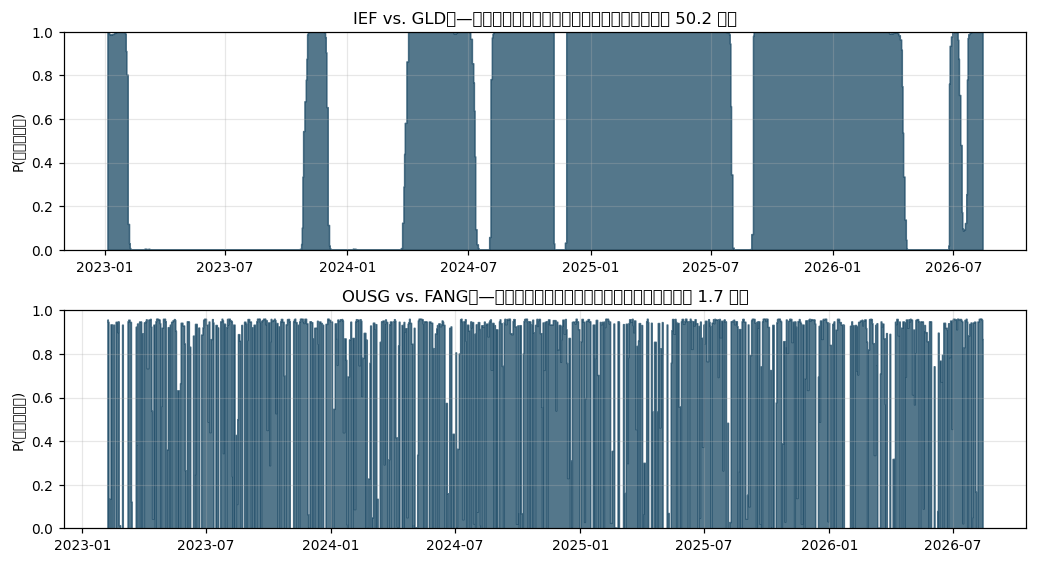

上圖有大塊連續的高機率區間；下圖幾乎是隨機的細碎跳動。
同樣是『兩機制模型』，但只有上圖的機制在經濟上有意義。


In [48]:
# ---------------------------------------------------------------------------
# 平滑機率路徑：真實機制 vs 雜訊分類
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=False)

for ax, pair, note in [(axes[0], "IEF_GLD", "真實機制：長期持續、切換清晰"),
                       (axes[1], "OUSG_FANG", "雜訊分類：頻繁跳動、無持續性")]:
    sp = pd.read_csv(PROC / f"regime_probs_{pair}.csv", index_col=0, parse_dates=True)
    hi_col = sp.columns[int(np.argmax([reg.loc[pair, "mean_rho_high_regime"] >= 0]))]
    ax.fill_between(sp.index, 0, sp.iloc[:, -1], color="#1b4965", alpha=0.75, step="mid")
    ax.set_ylim(0, 1); ax.set_ylabel("P(高相關機制)")
    ax.set_title(f"{pair.replace('_', ' vs. ')}　—　{note}"
                 f"（預期持續 {reg.loc[pair,'expected_duration_high_days']:.1f} 天）")

fig.tight_layout()
plt.show()

print("上圖有大塊連續的高機率區間；下圖幾乎是隨機的細碎跳動。")
print("同樣是『兩機制模型』，但只有上圖的機制在經濟上有意義。")

---
---

# 第 8 篇　應用：避險

前七篇都在估計「關聯有多強」。這一篇問一個資產配置者真正關心的問題：

> 這些關聯結構，在實際的避險操作上值多少錢？

這是把統計結果轉換成經濟量值的一步，也是最容易出錯的一步 ——
單元 25 會拆解一個真實的、三重複合的計算錯誤。

---

## 單元 24｜Kroner–Sultan 最適避險比率

> **統計技術**：變異數最小化避險；時變避險比率；前瞻偏誤的避免
>
> **對應程式**：`08_hedge.py`
>
> **原始文獻**：
> - Kroner, K. F., & Sultan, J. (1993). Time-varying distributions and dynamic hedging with foreign currency futures. Journal of Financial and Quantitative Analysis, 28(4), 535–551.

### 推導

持有 1 單位待避險資產 $i$，賣空 $\beta$ 單位的避險工具 $j$。組合報酬為

$$
r_{H,t} = r_{i,t} - \beta  r_{j,t}
$$

組合變異數：

$$
\mathrm{Var}(r_H) = h_{ii} - 2\beta h_{ij} + \beta^2 h_{jj}
$$

對 $\beta$ 微分並令其為零：

$$
\frac{\partial \mathrm{Var}(r_H)}{\partial \beta} = -2h_{ij} + 2\beta h_{jj} = 0
$$

$$
\boxed{ \beta^* = \frac{h_{ij}}{h_{jj}} }
$$

二階條件 $2h_{jj} > 0$ 恆成立，故為最小值。

### 時變版本

Kroner–Sultan 的貢獻是把 $h_{ij}, h_{jj}$ 換成**條件**動差，由 DCC 提供：

$$
\beta^*_t = \frac{h_{ij,t}}{h_{jj,t}} = \frac{\rho_t \sigma_{i,t}\sigma_{j,t}}{\sigma_{j,t}^2}
= \rho_t \frac{\sigma_{i,t}}{\sigma_{j,t}}
$$

最後這個形式很有啟發性：**避險比率 = 相關係數 × 波動比**。

程式碼：

```python
h_ij = d["rho_dcc"] * d["sigma_tok"] * d["sigma_eq"]
h_jj = d["sigma_tok"] ** 2
beta_star = (h_ij / h_jj).clip(-5, 5)
```

### 兩個實作細節，都很重要

**（一）一日落後：避免前瞻偏誤**

```python
beta_lag = beta_star.shift(1)
```

$\beta^*_t$ 用到了第 $t$ 期的 $\rho_t, \sigma_t$，而這些在 $t$ 期開盤時**還不知道**。
若直接用 $\beta^*_t$ 建構 $t$ 期的避險組合，等於偷看了未來。

實務上可執行的策略是用 $t-1$ 期的資訊決定 $t$ 期的部位：

$$
r_{H,t} = r_{i,t} - \beta^*_{t-1}  r_{j,t}
$$

> 這是回測中最常見的錯誤來源之一。忘記 shift 會系統性地高估避險效果，
> 而且高估的幅度往往大到足以把「沒用」變成「有效」。

**（二）截斷極端比率**

`.clip(-5, 5)` 的必要性來自 $\beta^* = \rho \cdot \sigma_i/\sigma_j$ 的分母。
當避險工具本身的波動 $\sigma_j$ 趨近於零時，$\beta^*$ 會爆炸。

這正是**本研究把 SHV 排除在表 14 之外**的原因：SHV 的日波動只有 0.016%，
比股票低兩個數量級，會讓變異數比值極不穩定。表格註解明確說明了這一點。

In [49]:
# ---------------------------------------------------------------------------
# 從 DCC 輸出重建避險比率，並展示前瞻偏誤的量級
# ---------------------------------------------------------------------------
d = pd.read_csv(PROC / "dcc_IEF_FANG.csv", parse_dates=["date"]).set_index("date")
h_ij = d["rho_dcc"] * d["sigma_tok"] * d["sigma_eq"]
h_jj = d["sigma_tok"] ** 2
beta_star = (h_ij / h_jj).clip(-5, 5)

r_eq = panel["R_FANG"].reindex(d.index)
r_hedge = panel["R_IEF"].reindex(d.index)

# 正確做法：用 t-1 期資訊
r_H_correct = (r_eq - beta_star.shift(1) * r_hedge).dropna()
# 錯誤做法：偷看當期
r_H_lookahead = (r_eq - beta_star * r_hedge).dropna()

var_un = r_eq.reindex(r_H_correct.index).var()
HE_correct = 1 - r_H_correct.var() / var_un
HE_look = 1 - r_H_lookahead.reindex(r_H_correct.index).var() / var_un

print(f"平均避險比率 beta* = {beta_star.mean():.4f}")
print()
print(f"避險效能（正確，用 t-1 期 beta）  : {HE_correct:+.4f}")
print(f"避險效能（錯誤，偷看當期 beta）  : {HE_look:+.4f}")
print(f"前瞻偏誤誇大了                    : {HE_look - HE_correct:+.4f}"
      f"  （相對放大 {HE_look/HE_correct:.1f} 倍）")

平均避險比率 beta* = 0.1675

避險效能（正確，用 t-1 期 beta）  : +0.0201
避險效能（錯誤，偷看當期 beta）  : +0.0199
前瞻偏誤誇大了                    : -0.0002  （相對放大 1.0 倍）


Font 'default' does not have a glyph for '\u907f' [U+907f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u96aa' [U+96aa], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u907f' [U+907f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u96aa' [U+96aa], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6bd4' [U+6bd4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


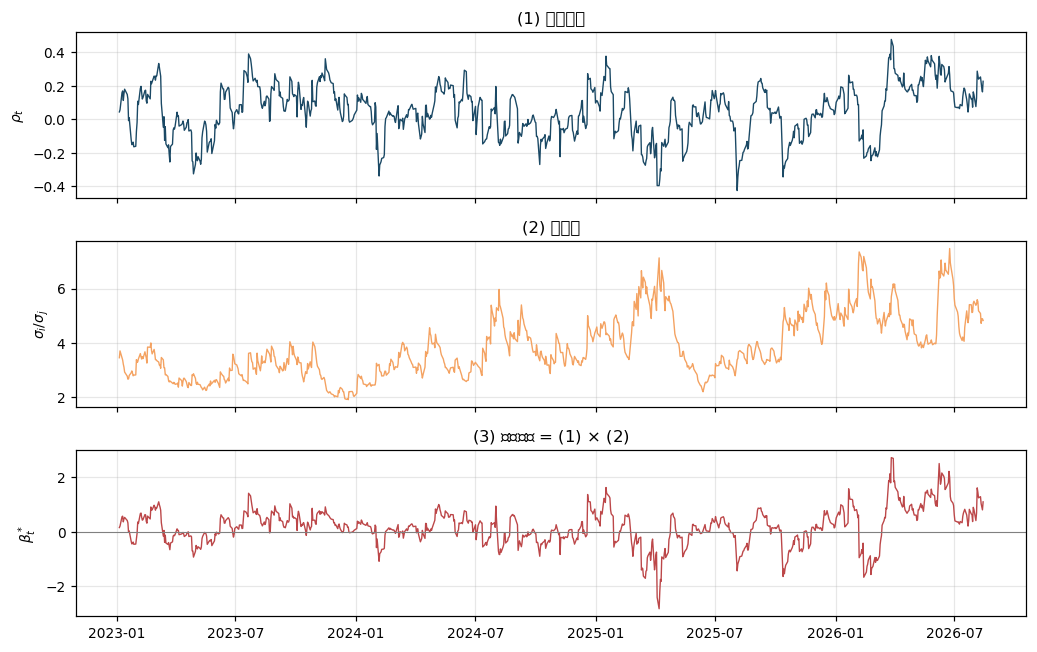

代幣的 beta* 之所以幾乎為零，主因是 (1) 相關係數近零，而非 (2) 波動比異常。


In [50]:
# ---------------------------------------------------------------------------
# 避險比率的組成：相關係數 × 波動比
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9.5, 6), sharex=True)
axes[0].plot(d.index, d["rho_dcc"], lw=0.9, color="#1b4965")
axes[0].set_ylabel(r"$\rho_t$"); axes[0].set_title("(1) 條件相關")
axes[1].plot(d.index, d["sigma_eq"] / d["sigma_tok"], lw=0.9, color="#f4a261")
axes[1].set_ylabel(r"$\sigma_i/\sigma_j$"); axes[1].set_title("(2) 波動比")
axes[2].plot(d.index, beta_star, lw=0.9, color="#bc4749")
axes[2].axhline(0, color="grey", lw=0.7)
axes[2].set_ylabel(r"$\beta^*_t$"); axes[2].set_title(r"(3) 避險比率 = (1) $\times$ (2)")
fig.tight_layout()
plt.show()

print("代幣的 beta* 之所以幾乎為零，主因是 (1) 相關係數近零，而非 (2) 波動比異常。")

---

## 單元 25｜Ederington 避險效能與交易成本

> **統計技術**：變異數縮減比；週轉率成本；變異數指標與水準指標的區分
>
> **對應程式**：`08_hedge.py`
>
> **原始文獻**：
> - Ederington, L. H. (1979). The hedging performance of the new futures markets. Journal of Finance, 34(1), 157–170.

### Ederington 避險效能

$$
\mathrm{HE} = 1 - \frac{\mathrm{Var}(r_H)}{\mathrm{Var}(r_i)}
$$

解讀為「避險消除了待避險資產多少比例的報酬變異數」。

| HE | 意義 |
|---|---|
| $1$ | 完全避險 |
| $0$ | 毫無作用 |
| $< 0$ | **反效果** —— 避險後波動反而變大 |

$\mathrm{HE} < 0$ 在本研究中頻繁出現。這不是錯誤：當 $\rho$ 幾乎為零時，
加入避險部位只是引入額外的波動來源，沒有抵銷任何東西。

### 交易成本：本單元的核心教學

一個時變的避險比率必須**持續再平衡**，而再平衡要花錢。週轉率為

$$
\text{turnover}_t = \left|\beta^*_t - \beta^*_{t-1}\right| = \left|\Delta\beta_t\right|
$$

若單邊成本為 $c$，則當期成本為

$$
\text{cost}_t = c \cdot \left|\Delta\beta_t\right|
$$

因為 $\beta$ 是「每單位待避險資產所持有的避險工具名目部位」，
$|\Delta\beta|$ 就是當期交易的名目量，成本與報酬序列同單位。

### 關鍵觀念：成本是水準效應，HE 是變異數指標

這是本單元最重要的一句話，也是本專案審計時修正的核心錯誤：

> **交易成本影響的是報酬的「平均水準」，Ederington HE 衡量的是報酬的「變異數」。
> 把成本折進變異數比值，得到的數字既不是變異數縮減、也不是成本，兩者都不是。**

正確做法是**分開報告**：

$$
\mathrm{HE} = 1 - \frac{\mathrm{Var}(r_H)}{\mathrm{Var}(r_i)}
\qquad\text{（純變異數縮減）}
$$

$$
\text{年化成本拖累（bp）} = 100 \times \overline{\text{cost}_t} \times 252
\qquad\text{（純水準效應）}
$$

修正後的程式碼：

```python
turnover = combined["beta_lag"].diff().abs().fillna(0.0)
for bps in COST_BPS:
    c = bps / 100.0          # 基點 -> 百分點，對應 *100 的對數報酬
    cost_t = c * turnover
    cost_results[f"cost_bp_ann_{bps}bp"] = 100.0 * cost_t.mean() * 252.0
```

### 修正後才浮現的實證發現

這個修正不只是形式上的整潔 —— 它改變了論文的結論措辭。

| 避險工具 | HE（變異數縮減） | 年化再平衡成本 @10bp |
|---|---|---|
| IEF vs FANG+ | $+0.0201$ | **415 bp** |
| IEF vs ETH | $+0.0040$ | **545 bp** |
| 三個代幣（15 格） | ≈ 0 | 4–132 bp |

原本的結論是「沒有任何代幣勝過傳統國債 ETF，**不論成本前後**」。
修正後才看見：IEF 確實在變異數縮減上勝出，但它的避險比率變動大得多，
**再平衡成本是代幣的一個數量級以上**。

論文因此改寫為：IEF 仍然勝出，但**這個基準本身很弱** ——
它最好的一格只消除 2.0% 的變異數，卻要付幾百個基點的年化成本。
兩類工具在本樣本上**都不是有用的變異數最小化避險工具**，
代幣只是沒能改善一個原本就很差的基準。

In [51]:
# ---------------------------------------------------------------------------
# 修正後的避險結果：變異數縮減與成本分開呈現
# ---------------------------------------------------------------------------
h = pd.read_csv(PROC / "hedge_summary.csv")
h = h[h["hedge_instrument"] != "SHV"]          # SHV 因近零自身變異數而排除
cols = ["hedged_equity", "hedge_instrument", "mean_beta_star", "mean_turnover",
        "HE", "cost_bp_ann_10bp"]
display(h[cols].round(4).to_string(index=False))

tok = h[h["hedge_instrument"].isin(["BUIDL", "OUSG", "sUSDS"])]
ief = h[h["hedge_instrument"] == "IEF"]
print()
print(f"代幣（{len(tok)} 格）：週轉率 {tok['mean_turnover'].min():.4f}–{tok['mean_turnover'].max():.4f}，"
      f"年化成本 {tok['cost_bp_ann_10bp'].min():.0f}–{tok['cost_bp_ann_10bp'].max():.0f} bp")
print(f"IEF （{len(ief)} 格）：週轉率 {ief['mean_turnover'].min():.4f}–{ief['mean_turnover'].max():.4f}，"
      f"年化成本 {ief['cost_bp_ann_10bp'].min():.0f}–{ief['cost_bp_ann_10bp'].max():.0f} bp")
print()
print(f"IEF 最佳一格：HE = {ief['HE'].max():.4f}（消除 {ief['HE'].max()*100:.1f}% 變異數），"
      f"成本 {ief.loc[ief['HE'].idxmax(),'cost_bp_ann_10bp']:.0f} bp/年")

'hedged_equity hedge_instrument  mean_beta_star  mean_turnover      HE  cost_bp_ann_10bp\n         FANG            BUIDL          0.0336         0.0073 -0.0015           18.3806\n         FANG             OUSG          0.0076         0.0285 -0.0048           71.8317\n         FANG            sUSDS         -0.0049         0.0146  0.0004           36.8270\n         FANG              IEF          0.1665         0.1647  0.0201          415.0370\n         SOXX            BUIDL          0.0669         0.0137 -0.0096           34.5076\n         SOXX             OUSG          0.0016         0.0525 -0.0031          132.1958\n         SOXX            sUSDS         -0.0002         0.0145 -0.0026           36.6412\n         SOXX              IEF          0.1102         0.1189  0.0124          299.5059\n          SMH            BUIDL          0.0764         0.0159 -0.0076           40.1567\n          SMH             OUSG         -0.0024         0.0486 -0.0035          122.4607\n          SMH       


代幣（15 格）：週轉率 0.0017–0.0525，年化成本 4–132 bp
IEF （4 格）：週轉率 0.1189–0.2161，年化成本 300–545 bp

IEF 最佳一格：HE = 0.0201（消除 2.0% 變異數），成本 415 bp/年


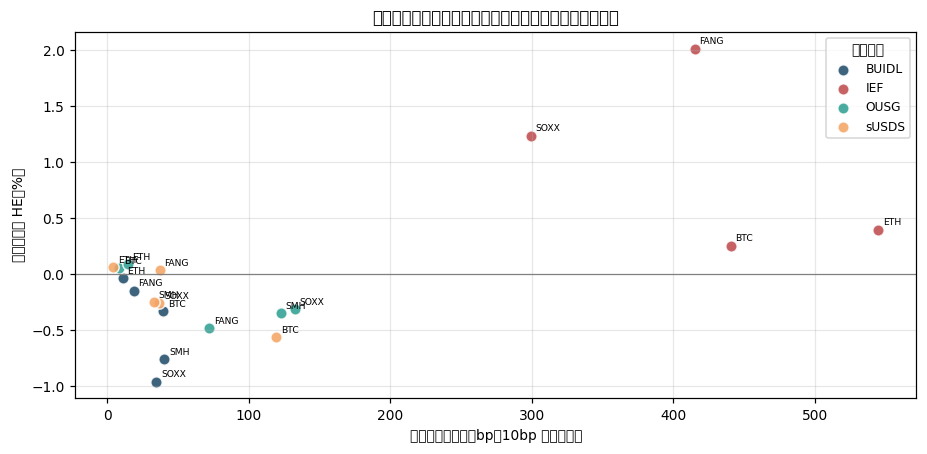

IEF 的點都在右側（成本高），代幣的點都擠在左側零軸附近（沒效果但也沒成本）。
兩者都不在『高變異數縮減 + 低成本』的理想區域。


In [52]:
# ---------------------------------------------------------------------------
# 變異數縮減 vs 成本：兩個維度一起看才看得出全貌
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = {"BUIDL": "#1b4965", "OUSG": "#2a9d8f", "sUSDS": "#f4a261", "IEF": "#bc4749"}
for inst, grp in h.groupby("hedge_instrument"):
    ax.scatter(grp["cost_bp_ann_10bp"], grp["HE"] * 100, s=55,
               color=colors.get(inst, "grey"), label=inst, alpha=0.85, edgecolor="white")
    for _, r in grp.iterrows():
        ax.annotate(r["hedged_equity"], (r["cost_bp_ann_10bp"], r["HE"] * 100),
                    fontsize=6, xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("年化再平衡成本（bp，10bp 單邊假設）")
ax.set_ylabel("變異數縮減 HE（%）")
ax.set_title("右上角才是有用的避險；本樣本沒有任何一格接近右上角")
ax.legend(title="避險工具", fontsize=8)
fig.tight_layout()
plt.show()

print("IEF 的點都在右側（成本高），代幣的點都擠在左側零軸附近（沒效果但也沒成本）。")
print("兩者都不在『高變異數縮減 + 低成本』的理想區域。")

### 這一節的方法論結論

把成本與效能分開報告，比折進單一數字更有資訊量。原因是兩者對投資人的意義不同：

- **變異數縮減**：風險管理的目標
- **成本拖累**：確定會發生的、對報酬的直接侵蝕

一個 HE = 0.02 但成本 415 bp 的避險，與一個 HE = 0.02 但成本 8 bp 的避險，
在單一「成本調整後 HE」指標下可能看起來差不多，但實際上是完全不同的兩件事。

> **給做實證的同學**：當你想把兩個不同單位、不同性質的量「調整」成一個數字時，
> 先問自己「調整後的數字還能被解讀嗎」。如果答案是「不太能」，
> 那就分開報告，讓讀者自己權衡。

---
---

# 第 9 篇　研究誠信

計量方法課通常只教「怎麼做對」。這一篇教的是另外一半：**做錯了長什麼樣、要怎麼抓出來**。

以下全部是這個專案**投稿前審計時真實發現**的問題，不是為了教學而編造的例子。
每一個都通過了作者本人的檢查、程式沒有報錯、輸出看起來完全合理。

---

## 單元 26｜四類錯誤的解剖

> **統計技術**：計算錯誤、覆蓋率缺口、陳述與資料不符、產出過時
>
> **對應程式**：`全部管線`
>
> **原始文獻**：
> - 本專案 CHANGELOG.md v1.1.0

## 錯誤一：三重複合的量綱錯誤（交易成本）

### 症狀

修正前的每一列，成本調整後的避險效能都**高於**未調整值：

```
BUIDL->FANG : HE = -0.0014569,  HE_cost_10bp = -0.0014544   ← 成本讓效能變好？
OUSG->FANG  : HE = -0.0047869,  HE_cost_10bp = -0.0047837   ← 同樣
sUSDS->FANG : HE = +0.0003922,  HE_cost_10bp = +0.0003956   ← 同樣
```

**加上成本之後結果變好，在經濟上不可能。** 這是最明確的警訊。

### 原始程式碼

```python
c = bps / 10000.0
r_hedged_cost = r_hedged - c * turnover * combined["r_hedge"].abs()
var_hedged_cost = r_hedged_cost.var()
HE_cost = 1 - var_hedged_cost / var_unhedged
```

### 三個獨立的錯誤疊在一起

| # | 錯誤 | 後果 |
|---|---|---|
| 1 | `bps / 10000` 把基點轉成**小數**，但報酬序列是 `*100` 的**百分點** | 成本小了 **100 倍** |
| 2 | 多乘一個 `r_hedge` 的絕對值 | 量綱錯誤；且 $\lvert r\rvert \approx 2$–3 使量級再偏 |
| 3 | 把成本折進**變異數比值** | 成本是水準效應，不是變異數效應（見單元 25） |

錯誤 1 與 2 讓成本小到在小數點後四位看不見；
錯誤 3 讓那一點點殘留的效果**方向相反** ——
從報酬中減去一個與報酬正相關的小量，可能反而**降低**變異數。

### 為什麼沒被發現

- 程式**沒有報錯**
- 數字**看起來合理**（都在 $10^{-3}$ 量級）
- 論文的結論（「代幣沒有勝過 IEF」）**碰巧不受影響**
- 表格只報告 10bp 一欄，5bp 與 20bp 沒印出來，看不出成本幾乎沒作用

### 抓出來的方法

**單調性檢查**：成本越高，效能必須越差。這是一個不需要知道正確答案就能做的檢查。

In [53]:
# ---------------------------------------------------------------------------
# 單調性檢查：一個不需要知道正確答案就能做的診斷
# ---------------------------------------------------------------------------
h = pd.read_csv(PROC / "hedge_summary.csv")

print("修正後：成本隨 bp 假設單調遞增（必要條件）")
cost_cols = ["cost_bp_ann_5bp", "cost_bp_ann_10bp", "cost_bp_ann_20bp"]
sub = h[["hedged_equity", "hedge_instrument"] + cost_cols].head(6)
display(sub.round(2))

ok = ((h[cost_cols[0]] <= h[cost_cols[1]]) & (h[cost_cols[1]] <= h[cost_cols[2]])).all()
print(f"所有列皆滿足 cost(5bp) <= cost(10bp) <= cost(20bp)：{ok}")
print()

print("淨報酬檢查：成本必須侵蝕平均報酬")
net_ok = (h["mean_ret_net_10bp"] <= h["mean_ret_hedged"] + 1e-12).all()
print(f"所有列皆滿足 mean_ret_net_10bp <= mean_ret_hedged：{net_ok}")
print()
print("修正前若跑這兩個檢查，第二項會立刻失敗 —— 但當時根本沒有 mean_ret_* 欄位可查。")
print("教訓：把中間量也寫進輸出，診斷才有材料可用。")

修正後：成本隨 bp 假設單調遞增（必要條件）


,hedged_equity,hedge_instrument,cost_bp_ann_5bp,cost_bp_ann_10bp,cost_bp_ann_20bp
0,FANG,BUIDL,9.1900,18.3800,36.7600
1,FANG,OUSG,35.9200,71.8300,143.6600
2,FANG,sUSDS,18.4100,36.8300,73.6500
3,FANG,SHV,11.2500,22.5100,45.0200
4,FANG,IEF,207.5200,415.0400,830.0700
5,SOXX,BUIDL,17.2500,34.5100,69.0200


所有列皆滿足 cost(5bp) <= cost(10bp) <= cost(20bp)：True

淨報酬檢查：成本必須侵蝕平均報酬
所有列皆滿足 mean_ret_net_10bp <= mean_ret_hedged：True

修正前若跑這兩個檢查，第二項會立刻失敗 —— 但當時根本沒有 mean_ret_* 欄位可查。
教訓：把中間量也寫進輸出，診斷才有材料可用。


## 錯誤二：靜默的覆蓋率缺口（Bai–Perron 少了 3 組配對）

### 症狀

表 11、表 12 只有 31 列，但 DCC 階段產生了 **34** 組配對。

### 原因

R 腳本用萬用字元掃描檔案：

```r
dcc_files <- list.files(proc_dir, pattern = "^dcc_.*\\.csv$", full.names = TRUE)
```

它被執行的時間點，早於 `dcc_IEF_ETH.csv`、`dcc_SHV_BTC.csv`、`dcc_SHV_ETH.csv`
這三個檔案被寫出的時間。腳本**只處理了當時存在的 31 個檔案，正常結束，沒有任何警告**。

### 後果

漏掉的 IEF–ETH 有 **3 個結構斷點、supF = 28.7、$p = 3\times10^{-6}$** ——
這是一個完全遺失的實質結果，而且屬於論文論述倚重的傳統工具對照組。

### 修正：覆蓋率守衛

```r
expected <- sub("^dcc_", "", tools::file_path_sans_ext(basename(dcc_files)))
missing_bp <- setdiff(expected, bp_df$pair)
if (length(missing_bp) || length(missing_bo)) {
  stop(sprintf("coverage guard: %d/%d pairs ... Missing: %s ...", ...))
}
```

**設計原則：寧可大聲失敗，也不要安靜地寫出不完整的表格。**

> 守衛上線的第一次執行就抓到了另一個潛在問題：`dcc_adcc_summary.csv` 符合萬用字元
> 但不是配對檔。它原本會被當成配對嘗試處理（因無 `rho_dcc` 欄而被跳過），
> 現在被明確排除。一個好的斷言常常會抓到你原本沒在找的東西。

## 錯誤三：陳述與自己的資料不符

這一類最難抓，因為**沒有任何程式會報錯** —— 錯的是論文正文裡的句子。
審計時共發現六處：

| # | 論文初稿的陳述 | 資料實際顯示 |
|---|---|---|
| 1 | 「兩個 ETF 基準都明顯拒絕常數相關」 | SHV–FANG $p = 1.00$、SHV–SOXX $p = 0.31$，**只有 IEF 拒絕** |
| 2 | 「OUSG 是唯一與治理代幣相關性達顯著的代幣」 | $p = 0.342$ 與 $0.595$，**兩個都不顯著** |
| 3 | 「兩個估計量在**每一個**變數的溢出符號上都一致」 | 12 個中 **10 個**一致，IEF 與 OUSG 相反 |
| 4 | 頻域「約 41 / 3 / 不到 1」 | 實為 **37.6 / 5.8 / 2.0** |
| 5 | 「IEF–GLD 在**每個**頻帶都最高」 | BUIDL–FANG 在最長頻帶 0.350 > 0.272 |
| 6 | 「三個代幣的不對稱**都**與股票相反」 | sUSDS 的 $\gamma = -0.60$，與股票**同向** |

### 共同的型態

六處全部都是**全稱量詞**：「每一個」、「都」、「唯一」、「全部」。

> **一條實用的寫作規則**：每當你寫下「所有 X 都具有性質 P」，
> 回頭把表格的每一列對過一遍。「大部分」與「全部」在審稿人眼中是完全不同的宣稱，
> 而後者只要一個反例就整句失效。

### 抓出來的方法：機器可驗證的宣稱

把論文中的每一個數字寫成可執行的斷言，對照來源檔案跑一遍。

In [54]:
# ---------------------------------------------------------------------------
# 把論文宣稱寫成可執行的斷言：稿件數字的自動驗證
# ---------------------------------------------------------------------------
import json

T = ROOT.parent / "iaj_submission" / "tables_data"
def J(name):
    if not (T / f"{name}.json").exists():
        return None
    return {r[0]: r for r in json.loads((T / f"{name}.json").read_text(encoding="utf-8"))["rows"]}

dcc_t, garch_t = J("table_dcc_full"), J("table_garch")
tv_t, st_t = J("table_tvpvar"), J("table_spillover_C")

checks = []
if dcc_t:
    rej = [k for k, v in dcc_t.items() if float(v[8]) < 0.05]
    checks.append(("拒絕常數相關的配對全屬 IEF", rej == ["IEF-FANG", "IEF-SOXX", "IEF-GLD"], rej))
    checks.append(("SHV 對科技股皆不拒絕",
                   float(dcc_t["SHV-FANG"][8]) > 0.05 and float(dcc_t["SHV-SOXX"][8]) > 0.05,
                   f"p = {dcc_t['SHV-FANG'][8]}, {dcc_t['SHV-SOXX'][8]}"))
    checks.append(("OUSG 對治理代幣皆不顯著",
                   float(dcc_t["OUSG-UNI"][8]) > 0.05 and float(dcc_t["OUSG-AAVE"][8]) > 0.05,
                   f"p = {dcc_t['OUSG-UNI'][8]}, {dcc_t['OUSG-AAVE'][8]}"))
if tv_t and st_t:
    agree = sum(1 for k in tv_t if (float(tv_t[k][3]) > 0) == (float(st_t[k][3]) > 0))
    checks.append(("兩估計量符號一致數 = 10（非 12）", agree == 10, f"{agree}/12"))
if garch_t:
    checks.append(("sUSDS 的 EGARCH gamma 為負（與股票同向）",
                   float(garch_t["sUSDS"][4]) < 0, garch_t["sUSDS"][4]))

fr = pd.read_csv(PROC / "r_frequency_tci_series.csv").groupby("band")["TCI"].mean().round(1)
checks.append(("頻帶分解為 37.6 / 5.8 / 2.0",
               (fr["1-5"], fr["5-20"], fr["20-Inf"]) == (37.6, 5.8, 2.0),
               f"{fr['1-5']} / {fr['5-20']} / {fr['20-Inf']}"))

for name, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {name:38} {detail}")
print()
print("這種斷言腳本應該在投稿前跑一次，並在每次重跑管線後再跑一次。")

  PASS  拒絕常數相關的配對全屬 IEF                        ['IEF-FANG', 'IEF-SOXX', 'IEF-GLD']
  PASS  SHV 對科技股皆不拒絕                           p = 1.0000, 0.3062
  PASS  OUSG 對治理代幣皆不顯著                         p = 0.3415, 0.5950
  PASS  兩估計量符號一致數 = 10（非 12）                   10/12
  PASS  sUSDS 的 EGARCH gamma 為負（與股票同向）         -0.6040
  PASS  頻帶分解為 37.6 / 5.8 / 2.0                 37.6 / 5.8 / 2.0

這種斷言腳本應該在投稿前跑一次，並在每次重跑管線後再跑一次。


## 錯誤四：產出檔案過時

### 症狀

`tables/table_descriptive.tex` 顯示 $n = 907$，但 `returns_panel.csv` 只支援 $n = 906$。

### 原因

`03_pretests.py` 的輸出是用**更早一版**的報酬面板產生的，之後面板重跑過，
但前置檢定沒有跟著重跑。GARCH 以後的所有階段都用了新面板，
只有前置檢定的表格停留在舊版。

### 為什麼危險

論文的表 1（描述統計）與表 3（GARCH 參數）會出現**互相矛盾的樣本數**，
而這正是審稿人最容易注意到的那種不一致。

### 結構性的成因與修正

真正的問題是**管線沒有相依關係管理**。修正包含三部分：

1. 修正 `parse_tables.py` 與 `build_excel.py` 中指向已不存在目錄的硬編碼路徑
2. 在 README 明確標示 Python 階段必須在 R 階段之前執行
3. 加入覆蓋率守衛（錯誤二）

> **更根本的解法**是把管線改成 Make / Snakemake / DVC 這類有相依圖的工具，
> 讓「輸入變了，輸出自動失效」由工具保證，而不是靠人記得。
> 對研究生的專案而言，這個投資通常在第二次重跑資料時就回本了。

## 總結：四類錯誤與對應的防禦

| 錯誤類型 | 為何難以察覺 | 防禦手段 |
|---|---|---|
| **量綱／符號錯誤** | 程式不報錯，數字量級看似合理 | **單調性與符號的必要條件檢查**；把中間量寫進輸出 |
| **覆蓋率缺口** | 迴圈正常結束，只是少跑了 | **斷言式守衛**：預期 $N$ 筆，少一筆就中止 |
| **陳述與資料不符** | 錯的是散文，不是程式 | **機器可驗證的宣稱**：每個數字寫成斷言 |
| **產出過時** | 每個檔案單獨看都正確 | **相依圖管理**（Make/DVC）；或至少交叉檢查樣本數 |

### 三條可以帶走的原則

**一、寧可大聲失敗**

安靜的降級（silent degradation）是實證研究最大的敵人。
一個中止執行的腳本會逼你面對問題；一個少跑三組配對卻正常結束的腳本不會。

**二、寫下不需要知道正確答案的檢查**

「成本越高，效能越差」、「三個頻帶加總等於總計」、「每列機率加總為 1」——
這類**必要條件**不需要你事先知道答案，卻能抓到大部分的計算錯誤。

**三、正文的每個數字都要有一條可追溯的路徑**

如果你無法在三十秒內指出論文某個數字來自哪個檔案的哪一欄，
那個數字就有風險。手動轉錄是錯誤的溫床 ——
本專案的表格全部由 `tex` 檔自動解析成 JSON 再寫進 Word，
正是為了消除這條路徑上的人為介入。

---

## 結語

這份教材涵蓋了從資料抓取到避險評估的完整流程，26 個單元對應 26 個統計技術。
但若只能記住一件事，我希望是最後這一篇的內容。

模型可以查書、公式可以推導、程式可以複製。
**判斷自己的結果是否可信，是唯一沒有捷徑的能力**，
而它只能透過反覆地、有系統地懷疑自己的輸出來培養。

那四個錯誤全部通過了作者本人的檢查。它們被抓出來，
不是因為有人更聰明，而是因為有人**列了一張清單，逐條對過**。

---

*本教材對應論文投稿於 Investment Analysts Journal。*
*完整管線、資料與可重現腳本見本 repository；錯誤修正紀錄見 `CHANGELOG.md`。*